# Plotting notebook
This notebook extracts and plots the geophysics compilation table and the data tables. The steps are as follows:
- 1. Import dependencies and install packages
- 2. Import data and geophysics compilation
- 3. plot figures

## 1. Import packages and setup folders and paths

### Install packages if not installed

In [1]:
#%pip install --upgrade DiadFit
#%pip install Thermobar
# %pip install seaborn
# %pip install matplotlib-label-lines
# %pip install cmcrameri

### Import packages

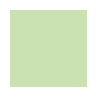

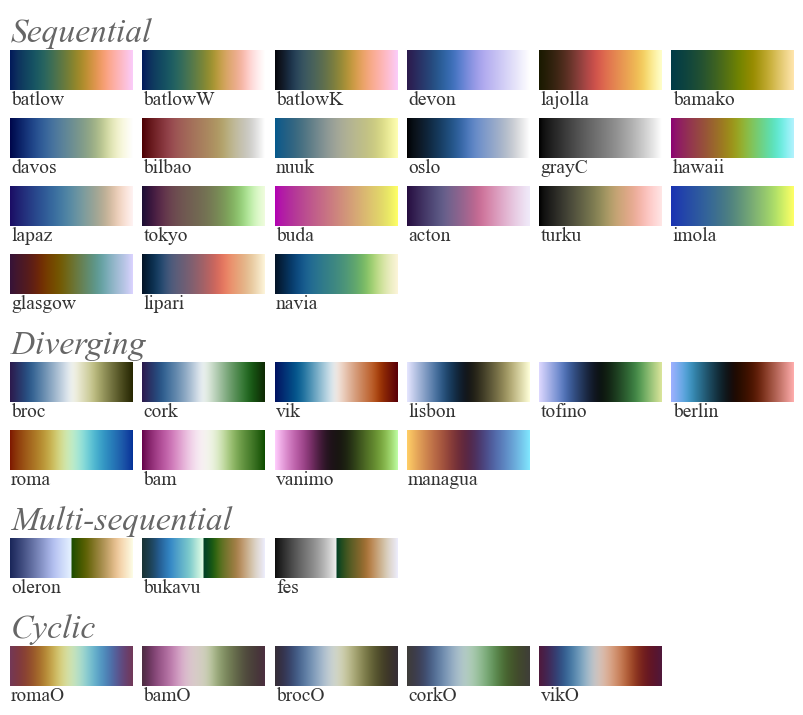

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import DiadFit as pf
import os
import math
import scipy
from matplotlib.gridspec import GridSpecFromSubplotSpec

from labellines import labelLines
from scipy import stats, signal
import cmcrameri as cmc

mpl.rcParams['pdf.fonttype'] = 42  # 42 is for TrueType fonts
mpl.rcParams['font.size'] = 7
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams['text.usetex'] = False
## Check for colors from cmcrameri

color=cmc.cm.romaO(0.5)
plt.figure(figsize=(2,1))
plt.imshow([[color]])
plt.axis('off')

cmc.show_cmaps()

### Setup folders and data paths

In [3]:
# This is to make sure the code runs regardless of operating system
if os.name=='posix':
    slash='/'
else:
    slash='\\'

# Set master folder
MasterFolder=os.path.dirname(os.getcwd())

#Folder to save figures

figpath=MasterFolder +slash+"Plotting_notebooks"+slash+'Notebook_Figs'
if not os.path.exists(figpath):
    os.mkdir(figpath)
# Create folder to save full datasets

compilation_folder=MasterFolder +slash+"Plotting_notebooks"+slash+'Notebook_Compiled_data'
if not os.path.exists(compilation_folder):
    os.mkdir(compilation_folder)



## 2. Import all datasets

### A. Import geophysics compilation

In [4]:
geophysics=pd.read_excel(MasterFolder +slash+'Data'+slash+'Other_Key_Data'+slash+'geophysics compilation_3Dec25.xlsx') # has the explanation row. Unecessary after this
geophysics = geophysics.drop(index=0)
geophysics.head(1)

,Reference Study,Publication year,Ref short,Activity,Data year,Data year end,"Main Geophysical method (Deformation, Seismic, Gravity, Electromagnetic)",Study type,Deformation source geometry,Source #,...,Time Period (month/year or year),Reservoir locations,"Depth measured, inferred, external (M or I,E)","Reservoir depth is a range (R ), mean (A), best-fit (B), Best-fit MCMC (BMC)",Depth (km),Depth uncertainty left (-km),Depth uncertainty right (+km),Cumulate upper depth (km),Cumulate lower depth (km),Comments
1,Mogi [1958],1958,M58,"Deflation of summit related to 1924 eruption, ...",1924,NaN,Deformation,"Tilt, triangulation; Point source",Point source,1,...,1912-1927,1-2 km S of Halema'uma'u,M,B,3.5,1,1,NaN,NaN,"Assumed spherical source, visual matching of t..."


### B. Import full newdata+K23, LERZ2018 and Lerner
- These are separate, hard to merge. We'll import the merged simplified frame right after


In [5]:
# New data first
newdata_K23=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Notebook_Compiled_data'+slash+'Step2_Merged_Data'+slash+'ThisStudy_and_2023_all_cols.xlsx')
newdata_K23 =newdata_K23.loc[:, ~newdata_K23.columns.str.contains('Unnamed')].copy()
display(newdata_K23.head())

# Now LERZ 2018
LERZ2018=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Notebook_Compiled_data'+slash+'Step2_Merged_Data'+slash+'LERZ2018_all_cols.xlsx')
LERZ2018 =LERZ2018.loc[:, ~LERZ2018.columns.str.contains('Unnamed')].copy()

# Now Lerner
Lerner=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Notebook_Compiled_data'+slash+'Step2_Merged_Data'+slash+'Lerner_all_cols.xlsx')
Lerner =Lerner.loc[:, ~Lerner.columns.str.contains('Unnamed')].copy()

# display(newdata_K23.head())
# display(LERZ2018.head())
# display(Lerner.head())

,Sample,Sample_crystal,FI_name,averaged?,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),"σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)",σ Density g/cm3 (from densimeter),...,Eruption_title,Sample Site: Longitude (WGS84),Sample Site: Latitude (WGS84),Fo_Ol_%,Eruption Date (CE),Fluid inclusion notes,FI_semiaxis_a_um,FI_semiaxis_b_um,FI_Area_um2,FI_Volume_um3
0,K23,K23_2,K23_2_FIA,No,NaN,0.004106,0.000000,0.000000,0.0,0.000000,...,IC\n(Sept 2023),-155.267850,19.407830,87.266314,Sept 2023,NaN,13.975748,12.539440,550.557998,9732.099229
1,KL0920,KL0920_c216,KL0920_c216_a2_FID,No,KL0920_c216_a2_FID,0.006448,0.020385,0.019995,NaN,0.003967,...,SSWRZ\n(Dec 1974),-155.295217,19.380050,80.865821,Dec 1974,Seems associated to growth clustering,7.363906,6.098223,141.078692,1266.146383
2,K24,K24_5,K24_5_FIA,No,K24_5_FIA,0.008291,0.005223,0.003406,NaN,0.003960,...,SSWRZ\n(June 2024),-155.298120,19.375625,86.965132,June 2024,NaN,9.190340,9.005186,260.000448,3153.896458
3,KL0921,KL0921_c288,KL0921_c288_a1_FIA,No,KL0921_c288_a1_FIA,0.009482,0.015142,0.014616,NaN,0.003955,...,Circ. flow\n(~1700),-155.291070,19.383150,84.120395,~1700,NaN,6.049058,5.102716,96.970355,720.927631
4,K21,K21_78b,K21_78b_FI#5,No,K21-78b-FI#5,0.009713,0.009637,0.008789,NaN,0.003954,...,Circ. flow\n(~1700),-155.291070,19.383150,87.416437,~1700,NaN,4.924013,4.337692,67.100805,414.311889


### C. Import the simplified fully merged dataset now

In [6]:
all_data_simplified=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Notebook_Compiled_data'+slash+'Step2_Merged_Data'+slash+'all_data_simplified.xlsx')
all_data_simplified =all_data_simplified.loc[:, ~all_data_simplified.columns.str.contains('Unnamed')].copy()
all_data_simplified = all_data_simplified.dropna(subset=["SingleCalc_D_km"]).copy()
all_data_simplified.head()

,Reference,Eruption_title,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)",Sample Site: Longitude (WGS84),Sample Site: Latitude (WGS84),Sample,Sample_crystal,FI_name,FI_type,FI_semiaxis_a_um,...,#of analyses (when averaged)_Gl,non_numeric_column_behavior_used (First/Last instance kept or skipped)_Gl,EBSDname+grainID_EBSDdata,GOS,Grain Size (pixels),Grain Size (um2),subBoundaryLength (um),equivalentRadius (um),GB Length/Sqrt Size,Total GB length
0,"Devitre et al. (2024, JPET)",IC\n(Sept 2023),Summit,-155.267850,19.407830,K23,K23_2,K23_2_FIA,P,13.975748,...,NaN,NaN,NaN,0.112099,14847.0,9.574355e+05,465.517028,552.051785,3.820465,465.517028
1,this study,SSWRZ\n(Dec 1974),SSWRZ,-155.295217,19.380050,KL0920,KL0920_c216,KL0920_c216_a2_FID,P,7.363906,...,NaN,NaN,NaN,0.364898,6337.0,1.181151e+06,1467.348586,613.165584,18.432806,1467.348586
2,this study,SSWRZ\n(June 2024),SSWRZ,-155.298120,19.375625,K24,K24_5,K24_5_FIA,P,9.190340,...,NaN,NaN,K24_5_10_54,0.096661,5935.0,5.955962e+05,62.107255,435.412617,0.806180,62.107255
3,this study,Circ. flow\n(~1700),Explosive Era,-155.291070,19.383150,KL0921,KL0921_c288,KL0921_c288_a1_FIA,PS,6.049058,...,5.0,skip,NaN,0.803403,13329.0,1.445071e+06,5790.460357,678.218566,50.155009,5790.460357
4,this study,Circ. flow\n(~1700),Explosive Era,-155.291070,19.383150,K21,K21_78b,K21_78b_FI#5,S,4.924013,...,5.0,skip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### D. Import magma supply estimates

In [7]:
magsup=pd.read_excel(MasterFolder +slash+'Data'+slash+'Other_Key_Data'+ slash+'magma_volume_estimates.xlsx') # has the explanation row. Unecessary after this
magsup = magsup.drop(index=0)
magsup.head()

magsup['Location name_year'] = magsup['Location name'] + '_' + magsup['Start year'].astype(str)
filter=(~magsup['Location name'].str.contains("Dec 1974|Late Keanakākoʻi era flow?"))&(~(magsup['Start year']==1410))

## 3. Plot FIGS
- Create filters to plot. 
- Fig 1 was plotted separately using QGIS and illustrator.
- Fig 2 (Geophysics)
- Fig 3 (distributions)

### A. Create filters for plotting
- We filter Rift zone, summit and explosive FI into three categories
- We filter out FI with SO2 mol% > 10 and secondary FI
- For Lerner data, we also filter the FI measured using the mass balance. 

In [8]:
all_data_simplified['Eruption_title'].unique()

array(['IC\n(Sept 2023)', 'SSWRZ\n(Dec 1974)', 'SSWRZ\n(June 2024)',
       'Circ. flow\n(~1700)', 'Kulanaokuaiki \n(400-950)',
       'ERZ (Nov 1973)', 'IC\n(Sep 1971)', 'IC\n(Dec 2020)',
       'ERZ (Dec 1969)', 'IC\n(Dec 2024)', 'Sand Hill\n(1840)',
       'IC\n(Jul 1974)', 'IC (Aug 1971)', 'VSWRZ\n(Sep 1971)',
       'EC\n (Jul 1974)', 'ERZ (May 1969)', 'Maunaiki VSWRZ\n(1919-1920)',
       'LERZ\n(May-Aug 2018)', 'Early Keanakākoʻi\n(1500-1650 CE)'],
      dtype=object)

In [9]:
## Filters for rift vs summit eruptions, doesn't include Keanakakoi from Lerner or Kulana because they are explosive eras with locations unknown.
rifts=all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ")
summit=all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit")
explosive=all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Explosive")
summit_or_explosive = summit | explosive

post2018 = all_data_simplified['Sample'].str.contains('K20|K23|KD24|K24', na=False)
pre2018 = ~(post2018)&~(explosive)&~(all_data_simplified['Eruption_title'].str.contains('Maunaiki|Sand', na=False))

prim=~(all_data_simplified['FI_type']=='S') # excudes S inclusions
SO2_cutoff=10 ## Filter out those with more than 10 mol% SO2
SO2_filt=~(all_data_simplified['SO2 mol%']>=SO2_cutoff)
lerner_weird=(all_data_simplified['Fluid inclusion notes'].str.contains("Two-phase",na=False)) ## These were calculated weird using mass balance approach, we filter them out

base_filters = prim & SO2_filt & ~(lerner_weird)

deformation = geophysics['Main Geophysical method (Deformation, Seismic, Gravity, Electromagnetic)'].str.contains('Deformation', na=False)
hm = geophysics['Region (SCR, HMMR, KR, ERZ, SWRZ) '].str.contains('HM', na=False)
sc = geophysics['Region (SCR, HMMR, KR, ERZ, SWRZ) '].str.contains('SC', na=False)

all_data_simplified[prim&SO2_filt]

,Reference,Eruption_title,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)",Sample Site: Longitude (WGS84),Sample Site: Latitude (WGS84),Sample,Sample_crystal,FI_name,FI_type,FI_semiaxis_a_um,...,#of analyses (when averaged)_Gl,non_numeric_column_behavior_used (First/Last instance kept or skipped)_Gl,EBSDname+grainID_EBSDdata,GOS,Grain Size (pixels),Grain Size (um2),subBoundaryLength (um),equivalentRadius (um),GB Length/Sqrt Size,Total GB length
2,this study,SSWRZ\n(June 2024),SSWRZ,-155.29812,19.375625,K24,K24_5,K24_5_FIA,P,9.190340,...,NaN,NaN,K24_5_10_54,0.096661,5935.0,595596.162507,62.107255,435.412617,0.806180,62.107255
5,this study,Kulanaokuaiki \n(400-950),Explosive Era,-155.28360,19.428500,UW5,UW5_OX25,UW5_OX25_FI#1,P,5.234172,...,33.0,skip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,this study,SSWRZ\n(June 2024),SSWRZ,-155.29812,19.375625,K24,K24_12,K24_12_FIA,PS,4.643376,...,NaN,NaN,K24_12_17_82,0.125426,1314.0,106308.648394,16.400018,183.954053,0.452425,16.400018
9,this study,Circ. flow\n(~1700),Explosive Era,-155.29107,19.383150,K21,K21_72,K21_72_FI#1,P,6.999352,...,5.0,skip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,this study,Circ. flow\n(~1700),Explosive Era,-155.29107,19.383150,K21,K21_53,K21_53_FI#4,P,10.064794,...,5.0,skip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,"Lerner et al. (2024, EPSL)",Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,-155.29229,19.389810,K99-5,K99-5_11,K99-5_11b,P,4.000000,...,15.0,skip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
733,"Lerner et al. (2024, EPSL)",Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,-155.29229,19.389810,K99-5,K99-5_11,K99-5_11c,P,6.000000,...,15.0,skip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
734,"Lerner et al. (2024, EPSL)",Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,-155.29229,19.389810,K99-5,K99-5_11,K99-5_11e,P,3.914868,...,15.0,skip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
735,"Lerner et al. (2024, EPSL)",Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,-155.29229,19.389810,K99-5,K99-5_11,K99-5_11f,P,2.800000,...,15.0,skip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### B. Sort the FI and geophysics distributions for CDF plots

#### a. Sort data

7.817109144542769

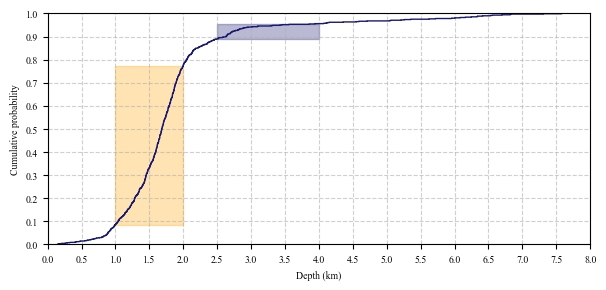

In [10]:
# Sort data for cumulative plots
def clean_sort_fi(df):
    return (
        df
        .dropna(subset=['SingleCalc_D_km'])
        .assign(SingleCalc_D_km=lambda d: d['SingleCalc_D_km'].astype(float))
        .sort_values('SingleCalc_D_km',ascending=True)
    )

def clean_sort_geophys(df):
    return (
        df
        .dropna(subset=['Depth (km)'])
        .assign(**{'Depth (km)': lambda d: d['Depth (km)'].astype(float)})
        .sort_values(by='Depth (km)', ascending=True)
    )

# First, sort the fluid inclusion datasets
summit_data_sorted = clean_sort_fi(all_data_simplified[summit_or_explosive & base_filters])
rifts_data_sorted = clean_sort_fi(all_data_simplified[rifts & base_filters])
FI_data_sorted = clean_sort_fi(all_data_simplified[base_filters])


post2018_summit_data_sorted = clean_sort_fi(all_data_simplified[summit & base_filters & post2018])
pre2018_summit_data_sorted = clean_sort_fi(all_data_simplified[summit & base_filters & pre2018])

post2018_rifts_data_sorted = clean_sort_fi(all_data_simplified[rifts & base_filters & post2018])
pre2018_rifts_data_sorted = clean_sort_fi(all_data_simplified[rifts & base_filters & pre2018])

post2018_allFI_data_sorted = clean_sort_fi(all_data_simplified[base_filters & post2018])
pre2018_allFI_data_sorted = clean_sort_fi(all_data_simplified[base_filters & pre2018])

explosive_summit_data_sorted = clean_sort_fi(all_data_simplified[base_filters & explosive])
effusive_summit_data_sorted = clean_sort_fi(all_data_simplified[base_filters & ~(explosive)&(summit)])

K20_sorted = clean_sort_fi(all_data_simplified[all_data_simplified['Sample'].str.contains('K20', na=False)& base_filters])
Keana_sorted = clean_sort_fi(all_data_simplified[all_data_simplified['Eruption_title'].str.contains('Keana', na=False)& base_filters])
K23_sorted = clean_sort_fi(all_data_simplified[all_data_simplified['Sample'].str.contains('K23', na=False)& base_filters])

LERZ2018_sorted=clean_sort_fi(all_data_simplified[all_data_simplified['Sample'].str.contains('LL',na=False)&base_filters])
# Now sort the geophysics datasets

all_geophysics_sorted = clean_sort_geophys(geophysics)

deformation_all_sorted = clean_sort_geophys(geophysics[deformation])
hm_geophysics_sorted = clean_sort_geophys(geophysics[hm])
sc_geophysics_sorted = clean_sort_geophys(geophysics[sc])
schm_geophysics_sorted = clean_sort_geophys(geophysics[sc | hm])

deformation_hm_sorted = clean_sort_geophys(geophysics[deformation & hm])
deformation_sc_sorted = clean_sort_geophys(geophysics[deformation & sc])

# Plot a cumulative distribution for the whole filtered dataset
fig,ax=plt.subplots(1,1, figsize=(7,3))

x = FI_data_sorted['SingleCalc_D_km'].values
n = x.size

ax.step(np.concatenate([FI_data_sorted ['SingleCalc_D_km'],FI_data_sorted['SingleCalc_D_km'][-1:]]),
        np.arange(FI_data_sorted ['SingleCalc_D_km'].size + 1) / FI_data_sorted ['SingleCalc_D_km'].size, 
        color='midnightblue', linewidth=1,label="ALL FI")

ax.set_xlim([0,max(FI_data_sorted ['SingleCalc_D_km'].max(), FI_data_sorted ['SingleCalc_D_km'].max())])
ax.set_ylim([0,1])
ax.set_xlabel("Depth (km)")
ax.set_ylabel("Cumulative probability")
ax.fill_betweenx([np.searchsorted(x,2.5)/n, np.searchsorted(x,4)/n], 2.5, 4, alpha=0.3, color='midnightblue')
ax.fill_betweenx([np.searchsorted(x,1)/n, np.searchsorted(x,2)/n], 1, 2, alpha=0.3, color='orange')

ax.set_yticks(np.arange(0, 1.000001, 0.1))
ax.set_xticks(np.arange(0, 8.5, 0.5))
ax.grid(axis='y', which='major', linestyle='--', alpha=0.6)
ax.grid(axis='x', which='major', linestyle='--', alpha=0.6)
x = FI_data_sorted['SingleCalc_D_km'].values
n = x.size
(100*np.searchsorted(x,5)/n)-(100*np.searchsorted(x,2.5)/n)


In [11]:
## For the supplement table
df=all_data_simplified[['Eruption_title','Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)','Sample Site: Longitude (WGS84)','Sample Site: Latitude (WGS84)','Sample','Reference']]
df=df.drop_duplicates('Sample')
df['Eruption_title'] = df['Eruption_title'].map(lambda x: x.replace("\n"," "))
df.to_clipboard(excel=True,index=False)

df


,Eruption_title,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)",Sample Site: Longitude (WGS84),Sample Site: Latitude (WGS84),Sample,Reference
0,IC (Sept 2023),Summit,-155.267850,19.407830,K23,"Devitre et al. (2024, JPET)"
1,SSWRZ (Dec 1974),SSWRZ,-155.295217,19.380050,KL0920,this study
2,SSWRZ (June 2024),SSWRZ,-155.298120,19.375625,K24,this study
3,Circ. flow (~1700),Explosive Era,-155.291070,19.383150,KL0921,this study
4,Circ. flow (~1700),Explosive Era,-155.291070,19.383150,K21,this study
5,Kulanaokuaiki (400-950),Explosive Era,-155.283600,19.428500,UW5,this study
12,SSWRZ (Dec 1974),SSWRZ,-155.293480,19.377480,919,this study
17,Kulanaokuaiki (400-950),Explosive Era,-155.272413,19.345420,UW7,this study
22,Kulanaokuaiki (400-950),Explosive Era,-155.283600,19.428500,UW3,this study
26,ERZ (Nov 1973),ERZ,-155.225167,19.371883,KL0910,this study


### b. Find modes in the dataset

In [12]:
datasets = {
    "K20":K20_sorted['SingleCalc_D_km'],
    "K23":K23_sorted['SingleCalc_D_km'],
    "pre2018_summitFI": pre2018_summit_data_sorted['SingleCalc_D_km'],
    "post2018_summitFI": post2018_summit_data_sorted['SingleCalc_D_km'],
    "pre2018_riftFI": pre2018_rifts_data_sorted['SingleCalc_D_km'],
    "post2018_riftFI": post2018_rifts_data_sorted['SingleCalc_D_km'],
    "LERZ2018":LERZ2018_sorted['SingleCalc_D_km'],
    "All rift FI": rifts_data_sorted['SingleCalc_D_km'],
    "All summit FI": summit_data_sorted['SingleCalc_D_km'],
    "All FI": FI_data_sorted['SingleCalc_D_km'],
    "All geophysics":all_geophysics_sorted['Depth (km)'],
    "HM geophysics":hm_geophysics_sorted['Depth (km)'],
    "SC geophysics":sc_geophysics_sorted['Depth (km)'],
    "Deformation HMM":deformation_hm_sorted['Depth (km)'],
    "Deformation SC":deformation_sc_sorted['Depth (km)'],
    "SC & HMM geophysics":schm_geophysics_sorted['Depth (km)'],
}

modes_dict = {}


for name, data in datasets.items():
    kde = stats.gaussian_kde(data)
    x_grid = np.linspace(min(data), max(data), 1000)
    density = kde(x_grid)
    peaks, _ = signal.find_peaks(density)
    modes = x_grid[peaks]
    modes_dict[name] = modes


modes_dict


{'K20': array([1.69733508]),
 'K23': array([1.62117292]),
 'pre2018_summitFI': array([1.53301784]),
 'post2018_summitFI': array([1.60686011]),
 'pre2018_riftFI': array([1.62798838, 6.37495676]),
 'post2018_riftFI': array([1.57836313, 4.58483336]),
 'LERZ2018': array([1.5021608 , 4.31582348]),
 'All rift FI': array([1.62543191, 6.29220298]),
 'All summit FI': array([1.71790482]),
 'All FI': array([1.67753302, 4.10395625, 5.19807962, 6.32197504]),
 'All geophysics': array([1.56406406, 2.61591592, 7.17157157]),
 'HM geophysics': array([1.16056056]),
 'SC geophysics': array([2.98378378]),
 'Deformation HMM': array([1.62432432]),
 'Deformation SC': array([3.1009009]),
 'SC & HMM geophysics': array([1.45225225, 2.64804805])}

In [13]:
def get_modes(data, bw=0.4, grid_size=1000, show_plot=True, name=None):
    data = np.asarray(data)
    
    x_grid = np.linspace(data.min(), data.max(), grid_size)
    kde = stats.gaussian_kde(data)

    if bw == "silverman":
        bw_method = kde.silverman_factor()
    elif bw == "scott":
        bw_method = kde.scotts_factor()
    elif isinstance(bw, (int, float)):
        bw_method = bw * kde.silverman_factor()
    else:
        bw_method = kde.factor

    density = stats.gaussian_kde(data, bw_method=bw_method)(x_grid)

    dy = np.gradient(density, x_grid)
    eps = 1e-5
    peaks = np.where((dy[:-1] > eps) & (dy[1:] <= eps))[0]

    if len(peaks) == 0:
        return None

    main_peak_idx = peaks[np.argmax(density[peaks])]

    dy_max, _ = signal.find_peaks(dy)
    dy_min, _ = signal.find_peaks(-dy)

    right_shoulders = dy_max[(dy_max > main_peak_idx) & (dy[dy_max] < 0)]
    left_shoulders = dy_min[(dy_min < main_peak_idx) & (dy[dy_min] > 0)]
    all_shoulders = np.r_[left_shoulders, right_shoulders]


    if show_plot:
        try:
            ax1 = get_modes._axes[get_modes._i]
        except:
            n = len(datasets)
            ncols = min(4, n)
            nrows = int(np.ceil(n / ncols))

            get_modes._fig, get_modes._axes = plt.subplots(
                nrows, ncols, figsize=(5*ncols, 4*nrows)
            )
            get_modes._axes = np.atleast_1d(get_modes._axes).flatten()
            get_modes._i = 0

            ax1 = get_modes._axes[get_modes._i]

        get_modes._i += 1

        ax1.plot(x_grid, density, 'k', label="KDE")
        ax1.plot(x_grid[peaks], density[peaks], 'ro', label="Peaks")
        ax1.plot(x_grid[all_shoulders], density[all_shoulders], 'go',
                 ms=8, label="Shoulders")
        ax1.set(xlabel='Depth (km)', ylabel="Density")

        ax2 = ax1.twinx()
        ax2.plot(x_grid, dy, color="orange", label="First derivative")
        ax2.plot(x_grid[dy_max], dy[dy_max], 'rx', label="dy maxima")
        ax2.plot(x_grid[dy_min], dy[dy_min], 'bx', label="dy minima")
        ax2.axhline(0, color="k", ls="--", lw=1)
        ax2.set_ylabel("dy")

        text = ( f"Peaks: {np.round(x_grid[peaks], 2)}\n" f"Shoulders: {np.round(x_grid[all_shoulders], 2)}" )
        ax1.text( 0.02, 0.98, text, transform=ax1.transAxes, va='top', ha='left', fontsize=8, bbox=dict(boxstyle="square", fc="white", alpha=1),zorder=-1 )

        ax1.set_title(name)

        l1, lab1 = ax1.get_legend_handles_labels()
        l2, lab2 = ax2.get_legend_handles_labels()
        ax1.legend(l1 + l2, lab1 + lab2)

    return {
        "x_grid": x_grid,
        "density": density,
        "peaks_x": x_grid[peaks],
        "main_peak_x": x_grid[main_peak_idx],
        "left_shoulders_x": x_grid[left_shoulders],
        "right_shoulders_x": x_grid[right_shoulders],
        "all_shoulders_x": x_grid[all_shoulders],
    }


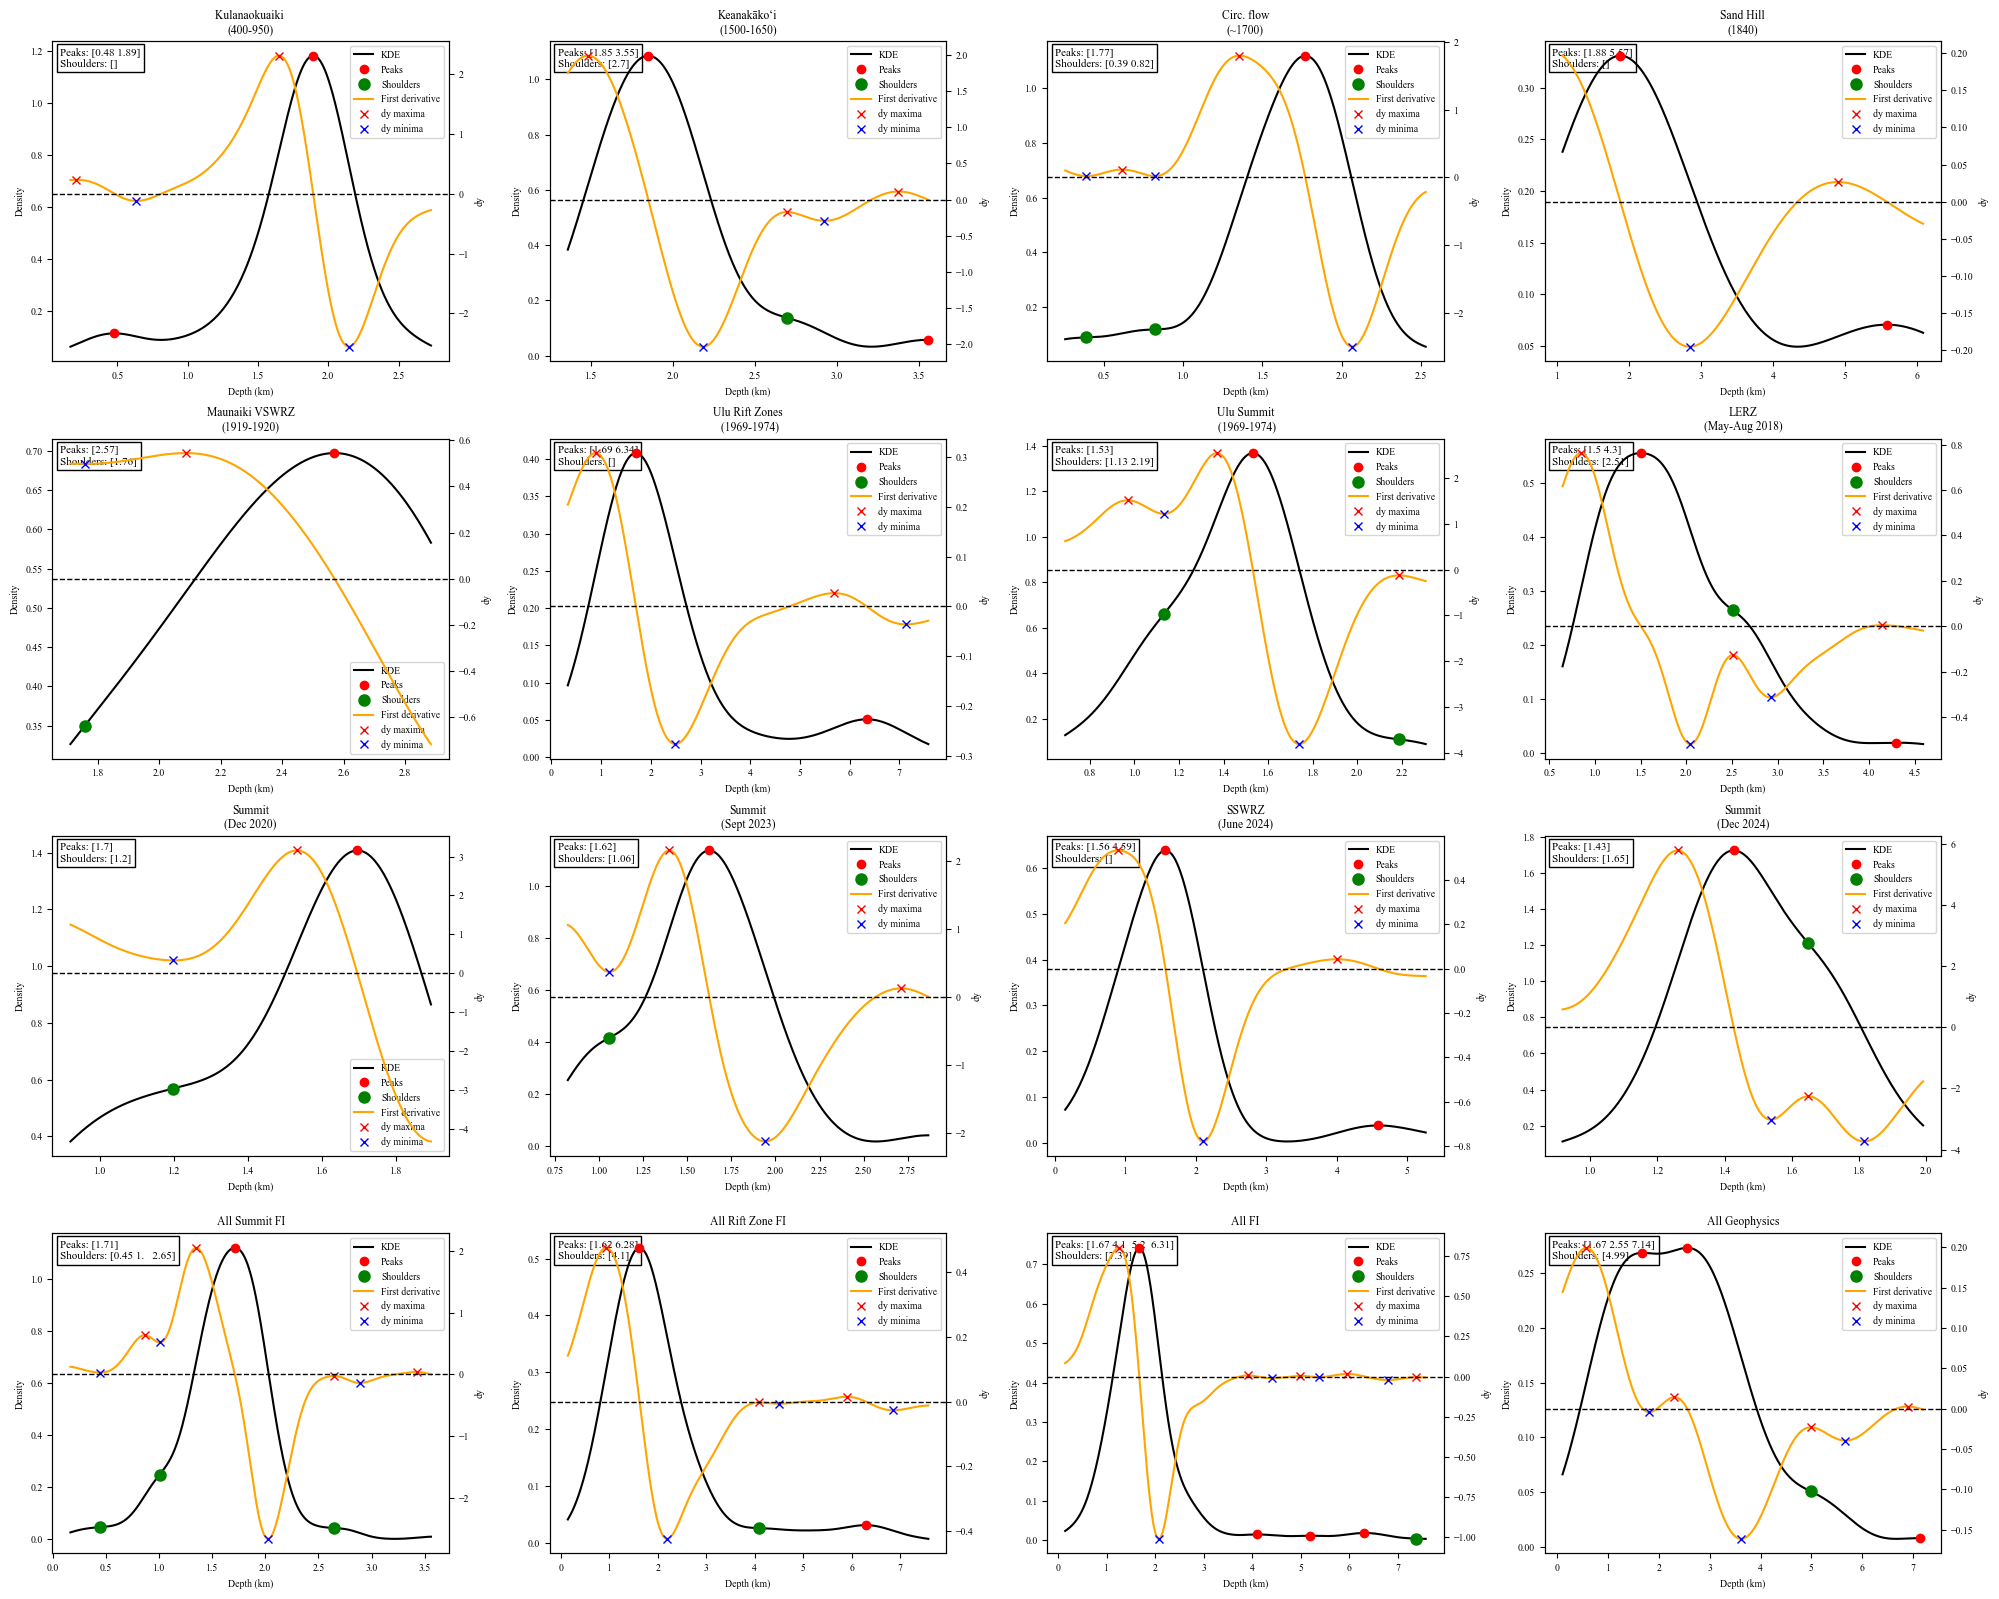

In [14]:
sets = [    clean_sort_fi(all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Kulana",na=False))&base_filters]),
            clean_sort_fi(all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Keana",na=False))&base_filters]),
            clean_sort_fi(all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Circ.",na=False))&base_filters]),
            clean_sort_fi(all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Sand",na=False))&base_filters]),
            clean_sort_fi(all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Maunaiki",na=False))&base_filters]),
            clean_sort_fi(all_data_simplified[(all_data_simplified['Sample'].str.contains('908|909|910|931|919|920',na=False))&base_filters]),
            clean_sort_fi(all_data_simplified[(all_data_simplified['Sample'].str.contains('914|916|917|924',na=False))&base_filters]),
            clean_sort_fi(all_data_simplified[all_data_simplified['Sample'].str.contains('LL',na=False)&base_filters]),
            clean_sort_fi(all_data_simplified[all_data_simplified['Sample'].str.contains('K20', na=False)& base_filters]),
            clean_sort_fi(all_data_simplified[all_data_simplified['Sample'].str.contains('K23', na=False)& base_filters]),
            clean_sort_fi(all_data_simplified[all_data_simplified['Sample'].str.contains('K24', na=False)& base_filters]),
            clean_sort_fi(all_data_simplified[all_data_simplified['Sample'].str.contains('KD24', na=False)& base_filters]),
            clean_sort_fi(all_data_simplified[summit_or_explosive & base_filters]),
            clean_sort_fi(all_data_simplified[rifts & base_filters]),
            clean_sort_fi(all_data_simplified[base_filters]),
            clean_sort_geophys(geophysics),
            ]

titles = ["Kulanaokuaiki \n(400-950)", 
          "Keanakākoʻi\n(1500-1650)",
          "Circ. flow\n(~1700)",
          "Sand Hill\n(1840)", 
          "Maunaiki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", 
          "Summit\n(Dec 2020)", 
          "Summit\n(Sept 2023)", 
          "SSWRZ\n(June 2024)", 
          "Summit\n(Dec 2024)",
          "All Summit FI",
          "All Rift Zone FI",
          "All FI",
          "All Geophysics"
          ]

datasets = {title: s['SingleCalc_D_km'] if 'SingleCalc_D_km' in s else s['Depth (km)']
    for s, title in zip(sets, titles)}

modes_dict = {}

for name, series in datasets.items():
    res = get_modes(series.values, show_plot=True, name=name,bw='silverman')
    modes_dict[name] = res

plt.tight_layout()
plt.show()


#### c. use filters to figure out numbers for paper

In [15]:
# To count samples as needed for numbers
len(all_data_simplified[(all_data_simplified['SingleCalc_D_km'].between(3,5))])
len(all_data_simplified[~(all_data_simplified['Eruption_title'].str.contains("Keana"))])
len(all_data_simplified[all_data_simplified['FI_type']=='S'])
len(all_data_simplified[all_data_simplified['SO2 mol%']>=10])
len(all_data_simplified[rifts]['Sample_crystal'].unique())
all_data_simplified[(all_data_simplified['SingleCalc_D_km']>2.5)]['Sample_crystal'].unique()

np.std(all_data_simplified[all_data_simplified['Eruption_title'].str.contains("LERZ")]['SingleCalc_D_km'])

len(all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("LERZ"))&(all_data_simplified['SingleCalc_D_km']>3)])
# len(all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("LERZ"))])
all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Keana"))&(all_data_simplified['SingleCalc_D_km']>6)]['Sample_crystal'].unique()
all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Keana"))]['Sample_crystal'].unique()
len(all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Keana"))])


# % of FI between two depths
y = np.arange(n) / n
mask=(x >= 0) & (x <= 3)

x_in_range = x[mask]
y_in_range = y[mask]

x_in_range, y_in_range

100*(y_in_range[-1]-y_in_range[0])

## Other counting things
string="Explosive"
print(np.nanmax(all_data_simplified[all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains(string)]['Fo_Ol_%']))
print(np.nanmin(all_data_simplified[all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains(string)]['Fo_Ol_%']))
## FI count per location
N_FI_a=len((all_data_simplified[all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Explosive",na=False)]))
print(all_data_simplified[all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Explosive",na=False)]["Sample_crystal"].nunique())
print(100*N_FI_a/len(all_data_simplified))

data=all_data_simplified.copy()
#Secondary FI count
location="RZ"#"Summit|Explosive"
100*len(data[(data['FI_type']=="S")&(data['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains(location))])/len(data[data['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains(location)])
100*len(data[(data['SO2 mol%']>=10)&(data['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains(location))])/len(data[data['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains(location)])
print(len(all_data_simplified[(all_data_simplified['SingleCalc_D_km']>6)]))
# print(len(all_data_simplified[(all_data_simplified['SingleCalc_D_km']>6)&~(all_data_simplified['decrepit'].str.contains('yes|maybe'))]))
data=all_data_simplified.copy()
reeq=data['decrepit'].str.contains('y|m', na=False)#data['Comment'].str.contains('reeq|re=eq|re-eq|req|decrep', na=False)
lerner_weird = data['Fluid inclusion notes'].str.contains("Two-phase", na=False)
lerner=data['Eruption_title'].str.contains("Keana",na=False)
print(len(data[(data['SingleCalc_D_km']>6)&~(lerner)]))
print(len(data[(data['SingleCalc_D_km']>6)&~(lerner)&(reeq)]))

len(data[(data['FI_type']=="S")&~(data['SingleCalc_D_km']>2)])
100*len(data[(data['FI_type']=="S")&~(data['SingleCalc_D_km']>1)])/len(data[(data['FI_type']=="S")])



89.89681699748314
75.59084085156842
95
25.37313432835821
21
14
13


68.0

### C. Plot Fig 3 FI data + magma supply

#### a. Create helper functions
- Half violin function (to plot half violins)
- KS stats

In [16]:
def half_violin(ax,data,side="right",*,clip_to_xlim=True,**violin_kwargs):
    """
    Draw a half violin on ax without modifying existing violins.

    Parameters
    ----------
    ax : matplotlib axis
    data : array-like
        Data for the violin (y values for orient='v')
    side : {'right', 'left'}
        Which side to keep
    clip_to_xlim : bool
        Whether to clip exactly to current xlim
    violin_kwargs : passed to sns.violinplot
    """

    n_before = len(ax.collections)
    sns.violinplot(y=data,ax=ax,orient="v",inner=None,cut=0, **violin_kwargs)
    new_collections = ax.collections[n_before:]

    y0, y1 = ax.get_ylim()
    x0, x1 = ax.get_xlim()

    if side == "right":
        rect = mpl.patches.Rectangle(
            (0, y0),
            (x1 if clip_to_xlim else max(1, x1)),
            y1 - y0,
            transform=ax.transData
        )
    else:
        rect = mpl.patches.Rectangle(
            (x0 if clip_to_xlim else -max(1, abs(x0)), y0),
            abs(x0),
            y1 - y0,
            transform=ax.transData
        )

    for coll in new_collections:
        coll.set_clip_path(rect)
        # paths = coll.get_paths()    
        # for path in paths:        
        #     verts = path.vertices        
        #     verts[:, 0] *= 2.0


##############################################################################################
##############################################################################################

def calc_critKS_D(x1, x2, alpha=0.05):
    calpha_dict = {
        0.10: 1.22,
        0.05: 1.36,
        0.025: 1.48,
        0.01: 1.63,
        0.005: 1.73,
        0.001: 1.95
    }
    
    if alpha not in calpha_dict:
        raise ValueError(f"Alpha {alpha} not supported. Choose from {list(calpha_dict.keys())}")
    
    calpha = calpha_dict[alpha]
    
    criticalksD = calpha * np.sqrt((len(x1) + len(x2)) / (len(x1) * len(x2)))
    return criticalksD

def calculate_bootstrap_ks(data1, data2, data1_err, data2_err, 
                           alpha=0.05, iterations=2000,
                           plot=True,plot_method='plot',
                           xlabel="Depth (km)",
                           data1_label="Data1",
                           data2_label="Data2"):
    # plot_method can be 'plot' to get a simple CDF, smoothed. If anything else, it will use step function to plot.
    # if plot is true, a figure is produced, if anything else it will not plot. 

    def calculate_ks_stat(data1, data2):
        return stats.ks_2samp(data1, data2)

    bootstrap_ks_stats = []
    bootstrap_p_values = []
    resampled_distributions = []

    for _ in range(iterations):
        data1_resample = np.random.normal(data1, data1_err)
        data2_resample = np.random.normal(data2, data2_err)
        
        ks_result = calculate_ks_stat(data1_resample, data2_resample)
        bootstrap_ks_stats.append(ks_result.statistic)
        bootstrap_p_values.append(ks_result.pvalue)
        
        resampled_distributions.append({
            'data1_resample': np.sort(data1_resample),
            'data2_resample': np.sort(data2_resample),
        })

    bootstrap_ks_stats = np.array(bootstrap_ks_stats)
    bootstrap_p_values = np.array(bootstrap_p_values)

    data1_resample_sorted = np.sort(data1_resample)
    data2_resample_sorted = np.sort(data2_resample)

    original_ks_stat, original_p_value = calculate_ks_stat(data1, data2)
    critD=calc_critKS_D(data1_resample_sorted,data2_resample_sorted,alpha=alpha)

    res = {
        'original_ks_stat': original_ks_stat,
        'original_p_value': original_p_value,
        'critical D-val':critD,
        'bootstrap_ks_stats': bootstrap_ks_stats,
        'bootstrap_p_values': bootstrap_p_values,
        'bootstrap_ks_mean': np.mean(bootstrap_ks_stats),
        'bootstrap_ks_std': np.std(bootstrap_ks_stats),
        'bootstrap_p_mean': np.mean(bootstrap_p_values),
        'bootstrap_p_std': np.std(bootstrap_p_values),
        'data1_resample_sorted': data1,
        'data2_resample_sorted': data2,
        'resampled_distributions': resampled_distributions,
    }

    if plot!=False:
        fig,ax=plt.subplots(1,1, figsize=(7, 5))
        # This plots all the bootstraped CDF 
        for i, distribution in enumerate(res['resampled_distributions']):
            if plot_method!='plot':
                ax.step(np.concatenate([distribution['data1_resample'],distribution['data1_resample'][-1:]]),
                        np.arange(distribution['data1_resample'].size + 1) / distribution['data1_resample'].size, 
                        color='royalblue',alpha=0.2)
                ax.step(np.concatenate([distribution['data2_resample'],distribution['data2_resample'][-1:]]),
                        np.arange(distribution['data2_resample'].size + 1) / distribution['data2_resample'].size,
                          color='wheat',alpha=0.2)
            else:
                ax.plot(np.sort(distribution['data1_resample']), 
                        np.arange(1, len(distribution['data1_resample']) + 1) / len(distribution['data1_resample']), 
                        color='royalblue', alpha=0.2)
                ax.plot(np.sort(distribution['data2_resample']), 
                        np.arange(1, len(distribution['data2_resample']) + 1) / len(distribution['data2_resample']), 
                        color='wheat', alpha=0.2)
        

        # This plots the original data CDF
        if plot_method!='plot':
            ax.step(np.concatenate([res['data1_resample_sorted'],res['data1_resample_sorted'][-1:]]),
                    np.arange(res['data1_resample_sorted'].size + 1) / res['data1_resample_sorted'].size, 
                    color='midnightblue', linewidth=2,label=data1_label)
            ax.step(np.concatenate([res['data2_resample_sorted'],res['data2_resample_sorted'][-1:]]),
                    np.arange(res['data2_resample_sorted'].size + 1) / res['data2_resample_sorted'].size, 
                    color='darkorange', linewidth=2,label=data2_label)
        else:
            ax.plot(res['data1_resample_sorted'], 
                    np.arange(1, len(res['data1_resample_sorted']) + 1) / len(res['data1_resample_sorted']), 
                    color='midnightblue',linewidth=2, label=data1_label)
            ax.plot(res['data2_resample_sorted'], 
                    np.arange(1, len(res['data2_resample_sorted']) + 1) / len(res['data2_resample_sorted']), 
                    color='darkorange',linewidth=2, label=data2_label)

        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))

        stats_text = f"Sample KS Statistic: {res['original_ks_stat']:.3f}\n" \
                    f"Sample P-val: {res['original_p_value']:.2e}\n" \
                    f"Critical KS D - conf {alpha}: {res['critical D-val']:.3f}\n" \
                    f"MC KS Mean: {res['bootstrap_ks_mean']:.3f} ± {res['bootstrap_ks_std']:.3f}\n" \
                    f"MC P-val Mean: {res['bootstrap_p_mean']:.3f} ± {res['bootstrap_p_std']:.3f}"

        dummy_handle = mpl.lines.Line2D([], [], color='none')
        handles = list(unique.values()) + [dummy_handle]
        labels = list(unique.keys()) + [stats_text]

        ax.legend(handles, labels, loc='lower right', handletextpad=0.25,handlelength=0.5,fancybox=False,edgecolor='k')

        ax.set_xlim([0,max(data1.max(), data2.max())])
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Cumulative probability")



    if 'fig' in locals():
        final_result=fig,res
    else:
        final_result=res
    
    return final_result



def annotate_ks_panel(ax, res, title, color1='midnightblue', color2='darkorange'):
    text = ( f"{title}\n\n"
        f"D$_{{crit}}$(0.05) = {res['critical D-val']:.3f}\n"
        f"D$_{{sample}}$ = {res['original_ks_stat']:.3f}\n"
        f"p$_{{sample}}$ = {res['original_p_value']:.2e}\n\n"
        f"D$_{{MC}}$ = {res['bootstrap_ks_mean']:.3f} ± {res['bootstrap_ks_std']:.3f}\n"
        f"p$_{{MC}}$ = {res['bootstrap_p_mean']:.2e} ± {res['bootstrap_p_std']:.2e}"
    )

    ax.text(0.55, 0.10, text, transform=ax.transAxes, fontsize=7, va='bottom', ha='left' )

    # Color-coded inline labels (like reference)
    ax.text(0.06, 0.92, "Post‑2018", transform=ax.transAxes,
            fontsize=8, rotation=90, color=color2, va='top')
    

def plot_cdf_ks(    ax, res, data1_label, data2_label,    plot_method='step',    lgd_fontsize=7,    alpha=0.05,    
                show_legend=False,    legend_x=0.03,    legend_y_labels=(0.96, 0.90),    legend_y_stats=0.80, linespacing=1,   plot_bootstrap=True):
    if plot_bootstrap==True:
        for distribution in res['resampled_distributions']:

            if plot_method != 'plot':
                ax.step(np.concatenate([ distribution['data1_resample'], distribution['data1_resample'][-1:] ]), 
                        np.arange(distribution['data1_resample'].size + 1) / distribution['data1_resample'].size,
                        color='royalblue', alpha=0.2 )
                ax.step(np.concatenate([ distribution['data2_resample'], distribution['data2_resample'][-1:] ]),
                    np.arange(distribution['data2_resample'].size + 1) / distribution['data2_resample'].size,
                    color='wheat',alpha=0.2)
            else:
                ax.plot( np.sort(distribution['data1_resample']), 
                        np.arange(1, len(distribution['data1_resample']) + 1) / len(distribution['data1_resample']), 
                        color='royalblue', alpha=0.2 )
                ax.plot( np.sort(distribution['data2_resample']), 
                        np.arange(1, len(distribution['data2_resample']) + 1) / len(distribution['data2_resample']), 
                        color='wheat', alpha=0.2 )

    if plot_method != 'plot':
        h1 = ax.step( np.concatenate([ res['data1_resample_sorted'], res['data1_resample_sorted'][-1:] ]), 
                     np.arange(res['data1_resample_sorted'].size + 1) / res['data1_resample_sorted'].size, 
                     color='midnightblue', linewidth=1.5, label=data1_label )[0]

        h2 = ax.step( np.concatenate([ res['data2_resample_sorted'], res['data2_resample_sorted'][-1:] ]), 
                     np.arange(res['data2_resample_sorted'].size + 1) / res['data2_resample_sorted'].size, 
                     color='darkorange', linewidth=1.5, label=data2_label )[0]
    else:
        h1 = ax.plot( res['data1_resample_sorted'], 
                     np.arange(1, len(res['data1_resample_sorted']) + 1) / len(res['data1_resample_sorted']), 
                     color='midnightblue', linewidth=1.5, label=data1_label )[0]

        h2 = ax.plot( res['data2_resample_sorted'], 
                     np.arange(1, len(res['data2_resample_sorted']) + 1) / len(res['data2_resample_sorted']), 
                     color='darkorange', linewidth=1.5, label=data2_label )[0]

    if show_legend==True:
        y1, y2 = legend_y_labels
        ax.text( legend_x, y1, data1_label, transform=ax.transAxes, ha='left', va='top', fontsize=lgd_fontsize, color='midnightblue')
        ax.text( legend_x, y2, data2_label, transform=ax.transAxes, ha='left', va='top', fontsize=lgd_fontsize, color='darkorange')

        stats_lines = [
            f"D$_{{crit}}$(0.05) = {res['critical D-val']:.3f}",
            f"D$_{{sample}}$ = {res['original_ks_stat']:.3f}",
            f"p$_{{sample}}$ = {res['original_p_value']:.2e}",
        ]

        if plot_bootstrap:
            stats_lines += [
                f"D$_{{MC}}$ = {res['bootstrap_ks_mean']:.3f} ± {res['bootstrap_ks_std']:.3f}",
                f"p$_{{MC}}$ = {res['bootstrap_p_mean']:.2e} ± {res['bootstrap_p_std']:.2e}",
            ]

        ax.text( legend_x, legend_y_stats, "\n".join(stats_lines), transform=ax.transAxes, ha='left', va='top', fontsize=lgd_fontsize, linespacing=linespacing)

    ax.set_xlim( 0, max( res['data1_resample_sorted'].max(), res['data2_resample_sorted'].max() ) )
    ax.set_ylim(0, 1.0)

#### b. Plot Fig 3

In [17]:
def get_violin_color(data):
    titles = data['Eruption_title'].astype(str)
    if titles.str.contains("Kulana", regex=False).any():
        return "red"
    if titles.str.contains("Circ", regex=False).any():
        return "red"
    if titles.str.contains("Keana", regex=False).any():
        return "pink"
    loc = data['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].astype(str)
    if loc.str.contains("Summit", regex=False).any():
        return "orange"
    if loc.str.contains("RZ", regex=False).any():
        return "#1f3dbf"
    if 'Explosive' in data.columns:
        if data['Explosive'].astype(str).str.contains("Explosive", regex=False).any():
            return "orange"
    return "grey"

In [18]:
iterations=1000
alpha=0.05

summit_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_summit_data_sorted['SingleCalc_D_km'], data2=post2018_summit_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_summit_data_sorted['std_dev_MC_D_km'], data2_err=post2018_summit_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 Summit FI',data2_label='Post-2018 Summit FI')
rifts_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_rifts_data_sorted['SingleCalc_D_km'], data2=post2018_rifts_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_rifts_data_sorted['std_dev_MC_D_km'], data2_err=post2018_rifts_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 Rift FI',data2_label='Post-2018 Rift FI')
summitrift_all_ks= calculate_bootstrap_ks(data1=rifts_data_sorted['SingleCalc_D_km'], data2=summit_data_sorted['SingleCalc_D_km'],
                                     data1_err=rifts_data_sorted['std_dev_MC_D_km'], data2_err=summit_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Rifts FI',data2_label='Summit FI')
all_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_allFI_data_sorted['SingleCalc_D_km'], data2=post2018_allFI_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_allFI_data_sorted['std_dev_MC_D_km'], data2_err=post2018_allFI_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 FI',data2_label='Post-2018 FI')
explosive_vs_effusive_summit=calculate_bootstrap_ks(data1=explosive_summit_data_sorted['SingleCalc_D_km'], data2=effusive_summit_data_sorted['SingleCalc_D_km'],
                                     data1_err=explosive_summit_data_sorted['std_dev_MC_D_km'], data2_err=effusive_summit_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Ex-period summit',data2_label='ef-period summit')

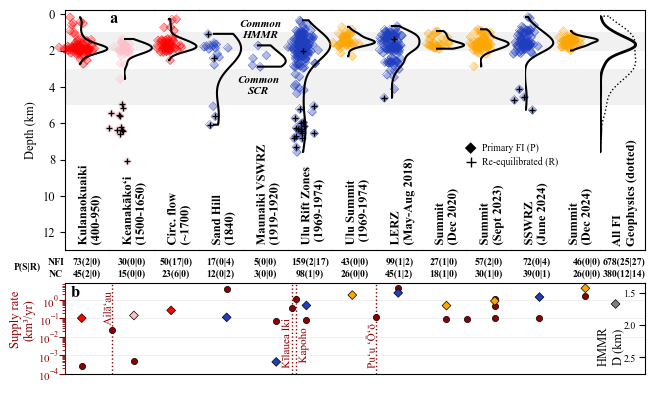

In [19]:
datasets = [all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Kulana"))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Keana"))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Circ."))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Sand"))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Maunaiki"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains('908|909|910|931|919|920'))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains('914|916|917|924'))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("LERZ"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K20"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K23"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K24"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("KD24"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ"))],
            all_data_simplified,
            geophysics
            ]

titles = ["Kulanaokuaiki \n(400-950)", 
          "Keanakākoʻi\n(1500-1650)",
          "Circ. flow\n(~1700)",
          "Sand Hill\n(1840)", 
          "Maunaiki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", 
          "Summit\n(Dec 2020)", 
          "Summit\n(Sept 2023)", 
          "SSWRZ\n(June 2024)", 
          "Summit\n(Dec 2024)",
          "All Summit FI",
          "All Rift Zone FI",
          "All FI",
          "All Geophysics"
          ]

# datasets_filtered_violins = [df[base_filters] for df in datasets]
num_axes = len(datasets)-3
 ## These were calculated weird using mass balance approach, we filter them out

# ylims=(90,75)
# xlims=(0,0.5)
ylims=(13,-0.25)
xlims=(-0.2,0.43)#(-0.5,0.5)
plot_var='SingleCalc_D_km'

# fig, axes = plt.subplots(1, num_axes, figsize=(10, 4), sharey=True)

inch=25.4

fig = plt.figure(figsize=(190/inch, 120/inch))
gs = mpl.gridspec.GridSpec(
    nrows=2,
    ncols=num_axes,
    height_ratios=[4, 1.5],
    hspace=0.2,
    wspace=0
)

# top row (your existing violin axes)
axes = [fig.add_subplot(gs[0, i]) for i in range(num_axes)]

for ax in axes:    
    for y0, y1 in [ (1, 2), (3, 5)]:        
        ax.axhspan(y0, y1,facecolor='lightgrey',alpha=0.3,zorder=-300)

###

for i, (ax, data_all, title) in enumerate(zip(axes, datasets, titles)):

    # # Color logic
    # if i == num_axes - 2:
    #     violin_color = "grey"
    # elif i== num_axes-1:
    #     violin_color = "k"
    # else:
    violin_color = get_violin_color(data_all)

    if i != num_axes-1:
        prim_tmp = data_all['FI_type'] != 'S'
        so2_tmp = ~(data_all['SO2 mol%'] >= SO2_cutoff)
        reeq_tmp = data_all['decrepit'].str.contains('y', na=False)
        lerner_weird_tmp = data_all['Fluid inclusion notes'].str.contains("Two-phase", na=False)
        base_filters_tmp=(so2_tmp)&(prim_tmp)&~(lerner_weird_tmp)

        data_plot = data_all.loc[base_filters_tmp]
        nfi_total = len(data_plot)
        nc_total  = data_plot['Sample_crystal'].nunique()
        sec_excl = ~prim_tmp
        so2_excl = ~so2_tmp
        nfi_sec = sec_excl.sum()
        nfi_so2 = so2_excl.sum()
        nfi_req = reeq_tmp.sum()

        nc_sec = (    data_all.loc[sec_excl, 'Sample_crystal']    .nunique())
        nc_so2 = (    data_all.loc[so2_excl, 'Sample_crystal']    .nunique())
        nc_req = (    data_all.loc[reeq_tmp, 'Sample_crystal']    .nunique())
        nfi_str = f'{nfi_total}({nfi_sec}|{nfi_req})'
        nc_str  = f'{nc_total}({nc_sec}|{nc_req})'

        y = data_all[plot_var].dropna()
        idx = y.index
        x = + np.random.normal(0, 0.075, len(y))

        prim = prim_tmp.loc[idx]
        so2 = so2_tmp.loc[idx]
        reeq = reeq_tmp.loc[idx]
        base = base_filters_tmp.loc[idx]
        lerner_w = lerner_weird_tmp.loc[idx]
        x_sec = x.copy()
        x_sec[~prim] -= 0.24   # shift secondaries further left
        s_main=20
        s_sec=10
        ax.scatter( x[so2&prim], y[so2&prim], marker='D', s=s_main, facecolor=violin_color, alpha=0.35, linewidths=0, zorder=2,clip_on=False )
        ax.scatter( x[so2&prim], y[so2&prim], marker='D', s=s_main,edgecolors=violin_color, facecolor='none', alpha=1, linewidths=0.25, zorder=2,clip_on=False )
        # ax.scatter( x[~so2&prim], y[~so2&prim], s=s_main, marker='D', facecolor='none', edgecolor='black', linewidth=0.8, zorder=4,clip_on=False  )
        ax.scatter( x[reeq|lerner_w], y[reeq|lerner_w], marker='+', s=s_main, color='black', linewidths=1, zorder=4,clip_on=False  )
        # ax.scatter( x_sec[~prim], y[~prim], marker='o', s=s_sec, facecolor=violin_color, edgecolor='none', linewidth=0.8, zorder=3,clip_on=False )
        # ax.scatter( x_sec[~prim&~so2], y[~prim&~so2], marker='o', s=s_sec, facecolor='none', edgecolor='black', linewidth=0.8, zorder=4,clip_on=False )

        
        half_violin( ax, data_plot[plot_var], side="right", fill=False, alpha=1, color='k', linewidth=1.5, bw_method="silverman",zorder=100 )
        # half_violin( ax, data_plot[plot_var], side="right", fill=True, alpha=0.2, color=violin_color, linewidth=0, bw_method="silverman",zorder=99 )

        ax.xaxis.set_tick_params(bottom=False)
        if i != 0:    
            ax.yaxis.label.set_visible(False)
        if i == 0:
            ax.set_ylabel('Depth (km)',fontsize=9)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis='y', labelsize=9)
            ax.annotate(  r'NFI', xy=(-0.2, -0.05),xycoords='axes fraction', fontsize=7,
                    ha='center', va='center', fontweight='bold')
            ax.annotate( r'NC',  xy=(-0.2, -0.1),xycoords='axes fraction', fontsize=7,
                    ha='center', va='center', fontweight='bold')
        elif i == num_axes - 1:
            ax.yaxis.set_tick_params(left=False, labelleft=False,labelsize=9)
            ax.spines['left'].set_visible(False)
            ax.spines['right'].set_visible(True)
        else:
            ax.yaxis.set_tick_params(left=False, labelleft=False,labelsize=9)
            ax.spines['left'].set_visible(False)
            ax.spines['right'].set_visible(False)

        ax.set_ylim(ylims)
        ax.set_xlim(xlims)
        ###put titles on plot (names of eruptions)
        ax.annotate(title, xy=(0.3, 0.02), xycoords='axes fraction',
                    ha='left', va='bottom', fontsize=9,
                    color='k', fontweight='bold', rotation=90, path_effects=[mpl.patheffects.Stroke(linewidth=2.5, foreground='white'),mpl.patheffects.Normal()])
        nfi_x = 0.5
        if i == num_axes - 3:
            nfi_x = 0.58
        elif i == num_axes - 2:
            nfi_x = 0.70
        ax.annotate( nfi_str, xy=(nfi_x, -0.05), xycoords='axes fraction',
                    fontsize=7, ha='center', va='center', fontweight='bold' )
        ax.annotate( nc_str,  xy=(nfi_x, -0.10), xycoords='axes fraction', 
                    fontsize=7, ha='center', va='center', fontweight='bold' )


    elif i == num_axes-1:

        half_violin( ax, geophysics['Depth (km)'].dropna().astype(float), side="right", fill=False, color="k", linewidth=1, linestyle=':', bw_method="silverman" )
        for j, idx in enumerate([ -2]):
            d = datasets[idx]
            prim_tmp = d['FI_type'] != 'S'
            so2_tmp = ~(d['SO2 mol%'] >= SO2_cutoff)
            lerner_tmp = d['Fluid inclusion notes'].str.contains("Two-phase", na=False)
            reeq_tmp = d['decrepit'].str.contains('y', na=False)
            filt = (so2_tmp) & (prim_tmp) & ~(lerner_tmp)
            d_filt = d.loc[filt]
            d_plot = d_filt[plot_var].dropna()
            nfi_total = len(d_plot)
            nc_total  = d_filt['Sample_crystal'].nunique()
            sec_excl = ~prim_tmp
            so2_excl = ~so2_tmp
            nfi_sec = sec_excl.sum()
            nfi_req = reeq_tmp.sum()
            nc_sec = d.loc[sec_excl, 'Sample_crystal'].nunique()
            nc_req = d.loc[reeq_tmp, 'Sample_crystal'].nunique()

            nfi_str = f'{nfi_total}({nfi_sec}|{nfi_req})'
            nc_str  = f'{nc_total}({nc_sec}|{nc_req})'

            nfi_x = 0.55
            ax.annotate( nfi_str, xy=(nfi_x, -0.05), xycoords='axes fraction', fontsize=7, ha='center', va='center', fontweight='bold' )
            ax.annotate( nc_str, xy=(nfi_x, -0.10), xycoords='axes fraction', fontsize=7, ha='center', va='center', fontweight='bold' )
            half_violin( ax, d_plot, side=("right" if idx in [-1,-2] else "left"), fill=False, color=('k' if idx == -2 else get_violin_color(d)), linewidth=2, bw_method="silverman")

        ax.annotate("All FI \nGeophysics (dotted)", xy=(0.3, 0.02), xycoords='axes fraction',
            ha='left', va='bottom', fontsize=9,
            color='k', fontweight='bold', rotation=90)

        ax.set_ylim(ylims)
        ax.set_xlim(0)   # ← critical
        ax.set_xticks([])
        ax.set_yticks([])
        ax.yaxis.label.set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)
        ax.spines['top'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
    if i==num_axes-1:
        ax.spines['left'].set_visible(False)

for ax in axes:
    ax.patch.set_visible(False)




## bottom panel
ax_b = fig.add_subplot(gs[1, :])
ax_b.set_axisbelow(True)

magsup_filt = magsup[
    (~magsup['Location name'].str.contains("Dec 1974|Late Keanakākoʻi era flow?", na=False)) &
    (magsup['Start year'] != 1410)
].copy()

magma_supply = magsup_filt['Magma supply km3/yr'].astype(float).values
supply_x = np.full(len(magsup_filt), np.nan)
extra_push=0.5
supply_rules = [
    (lambda s: "Uēkahuna Ash" in s,   -0.4 + extra_push/2),
    (lambda s: "‘Ailā‘au" in s,        0.23 + extra_push/1.95),
    (lambda s: "Keanakākoʻi" in s,     0.43 + extra_push),
    (lambda s: "Sand Hills" in s,      2.1 + extra_push*1.5),
    (lambda s: "Maunaiki" in s,        3.0 + extra_push*1.75),
    (lambda s: "Kilauea Iki" in s,     3.2 + extra_push*2),
    (lambda s: "Kapoho" in s,          3.28 + extra_push*2),
    (lambda s: "Maunaulu" in s,        3.5 + extra_push*2),
    (lambda s: "Puʻu ʻŌʻō" in s,       4.7 + extra_push*2.5),
    (lambda s: "Leilani" in s,         4.9 + extra_push*3),
    (lambda s: s.endswith("_2020"),    5.9 + extra_push*3),
    (lambda s: s.endswith("_2021"),    6.2 + extra_push*3.25),
    (lambda s: s.endswith("_2023"),    6.4 + extra_push*4),
    (lambda s: s.endswith("4_2024"),   7.2 + extra_push*4.25),
    (lambda s: s.endswith("u_2024"),   7.9 + extra_push*4.75),
]
supply_x = np.full(len(magsup_filt), np.nan)

for i, tag in enumerate(magsup_filt["Location name_year"]):
    supply_x[i] = next((val for cond, val in supply_rules if cond(tag)), np.nan)

valid = np.isfinite(supply_x) & np.isfinite(magma_supply)

supply_x = supply_x[valid]
magma_supply = magma_supply[valid]

supply_color = "darkred"

# ax_b.plot( supply_x, magma_supply, color=supply_color, lw=2, zorder=10)
ax_b.scatter( supply_x, magma_supply, color=supply_color,edgecolors='k',linewidths=0.5, s=20, zorder=11 )

events = {
    "Ailā‘au": lambda s: "‘Ailā‘au" in s,
    "Kīlauea Iki": lambda s: "Kilauea Iki" in s,
    "Kapoho": lambda s: "Kapoho" in s,
    "Puʻu ʻŌʻō": lambda s: "Puʻu ʻŌʻō" in s,
}

event_x = {}

for tag in magsup_filt["Location name_year"]:
    for name, cond in events.items():
        if cond(tag):
            x_val = next((val for rcond, val in supply_rules if rcond(tag)), np.nan)
            if np.isfinite(x_val):
                event_x[name] = x_val
                
label_pos = {
    "Ailā‘au": (-0.1, 0.9),    
    "Kīlauea Iki": (-0.12, 0.6), 
    "Kapoho": (0.15, 0.5),     
    "Puʻu ʻŌʻō": (-0.1, 0.55),
}

for name, x in event_x.items():
    ax_b.axvline(x, color=supply_color, linestyle=':', linewidth=1, zorder=5)
    dx, y = label_pos.get(name, (0.05, 0.9))
    ax_b.text( x + dx, y, name, transform=ax_b.get_xaxis_transform(), 
              rotation=90, ha='center', va='top', fontsize=8, color=supply_color, 
              path_effects=[ mpl.patheffects.Stroke(linewidth=3, foreground="white"), mpl.patheffects.Normal() ] )

################# TO plot the HMMR modes ########################
rules = [
    ("Kulanaokuaiki",  -0.4 + extra_push/2),
    ("Keanakākoʻi",     0.43 + extra_push),
    ("Circ.",           1.2 + extra_push),
    ("Sand Hill",       2.1 + extra_push*1.5),
    ("Maunaiki",       3.0 + extra_push*1.75),
    ("Ulu Rift",        3.5 + extra_push*2),
    ("Ulu Summit",      4.2 + extra_push*2.5),
    ("LERZ",            4.9 + extra_push*3),
    ("Dec 2020",        5.9 + extra_push*3),
    ("Sept 2023",       6.4 + extra_push*4),
    ("June 2024",       7.2 + extra_push*4.25),
    ("Dec 2024",        7.9 + extra_push*4.75),
    ("All FI",          8.4 + extra_push*5),
    ("All Geophysics",  8.75 + extra_push*5),
]

fill_colors = {
    "Kulanaokuaiki":  "red",
    "Keanakākoʻi":    "pink",
    "Circ.":          "red",
    "Sand Hill":       "#1f3dbf",
    "Maunaiki":        "#1f3dbf",
    "Ulu Rift":        "#1f3dbf",
    "Ulu Summit":     "orange",
    "LERZ":            "#1f3dbf",
    "Dec 2020":       "orange",
    "Sept 2023":      "orange",
    "June 2024":       "#1f3dbf",
    "Dec 2024":       "orange",
    "All FI":         "grey",
    "All Geophysics": "none",
}


x_map = { name: next((val for key, val in rules if key in name), np.nan) 
         for name in modes_dict}

x_main, y_main,c_main = [], [],[]
x_peaks, y_peaks = [], []
x_should, y_should = [], []

for name, res in modes_dict.items():
    if res is None or name not in x_map:
        continue

    x0 = x_map[name]
    peaks = res["peaks_x"]
    main = peaks[np.argmin(abs(peaks - 2))] if len(peaks) else np.nan
    x_main += [x0]; y_main += [main]
    x_peaks += [x0]*len(peaks[peaks != main]); y_peaks += list(peaks[peaks != main])
    x_should += [x0]*len(res["all_shoulders_x"]); y_should += list(res["all_shoulders_x"])

    c_main.append(
        next((c for k, c in fill_colors.items() if k in name), "none")
    )

ax_twinb=ax_b.twinx()
m = np.array(c_main) != "none"
ax_twinb.scatter(np.array(x_main)[m], np.array(y_main)[m], c=np.array(c_main)[m],
                 edgecolors='k', linewidths=0.5, s=20, marker='D', zorder=13)
################################################################

panel_labels = ['b']

for label, ax in zip(panel_labels, [ax_b]):
    ax.text(0.01, 0.97, label, transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='left' )

#### This is to plot the symbols for FI types
lx = 0.7
y1=2.5
y2=y1-0.15
y3=y2-0.15
y4=y3-0.15
ys = [y1, y2, y3, y4]

ax_b.scatter( [lx], [ys[0]], marker='D', s=35, facecolor='k', edgecolor='none', transform=ax_b.transAxes, clip_on=False, zorder=10 )
ax_b.scatter( [lx], [ys[1]], marker='+', s=45, color='black', linewidths=1, transform=ax_b.transAxes, clip_on=False, zorder=10 )
# ax_b.scatter( [lx], [ys[2]], marker='o', s=25, facecolor='k', edgecolor='black', linewidth=0.8, transform=ax_b.transAxes, clip_on=False, zorder=10 )
# ax_b.scatter( [lx], [ys[3]], marker='D', s=35, facecolor='none', edgecolor='black', linewidth=0.8, transform=ax_b.transAxes, clip_on=False, zorder=10 )


labels = [
    "Primary FI (P)",
    "Re-equilibrated (R)",
    # "Secondary FI (S)",
    # r'SO${_2}$≥ 10%',
]

for y, lab in zip(ys, labels):
    ax_b.text( lx + 0.02, y, lab, transform=ax_b.transAxes, ha='left', va='center', fontsize=7 )

axes[0].text(1, 0.99, 'a', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left' )

for ax in fig.axes:
    ax.set_facecolor('none')
    ax.patch.set_alpha(0)
    ax.set_clip_on(False)
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1)

ax_b.set_xlim(-0.5, 11.5)  # last eruption panel = Dec 2024

ax_b.set_yscale('log')
ax_b.set_ylim( magma_supply.min() * 0.4, magma_supply.max() * 1.8 )
ax_b.yaxis.set_label_position("left")
ax_b.yaxis.tick_left()
ax_b.spines['right'].set_visible(True)
ax_b.spines['left'].set_visible(True)

ax_b.spines['top'].set_visible(True)
ax_b.spines['bottom'].set_visible(True)
ax_b.set_xticks([])
ax_b.patch.set_alpha(0)
ax_b.set_ylabel( "Supply rate\n(km³/yr)", fontsize=9, rotation=90, labelpad=0)

ax_b.yaxis.set_label_coords(-0.05, 0.6)
ax_b.tick_params(axis='y', labelsize=8, direction="out")
ax_b.minorticks_on()
ax_b.tick_params( axis='y', which='major', colors=supply_color, labelcolor=supply_color, length=4 , direction="out", pad=0)
ax_b.tick_params( axis='y', which='minor', colors=supply_color, labelcolor=supply_color, length=2 , direction="out", pad=0)
ax_b.yaxis.label.set_color(supply_color)
ax_b.grid( True, which='major', color="#dadada", linestyle='-', linewidth=0.5, alpha=0.6, zorder=-200 )
ax_b.spines['left'].set_color(supply_color)

ax_twinb.set_yscale('linear')
ax_twinb.set_ylim(2.75,1.35)
ax_twinb.set_frame_on(False)
ax_twinb.tick_params( axis='y', which='both', colors='k', labelcolor='k', length=4 , direction="in", pad=-15)
ax_twinb.set_ylabel( "HMMR\nD (km)", fontsize=9, rotation=90)
ax_twinb.yaxis.set_label_coords(0.92,0.3)


ax_b.text(3.5, 3.3, "Common\nSCR", transform=ax_b.get_xaxis_transform(), 
            rotation=0, ha='center', va='top', fontsize=8, color='k', 
            fontweight='bold', fontstyle='italic')
ax_b.text(3.55, 3.92, "Common\nHMMR", transform=ax_b.get_xaxis_transform(), 
            rotation=0, ha='center', va='top', fontsize=8, color='k', 
            fontweight='bold', fontstyle='italic')

fig.text(s=r'P(S|R)', x=0.075,y=0.3345,fontsize=7, ha='center', va='center', fontweight='bold')
####
plt.subplots_adjust(wspace=0)
fig.savefig(figpath + slash + 'Fig3_violins.pdf', format='pdf', dpi=300, transparent=True, bbox_inches='tight', pad_inches=0.01)
fig.savefig( figpath + slash + 'Fig3_violins.png', dpi=300, transparent=False,bbox_inches='tight', pad_inches=0.02)


### D. Plot Fig 4. Olivine and glass MgO chemistry

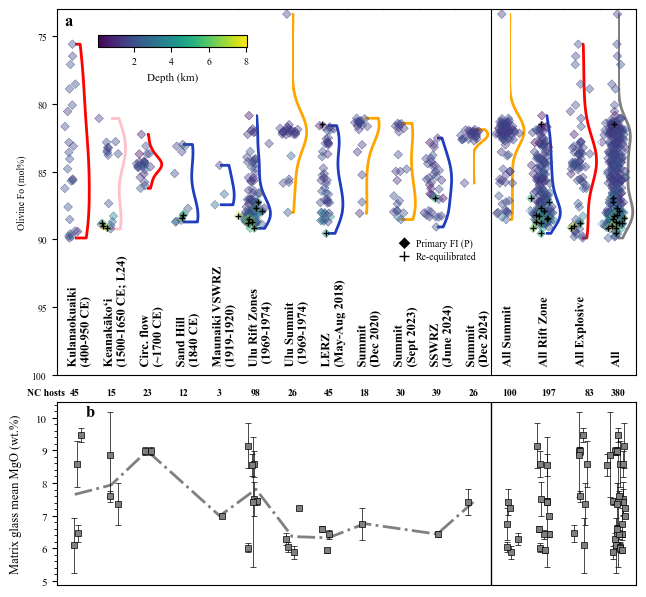

In [25]:
deepest_FI_only=True ## whether all FI are plotted or only max in each crystal (avoid duplicate olivine compos)

datasets = [all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Kulana"))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Keana"))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Circ."))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Sand"))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Maunaiki"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains('908|909|910|931|919|920'))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains('914|916|917|924'))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("LERZ"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K20"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K23"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K24"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("KD24"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Explosive"))],
            all_data_simplified,
            ]

titles = ["Kulanaokuaiki \n(400-950 CE)", 
          "Keanakākoʻi\n(1500-1650 CE; L24)",
          "Circ. flow\n(~1700 CE)",
          "Sand Hill\n(1840 CE)", 
          "Maunaiki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", 
          "Summit\n(Dec 2020)", 
          "Summit\n(Sept 2023)", 
          "SSWRZ\n(June 2024)", 
          "Summit\n(Dec 2024)",
          "All Summit",
          "All Rift Zone",
          "All Explosive",
          "All",
          ]

num_axes = len(datasets)

ylims=(100,73)
xlims=(-0.5,0.5)

plot_var='Fo_Ol_%'
mgo_color = "grey"
#################Scatter style ################################
scatter_style = "color"   # "fixed", "color", "size"
dcol = "SingleCalc_D_km"
cmap_varcolor = "viridis"
use_local_norm = False
set_color_max='none' #'none' if you want to use the global maximum in data


if scatter_style in ("color", "size") and dcol in all_data_simplified.columns:
    global_vmin = all_data_simplified.loc[
        all_data_simplified[dcol].notna(), dcol
    ].min()
    if set_color_max!='none':
        global_vmax=set_color_max
    else:
        global_vmax = all_data_simplified.loc[
            all_data_simplified[dcol].notna(), dcol
        ].max()

###############################################################

inch=25.4

fig = plt.figure(figsize=(190/inch, 190/inch))
gs = mpl.gridspec.GridSpec(
    nrows=2,
    ncols=num_axes,
    height_ratios=[3,1.5],
    hspace=0.1,
    wspace=0
)

axes = [fig.add_subplot(gs[0, i]) for i in range(num_axes)]

# bottom row panels (b–e placeholders)
n_bottom = 1
cols_per_panel = num_axes // n_bottom
bottom_axes = []
for i in range(n_bottom):
    start = i * cols_per_panel
    end = (i + 1) * cols_per_panel
    ax = fig.add_subplot(gs[1, start:end])
    bottom_axes.append(ax)
ax_b = bottom_axes[0]

###### bottom panel

ax_b.set_xlim(-0.5, num_axes - 0.5)

ax_b.yaxis.set_label_position("left")
ax_b.yaxis.tick_left()
ax_b.tick_params(axis='y', colors="k", labelsize=8)
ax_b.minorticks_on()
ax_b.set_xticks([])

ax_b.set_ylabel(
    "Matrix glass mean MgO (wt.%)",
    fontsize=9,
    rotation=90,
    labelpad=10,
    color="k"
)

np.random.seed(42)

exclude_mgo_idxs = {num_axes - 4,num_axes - 3, num_axes - 2, num_axes - 1}

mgo_x = []
mgo_y = []
mgo_yerr = []
mgo_line_x = []
mgo_line_y = []

for i, data_all in enumerate(datasets):

    # if i in exclude_mgo_idxs:
    #     continue

    needed = {'Sample', 'MgO_Gl', 'MgO_STD_Gl'}
    if not needed.issubset(data_all.columns):
        continue

    mask = data_all['MgO_Gl'].notna() & data_all['MgO_STD_Gl'].notna()

    df_mgo = (
        data_all.loc[mask, ['Sample', 'MgO_Gl', 'MgO_STD_Gl']]
        .drop_duplicates(subset='Sample')
    )

    if df_mgo.empty:
        continue

    vals = df_mgo['MgO_Gl'].astype(float).values
    errs = df_mgo['MgO_STD_Gl'].astype(float).values

    # horizontal jitter per panel
    x_mgo = i + np.random.normal(0, 0.12, len(vals))

    mgo_x.extend(x_mgo)
    mgo_y.extend(vals)
    mgo_yerr.extend(errs)

    if i not in exclude_mgo_idxs:
        mgo_line_x.append(i)
        mgo_line_y.append(vals.mean())

mgo_x = np.asarray(mgo_x)
mgo_y = np.asarray(mgo_y)
mgo_yerr = np.asarray(mgo_yerr)
mgo_line_x = np.asarray(mgo_line_x)
mgo_line_y = np.asarray(mgo_line_y)


ax_b.set_xlim(-0.5, num_axes - 0.5)

ax_b.errorbar( mgo_x, mgo_y, yerr=mgo_yerr, fmt='s', markersize=4, markerfacecolor=mgo_color, markeredgecolor='k', markeredgewidth=0.5, ecolor='k', elinewidth=0.5, capsize=2, zorder=5 )

order = np.argsort(mgo_line_x)
ax_b.plot( mgo_line_x[order], mgo_line_y[order], color=mgo_color, linestyle="-.", lw=2.0, zorder=4 )
# ax_b.axvline(x=0.8, color='red', linestyle='--', linewidth=2)

#######

for i, (ax, data_all_raw, title) in enumerate(zip(axes, datasets, titles)):

    # Color logic
    if i == num_axes - 1:
        violin_color = "grey"
    else:
        violin_color = get_violin_color(data_all_raw)

    if deepest_FI_only==True:
        # Collapse to one representative FI per crystal (deepest)
        if dcol in data_all_raw.columns:
            df = data_all_raw.copy()
            valid_mask = ( (df['FI_type'] != 'S') & (df['SO2 mol%'] < SO2_cutoff) )
            idx = df.groupby("Sample_crystal").apply(
                lambda g: (
                    g.loc[valid_mask.loc[g.index], dcol].idxmax()
                    if valid_mask.loc[g.index].any()
                    else g[dcol].idxmax() if g[dcol].notna().any()
                    else g.index[0]
                ),
                include_groups=False
            )
            data_all = df.loc[idx].sort_index()

    else:
        data_all = data_all_raw.copy()

    prim_tmp = data_all['FI_type'] != 'S'
    so2_tmp = ~(data_all['SO2 mol%'] >= SO2_cutoff)
    reeq_tmp = data_all['decrepit'].str.contains('y', na=False)
    lerner_weird_tmp = data_all['Fluid inclusion notes'].str.contains("Two-phase", na=False)
    base_filters_tmp=(so2_tmp)&(prim_tmp)&~(lerner_weird_tmp)

    data_plot = data_all.loc[base_filters_tmp]
    nc_total  = data_plot['Sample_crystal'].nunique()
    nc_str  = f'{nc_total}'

    half_violin( ax, data_plot[plot_var], side="right", fill=False, alpha=1, color=violin_color, linewidth=2, bw_method="silverman" )

    y = data_all[plot_var].dropna()
    idx = y.index
    x = -0.1+ np.random.normal(0, 0.12, len(y)) #-0.12

    prim = prim_tmp.loc[idx]
    so2 = so2_tmp.loc[idx]
    reeq = reeq_tmp.loc[idx]
    base = base_filters_tmp.loc[idx]
    lerner_w = lerner_weird_tmp.loc[idx]
    x_sec = x.copy()
    x_sec[~prim] -= 0.24   # shift secondaries further left
    x_so2= x.copy()
    x_so2[~so2] -= 0.24   # shift secondaries further left
    s_main = 20
    s_sec  = 10

    ######### Style scatter by color or size ############
    if scatter_style == "color" and dcol in data_all.columns:
        cvals = data_all.loc[idx, dcol]

        if use_local_norm:
            local_vmin = cvals.min()
            local_vmax = cvals.max()
            vmin_use = local_vmin
            vmax_use = local_vmax
        else:
            vmin_use = global_vmin
            vmax_use = global_vmax

        scat_kwargs_main = dict(c=cvals[prim&so2], cmap=cmap_varcolor,
                                vmin=vmin_use, vmax=vmax_use)
        scat_kwargs_sec  = dict(c=cvals[~prim], cmap=cmap_varcolor,
                                vmin=vmin_use, vmax=vmax_use)
        s_main_use = s_main
        s_sec_use  = s_sec
    

    ###########################################################
    ax.scatter( x[prim&so2], y[prim&so2], marker='D', s=s_main_use,
                alpha=0.4, linewidths=0, zorder=2,
                **scat_kwargs_main)

    if scatter_style == "color" and dcol in data_all.columns:
        norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)
        cmap = mpl.colormaps[cmap_varcolor]
        edgecols = cmap(norm(cvals[prim&so2]))
    else:
        edgecols = violin_color

    ax.scatter( x[prim&so2], y[prim&so2], marker='D', s=s_main_use,
                alpha=1, linewidths=0.25, zorder=2,edgecolors=edgecols,facecolors='none',clip_on=False)

    ax.scatter( x[reeq|lerner_w], y[reeq|lerner_w],
                marker='+', s=s_main, color='black',
                linewidths=1, zorder=4 ,clip_on=False)

    ax.xaxis.set_tick_params(bottom=False)
    if i != 0:    
        ax.yaxis.label.set_visible(False)
    if i == 0:
        ax.set_ylabel('Olivine Fo (mol%)')
        ax.spines['right'].set_visible(False)

        ax.annotate( r'NC hosts',  xy=(-0.3, -0.05),xycoords='axes fraction', fontsize=7,
                ha='center', va='center', fontweight='bold')
    elif i == num_axes - 1:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax.set_ylim(ylims)
    ax.set_xlim(xlims)
    ###put titles on plot (names of eruptions)
    ax.annotate(title, xy=(0.3, 0.02), xycoords='axes fraction',
                ha='left', va='bottom', fontsize=9,
                color='k', fontweight='bold', rotation=90, path_effects=[mpl.patheffects.Stroke(linewidth=2.5, foreground='white'),mpl.patheffects.Normal()])
    nfi_x = 0.5
    if i == num_axes - 3:
        nfi_x = 0.58
    elif i == num_axes - 2:
        nfi_x = 0.70

    ax.annotate( nc_str,  xy=(nfi_x, -0.05), xycoords='axes fraction', 
                fontsize=7, ha='center', va='center', fontweight='bold' )
    ax.set_clip_on(False)
    if i == num_axes-1:
        ax.set_ylim(ylims)
        ax.set_xlim(xlims)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.yaxis.label.set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)
        ax.spines['top'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        # ax.spines['right'].set_color(mgo_color)
        # ax.annotate(r'P(S|SO${_2}$>10%)', xy=(1.2, -0.05),xycoords='axes fraction', fontsize=7, ha='center', va='center', fontweight='bold')
    if i==num_axes-4:
        ax.spines['left'].set_visible(True)

for ax in axes:
    ax.patch.set_visible(False)


######### Colorbar###############

if scatter_style == "color" and not use_local_norm:
    cax = fig.add_axes([0.18, 0.83, 0.2, 0.015])

    cbar = mpl.colorbar.ColorbarBase(
        cax,
        cmap=cmap_varcolor,
        norm=mpl.colors.Normalize(global_vmin, global_vmax),
        orientation="horizontal"
    )

    cbar.set_label("Depth (km)", fontsize=8)


axes[0].text(0.2, 0.985, 'a', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left' )
ax_b.text(0.05, 0.985, 'b', transform=ax_b.transAxes, fontsize=12, fontweight='bold', va='top', ha='left' )

#################################

#### This is to plot the symbols for FI types
lx = 0.6
y1=1.87
y2=y1-0.07
y3=y2-0.07
y4=y3-0.07
ys = [y1, y2, y3, y4]

ax_b.scatter( [lx], [ys[0]], marker='D', s=35, facecolor='k', edgecolor='none', transform=ax_b.transAxes, clip_on=False, zorder=10 )
ax_b.scatter( [lx], [ys[1]], marker='+', s=45, color='black', linewidths=1, transform=ax_b.transAxes, clip_on=False, zorder=10 )

labels = [
    "Primary FI (P)",
    "Re-equilibrated",
]

for y, lab in zip(ys, labels):
    ax_b.text( lx + 0.02, y, lab, transform=ax_b.transAxes, ha='left', va='center', fontsize=7 )

ax_b.set_ylim(mgo_y.min() - 1,mgo_y.max() + 1)
####
plt.subplots_adjust(wspace=0)

if deepest_FI_only==True:
    string="_deepest_FI_only"
else:
    string=""
for ax in fig.axes:
    ax.set_facecolor('none')
    ax.patch.set_alpha(0)
    ax.set_clip_on(False)
ax_b.axvline(x=11.5, color='k', linestyle='-', linewidth=1)

fig.savefig(figpath + slash + 'Fig4_olivine_option2'+string+'.pdf', format='pdf', dpi=300, transparent=False)
fig.savefig( figpath + slash + 'Fig4_olivine_option2'+string+'.png', dpi=300, bbox_inches='tight', pad_inches=0.01)


## E. Plot Fig 5. Fo vs depth for all eruptions

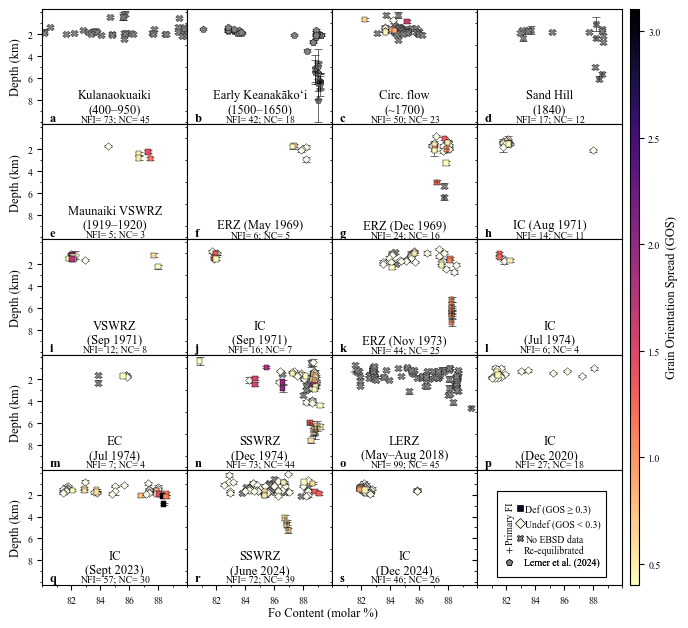

In [520]:
eruption_meta = {
    r"UW":   {"short": "Kulana (400-950)",   "long": "Kulanaokuaiki\n(400–950)"},
    r"K99|SW": {"short": "EK (L24)", "long": "Early Keanakākoʻi\n(1500–1650)"},
    r"K21|921": {"short": "Circ. flow (~1700)", "long": "Circ. flow\n(~1700)"},
    r"L84": {"short": "SH1840", "long": "Sand Hill\n(1840)"},
    r"930": {"short": "Maunaiki \n(1919–20)", "long": "Maunaiki VSWRZ\n(1919–1920)"},
    r"909": {"short": "ERZ69a", "long": "ERZ (May 1969)"},
    r"908": {"short": "ERZ69b", "long": "ERZ (Dec 1969)"},
    r"916": {"short": "IC71a", "long": "IC (Aug 1971)"},
    r"931": {"short": "VSWRZ71", "long": "VSWRZ\n(Sep 1971)"},
    r"914": {"short": "IC71b", "long": "IC\n(Sep 1971)"},
    r"910": {"short": "ERZ73", "long": "ERZ (Nov 1973)"},
    r"917": {"short": "IC74a", "long": "IC\n(Jul 1974)"},
    r"924": {"short": "EC74", "long": "EC\n(Jul 1974)"},
    r"919|920": {"short": "SSWRZ74", "long": "SSWRZ\n(Dec 1974)"},
    r"LL": {"short": "LERZ2018", "long": "LERZ\n(May–Aug 2018)"},
    r"K20": {"short": "IC20", "long": "IC\n(Dec 2020)"},
    r"K23": {"short": "IC23", "long": "IC\n(Sept 2023)"},
    r"K24": {"short": "SSWRZ24", "long": "SSWRZ\n(June 2024)"},
    r"KD24": {"short": "IC24", "long": "IC\n(Dec 2024)"},
}

datasets = []
titles = []

for pat, meta in eruption_meta.items():
    mask = all_data_simplified["Sample"].astype(str).str.contains(pat, regex=True, na=False)
    datasets.append(all_data_simplified.loc[mask])
    titles.append(meta["long"])

######
MM_PER_INCH=25.4
REF_WIDTH_MM  = 190
ROW_HEIGHT_MM = REF_WIDTH_MM

FIG_WIDTH_MM  = REF_WIDTH_MM
FIG_HEIGHT_MM = ROW_HEIGHT_MM

fontsize_small=7
fontsize_large=9

s_small=15
s_large=25
s_stars=40
linewidth_markers=0.3
#####
num_axes = len(datasets)

MAX_COLS = 4
num_cols = min(MAX_COLS, num_axes)
num_rows = int(np.ceil(num_axes / num_cols))

# Generate colors using a seaborn color palette

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.4
global_max = np.nanmax(all_data_simplified[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots( num_rows, num_cols, figsize=( FIG_WIDTH_MM  / MM_PER_INCH, FIG_HEIGHT_MM / MM_PER_INCH ), sharey=True, sharex=True )

axes = np.atleast_1d(axes).flatten()


# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    if 'Fo_Ol_%' in data.columns and not data['Fo_Ol_%'].dropna().empty:
        x = data['Fo_Ol_%']
    else:
        x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    prims= (data['FI_type'] != 'S') # excudes S
    reeq=data['decrepit'].str.contains('y', na=False)#data['Comment'].str.contains('reeq|re=eq|re-eq|req|decrep', na=False)
    so2=~(data['SO2 mol%'] >= SO2_cutoff)
    lerner_weird = data['Fluid inclusion notes'].str.contains("Two-phase", na=False)
    lerner = data['Eruption_title'].str.contains("Keana", na=False)
    base_filters_tmp=(so2)&(prims)&~(lerner_weird)

    is_secondary = ~prims
    has_gos = data['GOS'].notna()
    is_deformed = has_gos & (data['GOS'] >= 0.3)
    is_undeformed = has_gos & (data['GOS'] < 0.3)
    no_ebsd = ~has_gos

    data_plot = data.loc[base_filters_tmp]

    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff = data['GOS'] >= 0.3
        ax.errorbar(x=x[prims&so2], y=data.loc[prims&so2,'SingleCalc_D_km'], yerr=data.loc[prims&so2,'std_dev_MC_D_km'],
            mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)

        # ---------- PRIMARY, NOT REEQ ----------
        ax.scatter( x[~gos_mask & prims &~(lerner)&so2], data.loc[~gos_mask & prims&~(lerner)&so2, 'SingleCalc_D_km'], marker='X', facecolor='grey', edgecolor='k', linewidths=linewidth_markers-0.1, s=s_large, zorder=2 )
        ax.scatter( x[gos_mask & prims & ~gos_cutoff&~(lerner)&so2], data.loc[gos_mask & prims & ~gos_cutoff&~(lerner)&so2, 'SingleCalc_D_km'], color='ivory', marker='D', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=3 )
        ax.scatter( x[gos_mask & prims & gos_cutoff&~(lerner)&so2], data.loc[gos_mask & prims & gos_cutoff&~(lerner)&so2, 'SingleCalc_D_km'], 
                   c=data.loc[gos_mask & prims & gos_cutoff&~(lerner)&so2, colorvar], cmap=palette, norm=norm, marker='s', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=4 )
        ax.scatter( x[lerner], data.loc[lerner, 'SingleCalc_D_km'], marker='p', facecolor='grey', edgecolor='k', linewidths=linewidth_markers, s=s_large, zorder=2 )

        # ---------- REEQUILIBRATED ----------
        ax.scatter( x[reeq|lerner_weird], data.loc[reeq|lerner_weird, 'SingleCalc_D_km'], marker='+', color='k', linewidths=linewidth_markers, s=s_small, zorder=5 )
        # # ---------- SECONDARY ----------

        # ax.scatter( x[~gos_mask & ~prims], data.loc[~gos_mask & ~prims, 'SingleCalc_D_km'], marker='P', color='grey', edgecolors='k', linewidths=linewidth_markers-0.1, s=s_small, zorder=3 )
        # ax.scatter( x[gos_mask & ~prims & ~gos_cutoff], data.loc[gos_mask & ~prims & ~gos_cutoff, 'SingleCalc_D_km'], marker='v', color='ivory', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=4 )
        # ax.scatter( x[gos_mask & ~prims & gos_cutoff], data.loc[gos_mask & ~prims & gos_cutoff, 'SingleCalc_D_km'], c=data.loc[gos_mask & ~prims & gos_cutoff, colorvar], cmap=palette, norm=norm, marker='^', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=5 )
    
    # Set axis limits
    ax.set_ylim([10.25, -0.25])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)',fontsize=fontsize_large)
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    ax.set_yticks([2,4, 6, 8])
    ax.set_xticks([82, 84,86, 88])
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.tick_params(axis='both', which='minor', length=1.5)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= (num_rows - 1) * num_cols))
    
    ### Title annotations and NFI
    x1 = 0.5

    if "\n" in title:
        y1 = 0.19
        y2 = y1 - 0.135
    else:
        y1 = 0.125
        y2 = y1 - 0.08

    ax.annotate( title, xy=(x1, y1), xycoords="axes fraction", fontsize=fontsize_large, ha="center", va="center", color="k" )
    ax.annotate( f"NFI= {(prims & so2).sum()}; NC= {data.loc[prims & so2, 'Sample_crystal'].nunique()}", xy=(x1, y2), xycoords="axes fraction", fontsize=fontsize_small, ha="center", va="center", color="k" )
    # ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(x1+0.32, y2), xycoords='axes fraction', 
    #             fontsize=fontsize-2, ha='center', va='center', color='k')
    #####
    import string
    panel_label = string.ascii_lowercase[i]
    ax.text( 0.05, 0.1, panel_label, transform=ax.transAxes, fontsize=fontsize_large, fontweight='bold', va='top', ha='left' )
    ax.set_yticks([2,4, 6, 8])
    ax.set_xticks([82, 84, 86,88])
# # Hide empty subplots if necessary
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])



############## Composite legend ################
axA = axes[- 1]
Lx = 0.12    # left–right position (axes fraction) 0.15
Ly = 0.80    # up–down position   (axes fraction) 0.35

mew_legend=0.5 # Adjusts the edge thickness of the legend markers
msize=5
######### Primary FI#####
primary_handles = [
   mpl.lines.Line2D([0], [0], marker='s', linestyle='None', markerfacecolor=plt.cm.magma(norm(0.6)),mew=mew_legend, markeredgecolor='k', markersize=msize, label='Def (GOS ≥ 0.3)'),
   mpl.lines.Line2D([0], [0], marker='D', linestyle='None', markerfacecolor='ivory',mew=mew_legend, markeredgecolor='k', markersize=msize, label='Undef (GOS < 0.3)'),
   mpl.lines.Line2D([0], [0], marker='X', linestyle='None', markerfacecolor='grey',mew=mew_legend, markeredgecolor='k', markersize=msize, label='No EBSD data')
]
leg_primary = axA.legend( handles=primary_handles, loc='upper left', bbox_to_anchor=(Lx+0.11, Ly-0.05), frameon=False, handlelength=1.0, handletextpad=0.0, borderpad=0.0)
axA.add_artist(leg_primary)
axA.text( Lx + 0.11, Ly - 0.26, "Primary FI", transform=axA.transAxes, rotation=90, fontsize=fontsize_small, ha='center', va='center' )

# ######### Secondary FI#####
# secondary_handles = [
#    mpl.lines.Line2D([0], [0], marker='^', linestyle='None', markerfacecolor=plt.cm.magma(norm(0.6)), markeredgecolor='k', markersize=msize,mew=mew_legend, label='Def (GOS ≥ 0.3)'),
#    mpl.lines.Line2D([0], [0], marker='v', linestyle='None', markerfacecolor='ivory', markeredgecolor='k', markersize=msize,mew=mew_legend, label='Undef (GOS < 0.3)'),
#    mpl.lines.Line2D([0], [0], marker='P', linestyle='None', markerfacecolor='grey', markeredgecolor='k', markersize=msize,mew=mew_legend, label='No EBSD data')
# ]
# leg_secondary = axA.legend( handles=secondary_handles, loc='upper left', bbox_to_anchor=(Lx + 0.11, Ly), frameon=False, fontsize=fontsize_small, handletextpad=0.001, borderpad=0.0)
# axA.add_artist(leg_secondary)
# axA.text( Lx + 0.15, Ly - 0.16, "Secondary", transform=axA.transAxes, rotation=90, fontsize=fontsize_small, ha='center', va='center' )
######### Reeq FI#####
reeq_handle = [mpl.lines.Line2D([0], [0], marker='+', linestyle='None', color='k', markersize=msize,mew=mew_legend, label='Re-equilibrated')]
leg_reeq = axA.legend( handles=reeq_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.38), frameon=False, fontsize=fontsize_small, handletextpad=0.6, )
axA.add_artist(leg_reeq)
######### Lerner FI#####
lerner_handle = [ mpl.lines.Line2D([0], [0], marker='p', linestyle='None', markerfacecolor='grey', markeredgecolor='k', markersize=msize, mew=mew_legend, label='Lerner et al. (2024)') ]
leg_lerner = axA.legend( handles=lerner_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.48), frameon=False, fontsize=fontsize_small, handletextpad=0.6, )
axA.add_artist(leg_lerner)

######### Box###########

# Dimensions of the legend block (tweak once)
legend_width  = 0.75
legend_height = 0.75

legend_box = mpl.patches.Rectangle( (Lx+0.02, Ly - legend_height + 0.02), legend_width, legend_height, 
                                   transform=axA.transAxes, facecolor='none', edgecolor='k', linewidth=0.8, zorder=10 )

axA.add_patch(legend_box)
################################################
#############COLORBAR###########################
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
bboxes = [ax.get_position() for ax in axes[:len(datasets)]]
bbox = mpl.transforms.Bbox.union(bboxes)
cax = fig.add_axes([ bbox.x1 + 0.01, bbox.y0, 0.012, bbox.height ])
cbar = fig.colorbar( sm, cax=cax, orientation="vertical" )
cbar.set_label("Grain Orientation Spread (GOS)", fontsize=fontsize_large)
cbar.ax.tick_params(labelsize=fontsize_small)
################################################
# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)

# Add x-axis label only on the bottom row
fig.text(0.5, 0.07, 'Fo Content (molar %)', ha='center', fontsize=fontsize_large)

# Save figure
fig.savefig(figpath + slash + 'Fig5_Fodepth_all.pdf', format='pdf', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)
fig.savefig(figpath + slash + 'Fig5_Fodepth_all.png', format='png', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)

plt.show()

### F. FIG 6. Fo depth GOS glass

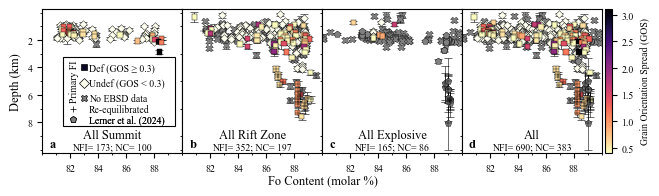

In [521]:
datasets = [
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Explosive"))],
            all_data_simplified,
            ]

titles = [
          "All Summit",
          "All Rift Zone",
          "All Explosive",
          "All",
          ]
######
REF_WIDTH_MM  = 190
REF_HEIGHT_MM = REF_WIDTH_MM/4
FIG_ASPECT = REF_HEIGHT_MM / REF_WIDTH_MM

MM_PER_INCH = 25.4

FIG_WIDTH_MM = 190             
FIG_HEIGHT_MM = FIG_WIDTH_MM * FIG_ASPECT

fontsize_small=7
fontsize_large=9

s_small=15
s_large=25
s_stars=40
linewidth_markers=0.3
#####
num_axes = len(datasets)
num_rows = 1                   
num_cols = int(np.ceil(num_axes /num_rows))
# Generate colors using a seaborn color palette

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.4
global_max = np.nanmax(all_data_simplified[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots( num_rows, num_cols, figsize=( FIG_WIDTH_MM  / MM_PER_INCH, FIG_HEIGHT_MM / MM_PER_INCH ), sharey=True, sharex=True )

axes = np.atleast_1d(axes).flatten()


# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    if 'Fo_Ol_%' in data.columns and not data['Fo_Ol_%'].dropna().empty:
        x = data['Fo_Ol_%']
    else:
        x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    prims= (data['FI_type'] != 'S') # excudes S
    reeq=data['decrepit'].str.contains('y', na=False)#data['Comment'].str.contains('reeq|re=eq|re-eq|req|decrep', na=False)
    so2=~(data['SO2 mol%'] >= SO2_cutoff)
    lerner_weird = data['Fluid inclusion notes'].str.contains("Two-phase", na=False)
    lerner = data['Eruption_title'].str.contains("Keana", na=False)
    base_filters_tmp=(so2)&(prims)&~(lerner_weird)

    is_secondary = ~prims
    has_gos = data['GOS'].notna()
    is_deformed = has_gos & (data['GOS'] >= 0.3)
    is_undeformed = has_gos & (data['GOS'] < 0.3)
    no_ebsd = ~has_gos

    data_plot = data.loc[base_filters_tmp]
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff = data['GOS'] >= 0.3
        ax.errorbar(x=x[prims&so2], y=data.loc[prims&so2,'SingleCalc_D_km'], yerr=data.loc[prims&so2,'std_dev_MC_D_km'],
            mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)

        # ---------- PRIMARY, NOT REEQ ----------
        ax.scatter( x[~gos_mask & prims &~(lerner)&so2], data.loc[~gos_mask & prims&~(lerner)&so2, 'SingleCalc_D_km'], marker='X', facecolor='grey', edgecolor='k', linewidths=linewidth_markers-0.1, s=s_large, zorder=2 )
        ax.scatter( x[gos_mask & prims & ~gos_cutoff&~(lerner)&so2], data.loc[gos_mask & prims & ~gos_cutoff&~(lerner)&so2, 'SingleCalc_D_km'], color='ivory', marker='D', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=3 )
        ax.scatter( x[gos_mask & prims & gos_cutoff&~(lerner)&so2], data.loc[gos_mask & prims & gos_cutoff&~(lerner)&so2, 'SingleCalc_D_km'], 
                   c=data.loc[gos_mask & prims & gos_cutoff&~(lerner)&so2, colorvar], cmap=palette, norm=norm, marker='s', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=4 )
        ax.scatter( x[lerner], data.loc[lerner, 'SingleCalc_D_km'], marker='p', facecolor='grey', edgecolor='k', linewidths=linewidth_markers, s=s_large, zorder=2 )

        # ---------- REEQUILIBRATED ----------
        ax.scatter( x[reeq|lerner_weird], data.loc[reeq|lerner_weird, 'SingleCalc_D_km'], marker='+', color='k', linewidths=linewidth_markers, s=s_small, zorder=5 )
        # # ---------- SECONDARY ----------

        # ax.scatter( x[~gos_mask & ~prims], data.loc[~gos_mask & ~prims, 'SingleCalc_D_km'], marker='P', color='grey', edgecolors='k', linewidths=linewidth_markers-0.1, s=s_small, zorder=3 )
        # ax.scatter( x[gos_mask & ~prims & ~gos_cutoff], data.loc[gos_mask & ~prims & ~gos_cutoff, 'SingleCalc_D_km'], marker='v', color='ivory', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=4 )
        # ax.scatter( x[gos_mask & ~prims & gos_cutoff], data.loc[gos_mask & ~prims & gos_cutoff, 'SingleCalc_D_km'], c=data.loc[gos_mask & ~prims & gos_cutoff, colorvar], cmap=palette, norm=norm, marker='^', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=5 )
    
    # Set axis limits
    ax.set_ylim([10.25, -0.25])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)',fontsize=fontsize_large)
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    ax.set_yticks([2,4, 6, 8])
    ax.set_xticks([82, 84,86, 88])
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.tick_params(axis='both', which='minor', length=1.5)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= (num_rows - 1) * num_cols))
    
    ### Title annotations and NFI
    x1 = 0.5

    if "\n" in title:
        y1 = 0.19
        y2 = y1 - 0.135
    else:
        y1 = 0.125
        y2 = y1 - 0.08

    ax.annotate( title, xy=(x1, y1), xycoords="axes fraction", fontsize=fontsize_large, ha="center", va="center", color="k" )
    ax.annotate( f"NFI= {(prims & so2).sum()}; NC= {data.loc[prims & so2, 'Sample_crystal'].nunique()}", xy=(x1, y2), xycoords="axes fraction", fontsize=fontsize_small, ha="center", va="center", color="k" )
    # ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(x1+0.32, y2), xycoords='axes fraction', 
    #             fontsize=fontsize-2, ha='center', va='center', color='k')
    panel_labels = ['a', 'b', 'c', 'd']
    ax.text( 0.05, 0.1, panel_labels[i], transform=ax.transAxes, fontsize=fontsize_large, fontweight='bold', va='top', ha='left' )
    
# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])



############## Composite legend ################
axA = axes[0]
Lx = 0.12    # left–right position (axes fraction) 0.15
Ly = 0.66    # up–down position   (axes fraction) 0.35

mew_legend=0.5 # Adjusts the edge thickness of the legend markers
msize=5
######### Primary FI#####

primary_handles = [
   mpl.lines.Line2D([0], [0], marker='s', linestyle='None', markerfacecolor=plt.cm.magma(norm(0.6)),mew=mew_legend, markeredgecolor='k', markersize=msize, label='Def (GOS ≥ 0.3)'),
   mpl.lines.Line2D([0], [0], marker='D', linestyle='None', markerfacecolor='ivory',mew=mew_legend, markeredgecolor='k', markersize=msize, label='Undef (GOS < 0.3)'),
   mpl.lines.Line2D([0], [0], marker='X', linestyle='None', markerfacecolor='grey',mew=mew_legend, markeredgecolor='k', markersize=msize, label='No EBSD data')
]
leg_primary = axA.legend( handles=primary_handles, loc='upper left', bbox_to_anchor=(Lx+0.11, Ly), frameon=False, handlelength=1.0, handletextpad=0.0, borderpad=0.0)
axA.add_artist(leg_primary)
axA.text( Lx +0.11, Ly - 0.16, "Primary FI", transform=axA.transAxes, rotation=90, fontsize=fontsize_small, ha='center', va='center' )

######### Reeq FI#####
reeq_handle = [mpl.lines.Line2D([0], [0], marker='+', linestyle='None', color='k', markersize=msize,mew=mew_legend, label='Re-equilibrated')]
leg_reeq = axA.legend( handles=reeq_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.26), frameon=False, fontsize=fontsize_small, handletextpad=0.6, )
axA.add_artist(leg_reeq)
######### Lerner FI#####
lerner_handle = [ mpl.lines.Line2D([0], [0], marker='p', linestyle='None', markerfacecolor='grey', markeredgecolor='k', markersize=msize, mew=mew_legend, label='Lerner et al. (2024)') ]
leg_lerner = axA.legend( handles=lerner_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.33), frameon=False, fontsize=fontsize_small, handletextpad=0.6, )
axA.add_artist(leg_lerner)

######### Box###########

# Dimensions of the legend block (tweak once)
legend_width  = 0.8
legend_height = 0.48

legend_box = mpl.patches.Rectangle( (Lx + 0.03, Ly - legend_height + 0.01), legend_width, legend_height, 
                                   transform=axA.transAxes, facecolor='none', edgecolor='k', linewidth=0.8, zorder=10 )

axA.add_patch(legend_box)
################################################

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=axes[:len(datasets)],
    orientation='vertical',
    label='Grain Orientation Spread (GOS)',
    pad=0.005,        # distance from axes (smaller = closer)
    fraction=0.03,   # width of colorbar
    shrink=1,     # height scaling
    aspect=20        # length/width ratio
)
# Add x-axis label only on the bottom row
fig.text(0.5, -0.05, 'Fo Content (molar %)', ha='center', fontsize=fontsize_large)

# Save figure
fig.savefig(figpath + slash + 'Fig6_Fodepth_GOS.pdf', format='pdf', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)
fig.savefig(figpath + slash + 'Fig6_Fodepth_GOS.png', format='png', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)

plt.show()

### G. Plot Fig 7 (Geophysics)

#### a. Create helper functions
- Synthetic distribution mixture models (these are not resampling, they are just summing weighted gaussians or kdes)

In [522]:
### The first one for multi-component mixing (more than 2)
def mixture_model( *, mode, lims, proportions, components, peak_kwargs=None, n_xs=2000):
    """
    Build N-component mixture distributions using either KDEs or Gaussians.

    Parameters
    ----------
    mode : {'kde', 'gaussian'}
        Representation for components.
    lims : tuple
        (xmin, xmax) domain.
    proportions : iterable of iterables
        Each entry is a mixing vector of length N that sums to 1.
        Example: [[0.3, 0.7], [0.6, 0.4]]
    components : list of dict
        One dict per component.

        KDE mode:
            {'name': str, 'kde': scipy.stats.gaussian_kde}

        Gaussian mode:
            {'name': str, 'mu': float, 'sigma': float}

    peak_kwargs : dict, optional
        Passed to scipy.signal.find_peaks
    """

    if peak_kwargs is None:
        peak_kwargs = {}

    if mode not in {"kde", "gaussian"}:
        raise ValueError("mode must be 'kde' or 'gaussian'")

    N = len(components)
    xs = np.linspace(lims[0], lims[1], n_xs)
    proportions_og=proportions.copy()
    
    proportions = [np.asarray(p, dtype=float) for p in proportions]

    for p in proportions:
        if len(p) != N:
            raise ValueError("Each proportions vector must match number of components")
        if not np.isclose(p.sum(), 1.0):
            raise ValueError(f"Proportions must sum to 1, got {p.sum()}")

    f_components = []
    names = []

    if mode == "kde":
        for comp in components:
            if "kde" not in comp:
                raise ValueError("KDE mode requires 'kde' in each component")
            f_components.append(comp["kde"](xs))
            names.append(comp.get("name", f"comp_{len(names)}"))

        meta = dict(
            xs=xs,
            proportions=proportions_og,
            mode="kde",
            component_names=names,
            f_components=f_components,
        )

    else:  # gaussian
        for comp in components:
            if "mu" not in comp or "sigma" not in comp:
                raise ValueError("Gaussian mode requires 'mu' and 'sigma'")
            mu, sigma = comp["mu"], comp["sigma"]
            f = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
                -0.5 * ((xs - mu) / sigma) ** 2
            )
            f_components.append(f)
            names.append(comp.get("name", f"comp_{len(names)}"))

        meta = dict(
            xs=xs,
            proportions=proportions_og,
            mode="gaussian",
            component_names=names,
            mus=[c["mu"] for c in components],
            sigmas=[c["sigma"] for c in components],
            f_components=f_components,
        )

    res = {}

    for p in proportions:
        f_mix = np.zeros_like(xs)
        for w, f in zip(p, f_components):
            f_mix += w * f

        peaks, _ = signal.find_peaks(f_mix, **peak_kwargs)
        mix_modes = xs[peaks]

        key = tuple(p)
        res[key] = dict(
            mix_vals=f_mix,
            mix_modes=mix_modes,
        )

    res["meta"] = meta
    return res

### The second only for 2 components
def two_component_mixture( *, mode, lims, proportions, kde_hmm=None, kde_sc=None, mu_hm=None, sigma_hm=None, mu_sc=None, sigma_sc=None, peak_kwargs=None):
    """
    Build two-component mixture distributions using either KDEs or Gaussians.

    Parameters
    ----------
    mode : {'kde', 'gaussian'}
        Which representation to use.
    xs : array
        Grid on which PDFs are evaluated.
    proportions : iterable
        Mixing weights for component HM (0 < p < 1).

    KDE mode requires:
        kde_hmm, kde_sc : scipy.stats.gaussian_kde

    Gaussian mode requires:
        mu_hm, sigma_hm, mu_sc, sigma_sc : float
    """

    if peak_kwargs is None:
        peak_kwargs = {}

    if mode not in {"kde", "gaussian"}:
        raise ValueError(f"`mode` must be 'kde' or 'gaussian', got '{mode}'")
    
    xs = np.linspace(lims[0],lims[1], 2000)

    if mode == "kde":
        if kde_hmm is None or kde_sc is None:
            raise ValueError("KDE mode requires `kde_hmm` and `kde_sc`.")
        f_hm_vals = kde_hmm(xs)
        f_sc_vals = kde_sc(xs)

        meta = dict(
            xs=xs,
            proportions=proportions,
            mu_hm=np.nan,
            mu_sc=np.nan,
            sigma_hm=np.nan,
            sigma_sc=np.nan,
            f_hm=f_hm_vals,
            f_sc=f_sc_vals,
            mode="kde",
        )

    elif mode == "gaussian":
        if None in (mu_hm, sigma_hm, mu_sc, sigma_sc):
            raise ValueError( "Gaussian mode requires mu_hm, sigma_hm, mu_sc, sigma_sc." )

        f_hm_vals = (1.0 / (sigma_hm * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu_hm) / sigma_hm) ** 2)
        f_sc_vals = (1.0 / (sigma_sc * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu_sc) / sigma_sc) ** 2)

        meta = dict(
            xs=xs,
            proportions=proportions,
            mu_hm=mu_hm,
            mu_sc=mu_sc,
            sigma_hm=sigma_hm,
            sigma_sc=sigma_sc,
            f_hm=f_hm_vals,
            f_sc=f_sc_vals,
            mode="gaussian",
        )

    res = {}

    for p1 in proportions:
        p2 = 1.0 - p1
        f_mix_vals = p1 * f_hm_vals + p2 * f_sc_vals
        peaks, _ = signal.find_peaks(f_mix_vals, **peak_kwargs)
        mix_modes = xs[peaks]

        res[p1] = dict(
            mix_vals=f_mix_vals,
            mix_modes=mix_modes,
        )

    res["meta"] = meta
    return res

#### Example of multi-component mixture model

### real 2 dist KDE mixture
proportions=[ [0.3, 0.7], [0.6, 0.4], [0.9, 0.1]]

hmm_data=geophysics[hm]['Depth (km)'].dropna().astype(float).to_numpy()
sc_data=geophysics[sc]['Depth (km)'].dropna().astype(float).to_numpy()

kde_hmm = stats.gaussian_kde(hmm_data, bw_method='silverman')
kde_sc  = stats.gaussian_kde(sc_data,  bw_method='silverman')

lims  = (min(np.min(hmm_data), np.min(sc_data)), max(np.max(hmm_data), np.max(sc_data)))

components = [
    {"name": "HM", "kde": kde_hmm},
    {"name": "SC", "kde": kde_sc},
]

res_real2dist_multi = mixture_model( mode="kde", lims=lims, 
                              proportions=proportions, components=components)

### Gaussians
lims = (0,10)
proportions=[ [0.3, 0.7], [0.6, 0.4], [0.9, 0.1]]

#### means and sigmas mixture

components = [
    {"name": "HM", "mu": 1.56, "sigma": 0.69},
    {"name": "SC", "mu": 3.05, "sigma": 1.14},
]
res_gauss_means_multi = mixture_model( mode="gaussian", lims=lims, 
                                proportions=proportions, components=components)
#### STACK (Poland 2014) Gaussian mix

components = [
    {"name": "HM", "mu": 1.5, "sigma": 0.5},
    {"name": "SC", "mu": 4, "sigma": 1},
]
res_gauss_stack_multi = mixture_model( mode="gaussian", lims=lims, 
                                proportions=proportions, components=components)

#### b. Calculate the mixtures
- This is "analytical", the mixtures are weighted sums of functions (gauss or KDEs) rather than simulations, for all we use 30,60 and 90% HMMR. 
- 1st model: Weighted Gaussian mixture using typical STACK model (Poland 2014), 4+-1 km and 1.5+-0.5 km as means and sigmas to represent 3-5 km and 1-2 km ranges quoted. 
- 2nd model: Weighted Gaussian mixture using means and sigmas of the real Geophysical distributions for HMMR and SCR
- 3rd model: Weighted mixture of KDEs of the real Geophysical distributions for HMMR and SCR

In [523]:
x_hm=(pd.to_numeric(geophysics[hm]['Depth (km)'], errors='coerce'))
x_sc=(pd.to_numeric(geophysics[sc]['Depth (km)'], errors='coerce'))
round_dec=2

mean_sc=np.round(np.mean(x_sc),decimals=round_dec)
std_sc=np.round(np.std(x_sc),decimals=round_dec)
mean_hm=np.round(np.mean(x_hm),decimals=round_dec)
std_hm=np.round(np.std(x_hm),decimals=round_dec)

median_sc=np.round(np.median(x_sc),decimals=round_dec)
mad_sc=np.round(np.median(np.absolute(x_sc - np.median(x_sc))),decimals=round_dec)
median_hm=np.round(np.median(x_hm),decimals=round_dec)
mad_hm=np.round(np.median(np.absolute(x_hm - np.median(x_hm))),decimals=round_dec)

print("SCR geophysics mean±1sig: " + str(mean_sc)+"±"+str(std_sc))
print("HMMR geophysics mean±1sig: " + str(mean_hm) +"±"+str(std_hm))
print("SCR geophysics median±1MAD: " + str(median_sc)+"±"+str(mad_sc))
print("HMMR geophysics median±1 MAD: " + str(median_hm)+"±"+str(mad_hm))


SCR geophysics mean±1sig: 3.05±1.14
HMMR geophysics mean±1sig: 1.56±0.69
SCR geophysics median±1MAD: 3.0±0.5
HMMR geophysics median±1 MAD: 1.45±0.45


In [524]:
############# This is using the 2-component mixture model

### Gaussians 
proportions = [0.3, 0.6,0.9] ## mixture proportions 0-1 (% HMMR)
lims = (0,10) ### Limits of the range to evaluate the functions

#### STACK (Poland 2014) Gaussian mix
res_gauss_stack = two_component_mixture( mode="gaussian", lims=lims, proportions=proportions, 
                                        mu_hm=1.5, sigma_hm=0.5, mu_sc=4.0, sigma_sc=1.0)

#### means and sigmas mixture
res_gauss_means = two_component_mixture( mode="gaussian", lims=lims, proportions=proportions, 
                                        mu_hm=1.56, sigma_hm=0.69, mu_sc=3.05, sigma_sc=1.14)

#### medians and mads mixture
res_gauss_medians = two_component_mixture( mode="gaussian", lims=lims, proportions=proportions, 
                                        mu_hm=1.45, sigma_hm=0.45, mu_sc=3.0, sigma_sc=0.5)

### real 2 dist KDE mixture
hmm_data=geophysics[hm]['Depth (km)'].dropna().astype(float).to_numpy()
sc_data=geophysics[sc]['Depth (km)'].dropna().astype(float).to_numpy()

kde_hmm = stats.gaussian_kde(hmm_data, bw_method='silverman')
kde_sc  = stats.gaussian_kde(sc_data,  bw_method='silverman')

lims  = (min(np.min(hmm_data), np.min(sc_data)), max(np.max(hmm_data), np.max(sc_data)))

res_real2dist = two_component_mixture( mode="kde", lims=lims, proportions=[0.3, 0.6, 0.9], 
                                          kde_hmm=kde_hmm, kde_sc=kde_sc)


#### c. Plot Fig

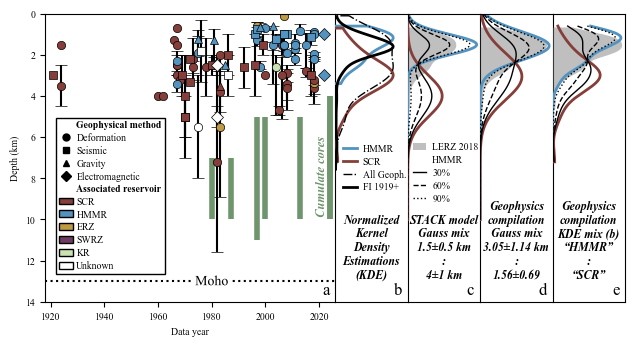

In [525]:
methods = ['Deformation', 'Seismic', 'Gravity','Electromagnetic']
markers = ['o', 's', '^', 'D', 'd','*']

means_or_medians_panel_d='means'
if means_or_medians_panel_d=='medians':
    res_gauss_panel_d=res_gauss_medians.copy()
    m_sc=median_sc.copy()
    m_hm=median_hm.copy()
    dev_sc=mad_sc.copy()
    dev_hm=mad_hm.copy()
elif means_or_medians_panel_d=='means':
    res_gauss_panel_d=res_gauss_means.copy()
    m_sc=mean_sc.copy()
    m_hm=mean_hm.copy()
    dev_sc=std_sc.copy()
    dev_hm=std_hm.copy()
else:
    raise ValueError("INVALID value of means_or_medians_panel_d: please pick 'means' or 'medians'")

color_by_col = 'Region (SCR, HMMR, KR, ERZ, SWRZ) '
chosen_cmap=cmc.cm.romaO
# chosen_cmap='plasma'
unique_vals = geophysics[color_by_col].dropna().astype(str).unique()
colors_map = {val: cmc.cm.romaO(s) for val, s in zip(unique_vals, [0.1, 0.75, 0.32, 0.98,0.5,0.7])}
# colors_map = {val: mpl.colormaps[chosen_cmap](s) for val, s in zip(unique_vals, np.linspace(0, 1, len(unique_vals)))}

## Set up the plotting area
inch=25.4
fig = plt.figure(figsize=(190/inch, 95/inch))
gs = fig.add_gridspec(1, 5, width_ratios=[4, 1,1,1,1], wspace=0)

ax = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1], sharey=ax)
ax_c = fig.add_subplot(gs[2], sharey=ax)
ax_d = fig.add_subplot(gs[3], sharey=ax)
ax_e = fig.add_subplot(gs[4], sharey=ax)

## Now plot things

## Cumulates
ax.vlines(x=geophysics['Publication year'],
          ymin=geophysics['Cumulate upper depth (km)'].astype('float64'),
          ymax=geophysics['Cumulate lower depth (km)'].astype('float64'),
          colors="#6F956D", linestyles='-', label='Cumulate cores', linewidths=4)

# Geophysics on panel a
for method, marker in zip(methods, markers):
    mask = geophysics['Main Geophysical method (Deformation, Seismic, Gravity, Electromagnetic)'].str.contains(method, na=False)
    subset = geophysics[mask]

    for _, row in subset.iterrows():
        x = float(row['Data year'])
        y = float(row['Depth (km)'])
        yerr = [[float(row['Depth uncertainty left (-km)'])], [float(row['Depth uncertainty right (+km)'])]]

        color_key = str(row[color_by_col])
        chosen_color = colors_map.get(color_key, 'white')

        ax.errorbar(x, y, yerr=yerr, fmt=marker, color=chosen_color,
                    ecolor='black', capsize=4, mec='k', markeredgewidth=0.5)

## Moho line
moho_line = ax.axhline(y=13, color='black', linestyle=':', linewidth=1.5, label='Moho')
labelLines([moho_line], xvals=[1980],align=True, fontsize=10, color='k',outline_color='white', outline_width=5, zorder=10)

pre18_gp=~(geophysics['Data year'].astype(float)>2017)
post18_gp=geophysics['Data year'].astype(float)>2017


half_violin(ax_b,geophysics[hm]['Depth (km)'].dropna().astype(float),
    side="right",fill=False,color=colors_map['HMMR'],linewidth=2,bw_method="silverman",
)
half_violin(ax_b,geophysics[sc]['Depth (km)'].dropna().astype(float),
    side="right",fill=False,color=colors_map['SCR'],linewidth=2,bw_method="silverman",
)

half_violin(ax_b,geophysics['Depth (km)'].dropna().astype(float),
    side="right",fill=False,color="k",linewidth=1,linestyle='-.',bw_method="silverman",
)

half_violin(ax_b, all_data_simplified[(~all_data_simplified['Sample'].str.contains('L84|UW|K21|921')) &base_filters]['SingleCalc_D_km'].dropna().astype(float),
    side="right",fill=False,color="black",linewidth=2,linestyle='-',bw_method="silverman",
)

##### plot synthetics
lerz2018_data=all_data_simplified[(all_data_simplified['Sample'].str.contains("LL"))&(base_filters)]['SingleCalc_D_km'].dropna().astype(float)
lerz2018_kde = stats.gaussian_kde(lerz2018_data, bw_method='silverman')

low_lerz2018  = min(np.min(lerz2018_data), np.min(lerz2018_data))
high_lerz2018 = max(np.max(lerz2018_data), np.max(lerz2018_data))
xs_lerz2018 = np.linspace(low_lerz2018, high_lerz2018, 2000)

##### panel c
ax_c.plot(res_gauss_stack["meta"]["f_hm"], res_gauss_stack["meta"]['xs'],color=colors_map['HMMR'], lw=2,label="HMM KDE")
ax_c.plot(res_gauss_stack["meta"]["f_sc"],res_gauss_stack["meta"]['xs'],color=colors_map['SCR'], lw=2,label="SC KDE")

linestyles = ['-', '--', ':', '-.']
for p1,ls in zip(res_gauss_stack["meta"]['proportions'],linestyles):
    ax_c.plot(res_gauss_stack[p1]["mix_vals"], res_gauss_panel_d["meta"]['xs'],
              lw=1,label=f"Mix ({p1*100:.0f}% HMM)",color="k",linestyle=ls)

# ax_c.plot(lerz2018_kde(xs_lerz2018), xs_lerz2018,color="#313CD3", lw=2,label="LERZ2018_KDE")
ax_c.fill_betweenx(xs_lerz2018, 0,lerz2018_kde(xs_lerz2018), color="grey", alpha=0.5,lw=0,label="LERZ2018_KDE")

###### panel d

ax_d.plot(res_gauss_panel_d["meta"]["f_hm"],res_gauss_panel_d["meta"]['xs'],color=colors_map['HMMR'], lw=2,label="HMM KDE")
ax_d.plot(res_gauss_panel_d["meta"]["f_sc"], res_gauss_panel_d["meta"]['xs'],color=colors_map['SCR'], lw=2,label="SC KDE")

linestyles = ['-', '--', ':', '-.']
for p1,ls in zip(res_gauss_panel_d["meta"]['proportions'],linestyles):
    ax_d.plot(res_gauss_panel_d[p1]["mix_vals"], res_gauss_panel_d["meta"]['xs'],
              lw=1,label=f"Mix ({p1*100:.0f}% HMM)",color="k",linestyle=ls)

# ax_d.plot(lerz2018_kde(xs_lerz2018), xs_lerz2018,color="#313CD3", lw=2,label="LERZ2018_KDE")
ax_d.fill_betweenx(xs_lerz2018, 0,lerz2018_kde(xs_lerz2018), color="grey", alpha=0.5,lw=0,label="LERZ2018_KDE")

##### panel e
ax_e.plot(res_real2dist["meta"]["f_hm"], res_real2dist["meta"]['xs'],color=colors_map['HMMR'], lw=2,label="HMM KDE")
ax_e.plot(res_real2dist["meta"]["f_sc"], res_real2dist["meta"]['xs'],color=colors_map['SCR'], lw=2,label="SC KDE")

linestyles = ['-', '--', ':', '-.']
for p1,ls in zip(res_real2dist["meta"]['proportions'],linestyles):
    ax_e.plot(res_real2dist[p1]["mix_vals"], res_real2dist["meta"]['xs'],
              lw=1,label=f"Mix ({p1*100:.0f}% HMM)",color="k",linestyle=ls)

# ax_e.plot(lerz2018_kde(xs_lerz2018), xs_lerz2018,color="#313CD3", lw=2,label="LERZ2018_KDE")
ax_e.fill_betweenx(xs_lerz2018, 0,lerz2018_kde(xs_lerz2018), color="grey", alpha=0.5,lw=0,label="LERZ2018_KDE")


# ## Plot setup and legend handling

ax.set(xlabel='Data year',ylabel='Depth (km)',ylim=(14, 0),xlim=(1918, 2026),)
ax.patch.set_alpha(0)

for a, label, x in zip((ax, ax_b, ax_c, ax_d, ax_e), "abcde",(0.98, 0.92, 0.92, 0.92, 0.92)):
    a.text(x, 0.01, label, fontsize=12,transform=a.transAxes, ha='right', va='bottom')

for a in (ax_b, ax_c, ax_d, ax_e):
    a.spines['left'].set_visible(False)
    a.tick_params(left=False, labelleft=False,
                  bottom=False, labelbottom=False)
    a.yaxis.label.set_visible(False)
    a.set_xlim(0)
    a.patch.set_alpha(0)

panel_text = {
    ax_b: ("Normalized\nKernel\nDensity\nEstimations\n(KDE)", 0.07),
    ax_c: ("STACK model\nGauss mix\n1.5±0.5 km\n:\n4±1 km", 0.07),
    ax_d: ("Geophysics\ncompilation\nGauss mix\n"+str(m_sc)+"±"+str(dev_sc)+" km\n:\n"+str(m_hm)+"±"+str(dev_hm), 0.07),
    ax_e: ("Geophysics\ncompilation\nKDE mix (b)\n“HMMR”\n:\n“SCR”", 0.07),
}

for a, (txt, y) in panel_text.items():
    a.text( 0.5, y, txt, transform=a.transAxes, ha="center", va="bottom", 
           fontsize=8.5, fontstyle="italic", fontweight="bold" )

ax.text(2021, 7.9,"Cumulate cores", color="#6F956D", rotation=90, fontsize=9, fontstyle="italic", fontweight="bold", va="center", ha="center" )

handles, labels = ax.get_legend_handles_labels()
handles_filtered = [h for h, l in zip(handles, labels) if l not in ['Moho','Cumulate cores']]
labels_filtered = [l for l in labels if l not in ['Moho','Cumulate cores']]
method_handles = [mpl.lines.Line2D([], [], color='black', marker=m, linestyle='None', markersize=5, label=method) for method, m in zip(methods, markers)]
region_handles = [mpl.patches.Patch(facecolor=colors_map[val], label=val,edgecolor='k') for val in unique_vals]
nan_handle = mpl.patches.Patch(facecolor='white', label='Unknown',edgecolor='k')
region_handles.append(nan_handle)

header_methods = mpl.lines.Line2D([], [], linestyle='None', label='Geophysical method')
header_regions = mpl.lines.Line2D([], [], linestyle='None', label='Associated reservoir')

all_handles = handles_filtered+[header_methods] + method_handles + [header_regions] + region_handles
all_labels  = [h.get_label() for h in all_handles]

leg=ax.legend(all_handles,all_labels,
                loc='lower left',bbox_to_anchor=(0.02, 0.08),fancybox=False, 
                edgecolor='black',ncol=1,fontsize=7,framealpha=1,
                labelspacing=0.3,handletextpad=0.4,
                borderpad=0.3,handlelength=1.4)

for text, handle in zip(leg.texts, all_handles):
    text.set_fontweight('bold' if handle in (header_methods, header_regions) else 'normal')

legend_elements_b = [
    mpl.lines.Line2D([0], [0], color=colors_map['HMMR'], lw=2, label='HMMR'),
    mpl.lines.Line2D([0], [0], color=colors_map['SCR'], lw=2, label='SCR'),
    mpl.lines.Line2D([0], [0], color='k', lw=1, linestyle='-.', label='All Geoph.'),
    mpl.lines.Line2D([0], [0], color='black', lw=2, label='FI 1919+'),
]
leg_b = ax_b.legend( handles=legend_elements_b, loc='lower left', 
                    bbox_to_anchor=(-0.01, 0.35), fontsize=7, frameon=False, fancybox=False, 
                    edgecolor='black', framealpha=1, handlelength=1.4, handletextpad=0.6, labelspacing=0.3, borderpad=0.4 )

legend_elements_c = ([ mpl.patches.Patch( facecolor='grey', edgecolor='none', alpha=0.5, label='LERZ 2018' )]+[mpl.lines.Line2D( [0], [0], color='none', lw=0, label='HMMR' ) ]
    +[ mpl.lines.Line2D( [0], [0], color='k', lw=1, linestyle=ls, label=f"{int(p1*100)}%" ) for p1, ls in zip( res_gauss_stack["meta"]["proportions"], ['-', '--', ':', '-.'] ) ]
    )
leg_c = ax_c.legend(handles=legend_elements_c, loc='lower left', 
                    bbox_to_anchor=(-0.05, 0.31), fontsize=7, frameon=False, fancybox=False, 
                    edgecolor='black', framealpha=1, handlelength=1.4, handletextpad=0.6, labelspacing=0.3, borderpad=0.4)

ax_d.legend()
ax_e.legend()
ax_d.legend_.remove()
ax_e.legend_.remove()

plt.show()
fig.savefig(figpath + slash + 'Fig7_Geophysics_FI.pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)
fig.savefig( figpath + slash + 'Fig7_Geophysics_FI.png', dpi=300, bbox_inches='tight', pad_inches=0.01)



### H. Plot Fig 9 CDF

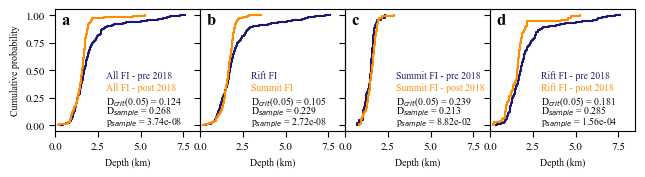

In [526]:
inch = 25.4

fig = plt.figure(figsize=(190/inch, 40/inch))

gs = mpl.gridspec.GridSpec(
    nrows=1,
    ncols=4,
    wspace=0
)
ax_b = fig.add_subplot(gs[0, 0])
ax_c = fig.add_subplot(gs[0, 1])
ax_d = fig.add_subplot(gs[0, 2])
ax_e = fig.add_subplot(gs[0, 3])
###### KS dists 
legend_x = 0.35
legend_y= 0.5
legend_y2=legend_y-0.1
legend_y_labels = (legend_y, legend_y-0.1)
legend_y_stats  = legend_y2-0.1
lgd_fontsize=7
linespacing=0.7

plot_cdf_ks( ax=ax_b, res=all_prevspost2018_ks, data1_label="All FI - pre 2018", data2_label="All FI - post 2018", lgd_fontsize=lgd_fontsize,show_legend=True,
            plot_bootstrap=False,    legend_x=legend_x,    legend_y_labels=legend_y_labels,    legend_y_stats=legend_y_stats,linespacing=linespacing)
plot_cdf_ks( ax=ax_c, res=summitrift_all_ks, data1_label="Rift FI", data2_label="Summit FI", lgd_fontsize=lgd_fontsize,show_legend=True,
            plot_bootstrap=False,    legend_x=legend_x,    legend_y_labels=legend_y_labels,    legend_y_stats=legend_y_stats,linespacing=linespacing)
plot_cdf_ks( ax=ax_d, res=summit_prevspost2018_ks, data1_label="Summit FI - pre 2018", data2_label="Summit FI - post 2018", lgd_fontsize=lgd_fontsize,show_legend=True,
            plot_bootstrap=False,    legend_x=legend_x,    legend_y_labels=legend_y_labels,    legend_y_stats=legend_y_stats,linespacing=linespacing)  
plot_cdf_ks( ax=ax_e, res=rifts_prevspost2018_ks, data1_label="Rift FI - pre 2018", data2_label="Rift FI - post 2018", lgd_fontsize=lgd_fontsize,show_legend=True,
            plot_bootstrap=False,    legend_x=legend_x,    legend_y_labels=legend_y_labels,    legend_y_stats=legend_y_stats,linespacing=linespacing)  

for ax in [ax_b, ax_c, ax_d, ax_e]:
    ax.patch.set_visible(False)

for ax in [ax_b, ax_c, ax_d, ax_e]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')
for ax in [ax_b, ax_c, ax_d, ax_e]:
    ax.tick_params( axis='both', which='both', direction='out', top=False, right=False, labelsize=8, length=4 )     

ax_b.set_ylabel("Cumulative probability", fontsize=7)

for ax in [ax_c, ax_d, ax_e]:
    ax.set_ylabel(None)
    ax.tick_params(labelleft=False)

for ax in [ax_b, ax_c, ax_d, ax_e]:
    ax.set_xlabel("Depth (km)", fontsize=7)
    
for ax in [ax_b, ax_c, ax_d, ax_e]:
    ax.set_xlim(0, 8.5)
    ax.set_ylim(-0.05, 1.05)

panel_labels = ['a', 'b', 'c', 'd']

for label, ax in zip(panel_labels, [ax_b, ax_c, ax_d, ax_e]):
    ax.text(0.04, 0.97, label, transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='left' )



for ax in fig.axes:
    ax.set_facecolor('none')
    ax.patch.set_alpha(0)

fig.patch.set_facecolor('white')
fig.patch.set_alpha(1)

plt.subplots_adjust(wspace=0)

fig.savefig(figpath + slash + 'Fig9_cdf.pdf', format='pdf', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)
fig.savefig( figpath + slash + 'Fig9_cdf.png', dpi=300, bbox_inches='tight', pad_inches=0.02)


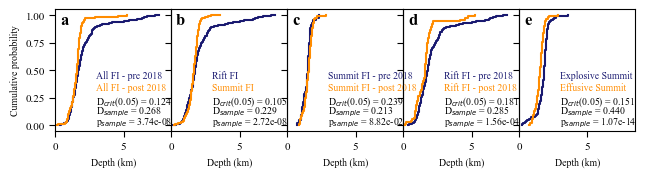

In [527]:
inch = 25.4

fig = plt.figure(figsize=(190/inch, 40/inch))

gs = mpl.gridspec.GridSpec(
    nrows=1,
    ncols=5,
    wspace=0
)
ax_b = fig.add_subplot(gs[0, 0])
ax_c = fig.add_subplot(gs[0, 1])
ax_d = fig.add_subplot(gs[0, 2])
ax_e = fig.add_subplot(gs[0, 3])
ax_f = fig.add_subplot(gs[0, 4])
###### KS dists 
legend_x = 0.35
legend_y= 0.5
legend_y2=legend_y-0.1
legend_y_labels = (legend_y, legend_y-0.1)
legend_y_stats  = legend_y2-0.1
lgd_fontsize=7
linespacing=0.7

plot_cdf_ks( ax=ax_b, res=all_prevspost2018_ks, data1_label="All FI - pre 2018", data2_label="All FI - post 2018", lgd_fontsize=lgd_fontsize,show_legend=True,
            plot_bootstrap=False,    legend_x=legend_x,    legend_y_labels=legend_y_labels,    legend_y_stats=legend_y_stats,linespacing=linespacing)
plot_cdf_ks( ax=ax_c, res=summitrift_all_ks, data1_label="Rift FI", data2_label="Summit FI", lgd_fontsize=lgd_fontsize,show_legend=True,
            plot_bootstrap=False,    legend_x=legend_x,    legend_y_labels=legend_y_labels,    legend_y_stats=legend_y_stats,linespacing=linespacing)
plot_cdf_ks( ax=ax_d, res=summit_prevspost2018_ks, data1_label="Summit FI - pre 2018", data2_label="Summit FI - post 2018", lgd_fontsize=lgd_fontsize,show_legend=True,
            plot_bootstrap=False,    legend_x=legend_x,    legend_y_labels=legend_y_labels,    legend_y_stats=legend_y_stats,linespacing=linespacing)  
plot_cdf_ks( ax=ax_e, res=rifts_prevspost2018_ks, data1_label="Rift FI - pre 2018", data2_label="Rift FI - post 2018", lgd_fontsize=lgd_fontsize,show_legend=True,
            plot_bootstrap=False,    legend_x=legend_x,    legend_y_labels=legend_y_labels,    legend_y_stats=legend_y_stats,linespacing=linespacing)  
plot_cdf_ks( ax=ax_f, res=explosive_vs_effusive_summit, data1_label="Explosive Summit", data2_label="Effusive Summit", lgd_fontsize=lgd_fontsize,show_legend=True,
            plot_bootstrap=False,    legend_x=legend_x,    legend_y_labels=legend_y_labels,    legend_y_stats=legend_y_stats,linespacing=linespacing)  

for ax in [ax_b, ax_c, ax_d, ax_e,ax_f]:
    ax.patch.set_visible(False)

for ax in [ax_b, ax_c, ax_d, ax_e,ax_f]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')
for ax in [ax_b, ax_c, ax_d, ax_e,ax_f]:
    ax.tick_params( axis='both', which='both', direction='out', top=False, right=False, labelsize=8, length=4 )     

ax_b.set_ylabel("Cumulative probability", fontsize=7)

for ax in [ax_c, ax_d, ax_e,ax_f]:
    ax.set_ylabel(None)
    ax.tick_params(labelleft=False)

for ax in [ax_b, ax_c, ax_d, ax_e,ax_f]:
    ax.set_xlabel("Depth (km)", fontsize=7)
    
for ax in [ax_b, ax_c, ax_d, ax_e,ax_f]:
    ax.set_xlim(0, 8.5)
    ax.set_ylim(-0.05, 1.05)

panel_labels = ['a', 'b', 'c', 'd','e']

for label, ax in zip(panel_labels, [ax_b, ax_c, ax_d, ax_e,ax_f]):
    ax.text(0.04, 0.97, label, transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='left' )



for ax in fig.axes:
    ax.set_facecolor('none')
    ax.patch.set_alpha(0)

fig.patch.set_facecolor('white')
fig.patch.set_alpha(1)

plt.subplots_adjust(wspace=0)

fig.savefig(figpath + slash + 'Fig9_cdf_explo-effu.pdf', format='pdf', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)
fig.savefig( figpath + slash + 'Fig9_cdf-explo-effu.png', dpi=300, bbox_inches='tight', pad_inches=0.02)


### I. Plot Fig 10. comparison SWRZ

In [528]:
def make_row_axes(fig, gs, row_idx, num_panels, num_cols):
    """
    fig        : matplotlib figure
    gs         : GridSpec
    row_idx    : which row to populate
    num_panels : how many axes in this row
    num_cols   : total number of GS columns
    """
    cols_per_panel = num_cols // num_panels
    axes = []

    for i in range(num_panels):
        start = i * cols_per_panel
        end   = (i + 1) * cols_per_panel
        ax = fig.add_subplot(gs[row_idx, start:end])
        axes.append(ax)

    return axes


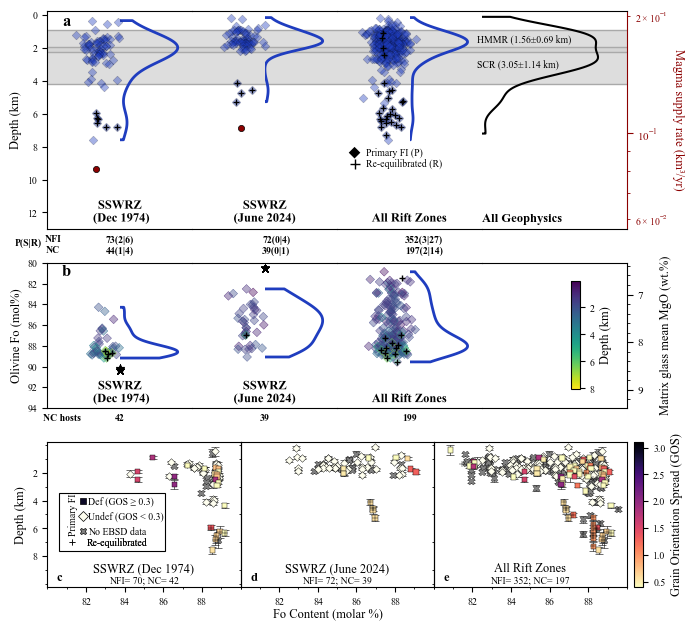

In [529]:

datasets = [
            all_data_simplified[(all_data_simplified['Sample'].str.contains('919|920'))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K24"))],
            # all_data_simplified[(all_data_simplified['Sample'].str.contains("K21|921|L84|930|908|909|910|931|919|920"))],
            # all_data_simplified[(all_data_simplified['Sample'].str.contains("LL|K24"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ"))],
            geophysics
            ]

titles = [
          "SSWRZ\n (Dec 1974)",
          "SSWRZ\n(June 2024)", 
        #   "Pre-2018 RZs",
        #   "Post-2018 RZs",
          "All Rift Zones",
          "All Geophysics"
          ]


# datasets_filtered_violins = [df[base_filters] for df in datasets]
num_axes = len(datasets)
 ## These were calculated weird using mass balance approach, we filter them out

# ylims=(90,75)
# xlims=(0,0.5)
ylims=(13,-0.25)
xlims=(-0.5,0.5)
plot_var='SingleCalc_D_km'

# fig, axes = plt.subplots(1, num_axes, figsize=(10, 4), sharey=True)

inch=25.4

fig = plt.figure(figsize=(190/inch, 190/inch))
gs = mpl.gridspec.GridSpec(
    nrows=3,
    ncols=num_axes,
    height_ratios=[3, 2,2],
    hspace=0.2,
    wspace=0
)

# top row (your existing violin axes)
axes = [fig.add_subplot(gs[0, i]) for i in range(num_axes)]

for ax in axes:
    # grey filled bands (unchanged)
    for y0, y1 in [(1, 2), (3, 5)]:
        # ax.axhspan(y0, y1, facecolor='lightgrey', alpha=0.5, zorder=-301)
        ax.axhspan(mean_hm - std_hm,mean_hm + std_hm,facecolor='lightgrey', alpha=0.5, zorder=-301)
        ax.axhspan(mean_sc - std_sc,mean_sc + std_sc,facecolor='lightgrey', alpha=0.5, zorder=-301)
    # # light‑blue reference lines (means ± std)
    for y in [mean_hm - std_hm, mean_hm + std_hm]:
        ax.axhline(y, color='darkgrey', linestyle='-', alpha=1,linewidth=1, zorder=-300)

    for y in [mean_sc - std_sc, mean_sc + std_sc]:
        ax.axhline(y, color='darkgrey', linestyle='-', alpha=1,linewidth=1, zorder=-300)

# # bottom row panels (b–e placeholders)

n_bottom = 3
gs_bottom = GridSpecFromSubplotSpec(
    1, n_bottom,
    subplot_spec=gs[2, :],
    wspace=0
)

bottom_axes = [fig.add_subplot(gs_bottom[0, i]) for i in range(n_bottom)]
ax_c, ax_d, ax_e = bottom_axes



## magma supply curve
bboxes = [ax.get_position() for ax in axes]
left   = min(b.x0 for b in bboxes)
right  = max(b.x1 for b in bboxes)
bottom = min(b.y0 for b in bboxes)
top    = max(b.y1 for b in bboxes)

ax_supply = fig.add_axes([left, bottom, right - left, top - bottom],frameon=False)
ax_supply.set_zorder(-10)     # put supply axis behind FI axes
ax_supply.patch.set_alpha(0)


magsup_filt = magsup[
    (~magsup['Location name'].str.contains("Dec 1974|Late Keanakākoʻi era flow?", na=False)) &
    (magsup['Start year'] != 1410)
].copy()

magma_supply = magsup_filt['Magma supply km3/yr'].astype(float).values
supply_x = np.full(len(magsup_filt), np.nan)

for i, tag in enumerate(magsup_filt["Location name_year"]):
    if "Maunaulu" in tag:
        supply_x[i] = 0.5
    elif tag.endswith("4_2024"):
        supply_x[i] = 3.5#2.5

ax_supply.set_xlim(-0.5, 11.5)  # last eruption panel = Dec 2024

valid = np.isfinite(supply_x) & np.isfinite(magma_supply)

supply_x = supply_x[valid]
magma_supply = magma_supply[valid]

ax_supply.set_yscale('log')

ax_supply.set_ylim(
    magma_supply.min() * 0.7,
    magma_supply.max() * 2
)

ax_supply.yaxis.set_label_position("right")
ax_supply.yaxis.tick_right()

ax_supply.spines['right'].set_visible(False)
ax_supply.spines['left'].set_visible(False)
ax_supply.spines['top'].set_visible(False)
ax_supply.spines['bottom'].set_visible(False)

ax_supply.set_xticks([])
ax_supply.patch.set_alpha(0)

supply_color = "darkred"

# ax_supply.plot( supply_x, magma_supply, color=supply_color, lw=2, zorder=-201)
ax_supply.scatter(supply_x, magma_supply,edgecolors='k',linewidths=0.5, color='darkred', s=20, zorder=11 )

ax_supply.set_ylabel( "Magma supply rate (km³/yr)", fontsize=9, rotation=270, labelpad=12 )

ax_supply.tick_params(axis='y', labelsize=8)


ax_supply.minorticks_on()
ax_supply.tick_params( axis='y', which='both', colors=supply_color, labelcolor=supply_color, length=4 )
ax_supply.tick_params( axis='y', which='minor', length=2 )
ax_supply.yaxis.label.set_color(supply_color)

###

for i, (ax, data_all, title) in enumerate(zip(axes, datasets, titles)):

    # Color logic
    if title == "All Geophysics":
        violin_color = "k"
    else:
        violin_color = get_violin_color(data_all)


    if i != num_axes-1:
        prim_tmp = data_all['FI_type'] != 'S'
        so2_tmp = ~(data_all['SO2 mol%'] >= SO2_cutoff)
        reeq_tmp = data_all['decrepit'].str.contains('y', na=False)
        lerner_weird_tmp = data_all['Fluid inclusion notes'].str.contains("Two-phase", na=False)
        base_filters_tmp=(so2_tmp)&(prim_tmp)&~(lerner_weird_tmp)

        data_plot = data_all.loc[base_filters_tmp]
        nfi_total = len(data_plot)
        nc_total  = data_plot['Sample_crystal'].nunique()
        sec_excl= ~prim_tmp
        nfi_sec = sec_excl.sum()
        nfi_req = reeq_tmp.sum()
        nc_sec = data_all.loc[sec_excl, 'Sample_crystal'].nunique()
        nc_req = data_all.loc[reeq_tmp, 'Sample_crystal'].nunique()

        nfi_str = f'{nfi_total}({nfi_sec}|{nfi_req})'
        nc_str  = f'{nc_total}({nc_sec}|{nc_req})'

        half_violin( ax, data_plot[plot_var], side="right", fill=False, alpha=1, color=violin_color, linewidth=2, bw_method="silverman" )

        y = data_all[plot_var].dropna()
        idx = y.index
        x = -0.15 + np.random.normal(0, 0.06, len(y))

        prim = prim_tmp.loc[idx]
        so2 = so2_tmp.loc[idx]
        reeq = reeq_tmp.loc[idx]
        base = base_filters_tmp.loc[idx]
        lerner_w = lerner_weird_tmp.loc[idx]
        x_sec = x.copy()
        x_sec[~prim] -= 0.22   # shift secondaries further left
        s_main=20
        s_sec=10
        ax.scatter( x[prim&so2], y[prim&so2], marker='D', s=s_main, facecolor=violin_color, edgecolors='k', alpha=0.4, linewidths=0.25, zorder=2,clip_on=False )
        # ax.scatter( x[~so2&prim], y[~so2&prim], s=s_main, marker='D', facecolor='none', edgecolor='black', linewidth=0.8, zorder=4,clip_on=False  )
        ax.scatter( x[reeq|lerner_w], y[reeq|lerner_w], marker='+', s=s_main, color='black', linewidths=1, zorder=4,clip_on=False)
        # ax.scatter(x_sec[~prim], y[~prim], marker='o', s=s_sec, facecolor=violin_color, edgecolor='k', linewidths=0.25, alpha=0.4, zorder=3,clip_on=False )
        # ax.scatter( x_sec[~prim&~so2], y[~prim&~so2], marker='o', s=s_sec, facecolor='none', edgecolor='black', linewidth=0.8, zorder=4,clip_on=False )

        ax.xaxis.set_tick_params(bottom=False)
        if i != 0:    
            ax.yaxis.label.set_visible(False)
        if i == 0:
            ax.set_ylabel('Depth (km)',fontsize=fontsize_large)
            ax.spines['right'].set_visible(False)
            ax.annotate(  r'NFI', xy=(0.04, -0.05),xycoords='axes fraction', fontsize=7,
                    ha='center', va='center', fontweight='bold')
            ax.annotate( r'NC',  xy=(0.04, -0.1),xycoords='axes fraction', fontsize=7,
                    ha='center', va='center', fontweight='bold')
        elif i == num_axes - 1:
            ax.yaxis.set_tick_params(left=False, labelleft=False)
            ax.spines['left'].set_visible(False)
            ax.spines['right'].set_visible(True)
        else:
            ax.yaxis.set_tick_params(left=False, labelleft=False)
            ax.spines['left'].set_visible(False)
            ax.spines['right'].set_visible(False)

        ax.set_ylim(ylims)
        ax.set_xlim(xlims)
        ###put titles on plot (names of eruptions)
        ax.annotate(title, xy=(0.5, 0.02), xycoords='axes fraction',
                    ha='center', va='bottom', fontsize=9,
                    color='k', fontweight='bold', rotation=0, path_effects=[mpl.patheffects.Stroke(linewidth=2.5, foreground='white'),mpl.patheffects.Normal()])
        nfi_x = 0.5
        if i == num_axes - 3:
            nfi_x = 0.58
        elif i == num_axes - 2:
            nfi_x = 0.6
        ax.annotate( nfi_str, xy=(nfi_x, -0.05), xycoords='axes fraction',
                    fontsize=7, ha='center', va='center', fontweight='bold' )
        ax.annotate( nc_str,  xy=(nfi_x, -0.10), xycoords='axes fraction', 
                    fontsize=7, ha='center', va='center', fontweight='bold' )

    elif i == num_axes-1:
        half_violin( ax, geophysics['Depth (km)'].dropna().astype(float), side="right", fill=False, color="k", linewidth=1.5, linestyle='-', bw_method="silverman" )
        ax.annotate(title, xy=(0, 0.02), xycoords='axes fraction',
            ha='left', va='bottom', fontsize=9,
            color='k', fontweight='bold', rotation=0)


        ax.set_ylim(ylims)
        ax.set_xlim(0)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.yaxis.label.set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)
        ax.spines['top'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['right'].set_color(supply_color)
        # ax.annotate(r'P(S|R)', xy=(0.7, -0.05),xycoords='axes fraction', fontsize=7, ha='center', va='center', fontweight='bold')
    if i==num_axes-4:
        ax.spines['left'].set_visible(True)

for ax in axes:
    ax.patch.set_visible(False)

#### This is to plot the symbols for FI types
lx = 0.53
y1=0.35
y2=y1-0.05
y3=y2-0.05
y4=y3-0.05
ys = [y1, y2, y3, y4]

ax_supply.scatter( [lx], [ys[0]], marker='D', s=35, facecolor='k', edgecolor='none', transform=ax_supply.transAxes, clip_on=False, zorder=10 )
# ax_supply.scatter( [lx], [ys[1]], marker='o', s=25, facecolor='k', edgecolor='black', linewidth=0.8, transform=ax_supply.transAxes, clip_on=False, zorder=10 )
# ax_supply.scatter( [lx], [ys[2]], marker='D', s=35, facecolor='none', edgecolor='black', linewidth=0.8, transform=ax_supply.transAxes, clip_on=False, zorder=10 )
ax_supply.scatter( [lx], [ys[1]], marker='+', s=45, color='black', linewidths=1, transform=ax_supply.transAxes, clip_on=False, zorder=10 )

labels = [
    "Primary FI (P)",
    "Re-equilibrated (R)",
    # "Secondary FI (S)",
    # # r'SO${_2}$≥ 10%',

]

for y, lab in zip(ys, labels):
    ax_supply.text( lx + 0.02, y, lab, transform=ax_supply.transAxes, ha='left', va='center', fontsize=7 )

axes[0].text(0.1, 0.985, 'a', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left' )



#####################################################
################# ROW in middle #####################
datasets = [
            all_data_simplified[(all_data_simplified['Sample'].str.contains('919'))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K24"))],
            # all_data_simplified[(all_data_simplified['Sample'].str.contains("K21|921|L84|930|908|909|910|931|919|920"))],
            # all_data_simplified[(all_data_simplified['Sample'].str.contains("LL|K24"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ"))],
            np.nan
            ]

titles = [
          "SSWRZ\n (Dec 1974)",
          "SSWRZ\n(June 2024)", 
        #   "Pre-2018 RZs",
        #   "Post-2018 RZs",
          "All Rift Zones",
          np.nan
          ]
deepest_FI_only=True ## determines whether all FI are plotted or only max in each crystal (avoid duplicate olivine compos)
num_axes = len(datasets)

ylims=(94,80)
xlims=(-0.5,0.5)

plot_var='Fo_Ol_%'
mgo_color = "k" ### Mgo line color

#################Scatter style ################################
scatter_style = "color"   # "fixed", "color", "size"
dcol = "SingleCalc_D_km"
cmap_varcolor = "viridis"
use_local_norm = False
set_color_max='none' #'none' if you want to use the global maximum in data


if scatter_style in ("color", "size") and dcol in all_data_simplified.columns:
    global_vmin = all_data_simplified.loc[
        all_data_simplified[dcol].notna(), dcol
    ].min()
    if set_color_max!='none':
        global_vmax=set_color_max
    else:
        global_vmax = all_data_simplified.loc[
            all_data_simplified[dcol].notna(), dcol
        ].max()

#####
axes = [fig.add_subplot(gs[1, i]) for i in range(num_axes)]

bboxes = [ax.get_position() for ax in axes]
left   = min(b.x0 for b in bboxes)
right  = max(b.x1 for b in bboxes)
bottom = min(b.y0 for b in bboxes)
top    = max(b.y1 for b in bboxes)

exclude_mgo_idxs = { num_axes - 2, num_axes - 1}

ax_mgo = fig.add_axes([left, bottom, right - left, top - bottom],frameon=False)
ax_mgo.set_zorder(-10)     # put supply axis behind FI axes
ax_mgo.patch.set_alpha(0)

ax_mgo.yaxis.set_label_position("right")
ax_mgo.yaxis.tick_right()

ax_mgo.spines['right'].set_visible(False)
ax_mgo.spines['left'].set_visible(False)
ax_mgo.spines['top'].set_visible(False)
ax_mgo.spines['bottom'].set_visible(False)

panel_x = np.arange(num_axes)
mgo_x = []
mgo_y = []
mgo_yerr= []
mgo_line_x = []
mgo_line_y = []

for i, data_all in enumerate(datasets):

    # skip aggregate panels
    if i in exclude_mgo_idxs:
        continue

    if 'MgO_Gl' not in data_all.columns:
        continue

    mask = data_all['MgO_Gl'].notna() & data_all['MgO_STD_Gl'].notna()
    vals = data_all.loc[mask, 'MgO_Gl'].astype(float)
    vals_err = data_all.loc[mask, 'MgO_STD_Gl'].astype(float)

    if len(vals) == 0:
        continue

    mgo_x.extend(np.full(len(vals), i))
    mgo_y.extend(vals.values)
    mgo_yerr.extend(vals_err)
    mgo_line_x.append(i)
    mgo_line_y.append(vals.mean())   # or np.median(vals)

mgo_x = np.asarray(mgo_x)
mgo_y = np.asarray(mgo_y)
mgo_yerr=np.asarray(mgo_yerr)
mgo_line_x = np.asarray(mgo_line_x)
mgo_line_y = np.asarray(mgo_line_y)

ax_mgo.set_xlim(-0.5, num_axes - 0.5)
ax_mgo.set_ylim(    mgo_y.max() + 0.8,    mgo_y.min() - 0.1)


ax_mgo.scatter(x= mgo_x, y=mgo_y, s=40, marker="*",facecolor=mgo_color, edgecolor='k', alpha=1, zorder=-201,linewidths=0.25 )
# ax_mgo.errorbar(x= mgo_x, y=mgo_y, yerr=mgo_yerr, markersize=5, fmt="*",markerfacecolor=mgo_color, markeredgecolor='k', alpha=1, zorder=-201,
#                    elinewidth=0.25, capsize=4,barsabove=False,ecolor='grey')
order = np.argsort(mgo_line_x)
# ax_mgo.plot( mgo_line_x[order], mgo_line_y[order], color=mgo_color, linestyle="-.", lw=2.0, alpha=0.9, zorder=-200 )

ax_mgo.set_ylabel("Matrix glass mean MgO (wt.%)", fontsize=9, rotation=90, labelpad=12)

ax_mgo.set_yscale('linear')
ax_mgo.tick_params(axis='y', labelsize=8)
ax_mgo.set_xticks([])


ax_mgo.minorticks_on()
ax_mgo.tick_params( axis='y', which='both', colors=mgo_color, labelcolor=mgo_color, length=4 )
ax_mgo.tick_params( axis='y', which='minor', length=2 )
ax_mgo.yaxis.label.set_color(mgo_color)

###

for i, (ax, data_all_raw, title) in enumerate(zip(axes, datasets, titles)):

    if not isinstance(data_all_raw, (pd.DataFrame,)):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['right'].set_visible(True)
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.patch.set_alpha(0)
        continue

    # Color logic
    if i == num_axes - 1:
        violin_color = "grey"
    else:
        violin_color = get_violin_color(data_all_raw)

    if deepest_FI_only==True:
        # Collapse to one representative FI per crystal (deepest)
        if dcol in data_all_raw.columns:
            data_all = (
                data_all_raw.loc[data_all_raw[dcol].notna()]
                            .loc[data_all_raw.groupby("Sample_crystal")[dcol].idxmax()]
                            .sort_index()
            )
    else:
        data_all = data_all_raw.copy()

    # Color logic
    if i == num_axes - 1:
        violin_color = "grey"
    else:
        violin_color = get_violin_color(data_all)

    prim_tmp = data_all['FI_type'] != 'S'
    so2_tmp = ~(data_all['SO2 mol%'] >= SO2_cutoff)
    reeq_tmp = data_all['decrepit'].str.contains('y', na=False)
    lerner_weird_tmp = data_all['Fluid inclusion notes'].str.contains("Two-phase", na=False)
    base_filters_tmp=(so2_tmp)&(prim_tmp)&~(lerner_weird_tmp)

    data_plot = data_all.loc[base_filters_tmp]
    nfi_total = len(data_plot)
    nc_total  = data_all['Sample_crystal'].nunique()
    sec_excl = ~prim_tmp
    nfi_sec = sec_excl.sum()

    nfi_total=len(data_all) ## This is for plotting olivine pplot only otherwise use data_plot
    nc_sec = (    data_all.loc[sec_excl, 'Sample_crystal']    .nunique())

    nfi_str = f'{nfi_total}({nfi_sec}|{nfi_so2})'
    nc_str  = f'{nc_total}'

    ## Make the violin based on ALL olivines that have inclusions
    half_violin( ax, data_all[plot_var], side="right", fill=False, alpha=1, color=violin_color, linewidth=2, bw_method="silverman" )

    y = data_all[plot_var].dropna()
    idx = y.index
    x = -0.12 + np.random.normal(0, 0.06, len(y))

    prim = prim_tmp.loc[idx]
    so2 = so2_tmp.loc[idx]
    reeq = reeq_tmp.loc[idx]
    base = base_filters_tmp.loc[idx]
    lerner_w = lerner_weird_tmp.loc[idx]
    x_sec = x.copy()
    x_sec[~prim] -= 0.24   # shift secondaries further left
    s_main=20
    s_sec=10

    ######### Style scatter by color or size ############
    if scatter_style == "color" and dcol in data_all.columns:
        cvals = data_all.loc[idx, dcol]

        if use_local_norm:
            local_vmin = cvals.min()
            local_vmax = cvals.max()
            vmin_use = local_vmin
            vmax_use = local_vmax
        else:
            vmin_use = global_vmin
            vmax_use = global_vmax

        scat_kwargs_main = dict(c=cvals[prim&so2], cmap=cmap_varcolor,
                                vmin=vmin_use, vmax=vmax_use)
        scat_kwargs_sec  = dict(c=cvals[~prim], cmap=cmap_varcolor,
                                vmin=vmin_use, vmax=vmax_use)
        s_main_use = s_main
        s_sec_use  = s_sec
    

    ###########################################################
    ax.scatter( x[prim&so2], y[prim&so2], marker='D', s=s_main_use,
                alpha=0.4, linewidths=0, zorder=2,
                **scat_kwargs_main)

    if scatter_style == "color" and dcol in data_all.columns:
        norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)
        cmap = mpl.colormaps[cmap_varcolor]
        edgecols = cmap(norm(cvals[prim]))
    else:
        edgecols = violin_color

    ax.scatter( x[prim&so2], y[prim&so2], marker='D', s=s_main_use,
                alpha=1, linewidths=0.25, zorder=2,edgecolors=edgecols,facecolors='none',clip_on=False)
        
    # ax.scatter( x[~so2&prim], y[~so2&prim], s=s_main, marker='D',
    #             facecolor='none', edgecolor='black',
    #             linewidth=0.8, zorder=3 )
    ax.scatter( x[reeq|lerner_w], y[reeq|lerner_w],
                marker='+', s=s_main, color='black',
                linewidths=1, zorder=4 ,clip_on=False)
    # ax.scatter( x[~prim], y[~prim], marker='o', s=s_sec_use,
    #             alpha=0.6, linewidths=0, zorder=2,
    #             **scat_kwargs_sec)
    # ax.scatter( x_sec[~prim&~so2], y[~prim&~so2], marker='o',
    #             s=s_sec_use, edgecolor='black',
    #             linewidth=0.8, zorder=3,facecolor='none')

    ax.xaxis.set_tick_params(bottom=False)
    if i != 0:    
        ax.yaxis.label.set_visible(False)
    if i == 0:
        ax.set_ylabel('Olivine Fo (mol%)',fontsize=fontsize_large)
        ax.spines['right'].set_visible(False)
        # ax.annotate(  r'NFI', xy=(-0.2, -0.05),xycoords='axes fraction', fontsize=7,
        #         ha='center', va='center', fontweight='bold')
        ax.annotate( r'NC hosts',  xy=(0.1, -0.07),xycoords='axes fraction', fontsize=7,
                ha='center', va='center', fontweight='bold')
    elif i == num_axes - 1:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax.set_ylim(ylims)
    ax.set_xlim(xlims)
    ###put titles on plot (names of eruptions)
    ax.annotate(title, xy=(0.5, 0.02), xycoords='axes fraction',
                ha='center', va='bottom', fontsize=9,
                color='k', fontweight='bold', rotation=0, path_effects=[mpl.patheffects.Stroke(linewidth=2.5, foreground='white'),mpl.patheffects.Normal()])
    nfi_x = 0.5
    if i == num_axes - 3:
        nfi_x = 0.5
    elif i == num_axes - 2:
        nfi_x = 0.5
    # ax.annotate( nfi_str, xy=(nfi_x, -0.05), xycoords='axes fraction',
    #             fontsize=7, ha='center', va='center', fontweight='bold' )
    ax.annotate( nc_str,  xy=(nfi_x, -0.07), xycoords='axes fraction', 
                fontsize=7, ha='center', va='center', fontweight='bold' )

    if i == num_axes-1:
        ax.set_ylim(ylims)
        ax.set_xlim(xlims)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.yaxis.label.set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)
        ax.spines['top'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['right'].set_color(mgo_color)
        # ax.annotate(r'P(S|SO${_2}$>10%)', xy=(1.2, -0.05),xycoords='axes fraction', fontsize=7, ha='center', va='center', fontweight='bold')
    if i==num_axes-4:
        ax.spines['left'].set_visible(True)

for ax in axes:
    ax.patch.set_visible(False)


if scatter_style == "color":
    #############COLORBAR###########################
    sm = plt.cm.ScalarMappable(cmap=cmap_varcolor, norm=mpl.colors.Normalize(global_vmin, global_vmax))
    sm.set_array([])
    bboxes = [ax.get_position() for ax in axes[:len(datasets)]]
    bbox = mpl.transforms.Bbox.union(bboxes)
    cax = fig.add_axes([ bbox.x1 - 0.075, bbox.y0+0.025, 0.012, bbox.height-0.05])
    cbar = fig.colorbar( sm, cax=cax, orientation="vertical" )
    cbar.set_label("Depth (km)", fontsize=fontsize_large)
    cbar.ax.tick_params(labelsize=fontsize_small)
    cbar.ax.invert_yaxis()
    ################################################
axes[0].text(0.1, 0.985, 'b', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left' )

#####################################################
################# ROW of panels at bottom ###########
datasets = [
            all_data_simplified[(all_data_simplified['Sample'].str.contains('919'))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K24"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ"))],
            ]

titles = [
          "SSWRZ (Dec 1974)",
          "SSWRZ (June 2024)", 
          "All Rift Zones",
          ]
######

fontsize_small=7
fontsize_large=9

s_small=15
s_large=25
s_stars=40
linewidth_markers=0.3

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.4
global_max = np.nanmax(all_data_simplified[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

axes = np.atleast_1d([ax_c,ax_d,ax_e]).flatten()

# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    if 'Fo_Ol_%' in data.columns and not data['Fo_Ol_%'].dropna().empty:
        x = data['Fo_Ol_%']
    else:
        x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    prims= (data['FI_type'] != 'S') # excudes S
    reeq=data['decrepit'].str.contains('y', na=False)#data['Comment'].str.contains('reeq|re=eq|re-eq|req|decrep', na=False)
    so2=~(data['SO2 mol%'] >= SO2_cutoff)
    lerner_weird = data['Fluid inclusion notes'].str.contains("Two-phase", na=False)
    lerner = data['Eruption_title'].str.contains("Keana", na=False)
    base_filters_tmp=(so2)&(prims)&~(lerner_weird)

    is_secondary = ~prims
    has_gos = data['GOS'].notna()
    is_deformed = has_gos & (data['GOS'] >= 0.3)
    is_undeformed = has_gos & (data['GOS'] < 0.3)
    no_ebsd = ~has_gos

    data_plot = data.loc[base_filters_tmp]

    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff = data['GOS'] >= 0.3
        ax.errorbar(x=x[prims&so2], y=data.loc[prims&so2,'SingleCalc_D_km'], yerr=data.loc[prims&so2,'std_dev_MC_D_km'],
            mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)

        # ---------- PRIMARY, NOT REEQ ----------
        ax.scatter( x[~gos_mask & prims &~(lerner)&so2], data.loc[~gos_mask & prims&~(lerner)&so2, 'SingleCalc_D_km'], marker='X', facecolor='grey', edgecolor='k', linewidths=linewidth_markers-0.1, s=s_large, zorder=2 )
        ax.scatter( x[gos_mask & prims & ~gos_cutoff&~(lerner)&so2], data.loc[gos_mask & prims & ~gos_cutoff&~(lerner)&so2, 'SingleCalc_D_km'], color='ivory', marker='D', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=3 )
        ax.scatter( x[gos_mask & prims & gos_cutoff&~(lerner)&so2], data.loc[gos_mask & prims & gos_cutoff&~(lerner)&so2, 'SingleCalc_D_km'], 
                   c=data.loc[gos_mask & prims & gos_cutoff&~(lerner)&so2, colorvar], cmap=palette, norm=norm, marker='s', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=4 )
        ax.scatter( x[lerner], data.loc[lerner, 'SingleCalc_D_km'], marker='p', facecolor='grey', edgecolor='k', linewidths=linewidth_markers, s=s_large, zorder=2 )

        # ---------- REEQUILIBRATED ----------
        ax.scatter( x[reeq|lerner_weird], data.loc[reeq|lerner_weird, 'SingleCalc_D_km'], marker='+', color='k', linewidths=linewidth_markers, s=s_small, zorder=5 )
        # # ---------- SECONDARY ----------

        # ax.scatter( x[~gos_mask & ~prims], data.loc[~gos_mask & ~prims, 'SingleCalc_D_km'], marker='P', color='grey', edgecolors='k', linewidths=linewidth_markers-0.1, s=s_small, zorder=3 )
        # ax.scatter( x[gos_mask & ~prims & ~gos_cutoff], data.loc[gos_mask & ~prims & ~gos_cutoff, 'SingleCalc_D_km'], marker='v', color='ivory', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=4 )
        # ax.scatter( x[gos_mask & ~prims & gos_cutoff], data.loc[gos_mask & ~prims & gos_cutoff, 'SingleCalc_D_km'], c=data.loc[gos_mask & ~prims & gos_cutoff, colorvar], cmap=palette, norm=norm, marker='^', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=5 )
    
    # Set axis limits
    ax.set_ylim([10.25, -0.25])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)',fontsize=fontsize_large)
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    ax.set_yticks([2,4, 6, 8])
    ax.set_xticks([82, 84,86, 88])
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.tick_params(axis='both', which='minor', length=1.5)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= (num_rows - 1) * num_cols))
    
    ### Title annotations and NFI
    x1 = 0.5

    if "\n" in title:
        y1 = 0.19
        y2 = y1 - 0.135
    else:
        y1 = 0.125
        y2 = y1 - 0.08

    ax.annotate( title, xy=(x1, y1), xycoords="axes fraction", fontsize=fontsize_large, ha="center", va="center", color="k" )
    ax.annotate( f"NFI= {(prims & so2).sum()}; NC= {data.loc[prims & so2, 'Sample_crystal'].nunique()}", xy=(x1, y2), xycoords="axes fraction", fontsize=fontsize_small, ha="center", va="center", color="k" )

    import string
    panel_label = string.ascii_lowercase[i+2]
    ax.text( 0.05, 0.1, panel_label, transform=ax.transAxes, fontsize=fontsize_large, fontweight='bold', va='top', ha='left' )
    
############## Composite legend ################
axA = axes[0]
Lx = 0.06    # left–right position (axes fraction) 0.15
Ly = 0.66    # up–down position   (axes fraction) 0.35

mew_legend=0.5 # Adjusts the edge thickness of the legend markers
msize=5
######### Primary FI#####
primary_handles = [
   mpl.lines.Line2D([0], [0], marker='s', linestyle='None', markerfacecolor=plt.cm.magma(norm(0.6)),mew=mew_legend, markeredgecolor='k', markersize=msize, label='Def (GOS ≥ 0.3)'),
   mpl.lines.Line2D([0], [0], marker='D', linestyle='None', markerfacecolor='ivory',mew=mew_legend, markeredgecolor='k', markersize=msize, label='Undef (GOS < 0.3)'),
   mpl.lines.Line2D([0], [0], marker='X', linestyle='None', markerfacecolor='grey',mew=mew_legend, markeredgecolor='k', markersize=msize, label='No EBSD data')
]
leg_primary = axA.legend( handles=primary_handles, loc='upper left', bbox_to_anchor=(Lx+0.075, Ly), frameon=False, handlelength=1.0, handletextpad=0.0, borderpad=0.0)
axA.add_artist(leg_primary)
axA.text( Lx +0.075, Ly - 0.16, "Primary FI", transform=axA.transAxes, rotation=90, fontsize=fontsize_small, ha='center', va='center' )

######### Reeq FI#####
reeq_handle = [mpl.lines.Line2D([0], [0], marker='+', linestyle='None', color='k', markersize=msize,mew=mew_legend, label='Re-equilibrated')]
leg_reeq = axA.legend( handles=reeq_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.26), frameon=False, fontsize=fontsize_small, handletextpad=0.6, )
axA.add_artist(leg_reeq)


######### Box###########

# Dimensions of the legend block (tweak once)
legend_width  = 0.55
legend_height = 0.4

legend_box = mpl.patches.Rectangle( (Lx, Ly - legend_height-0.01), legend_width, legend_height, 
                                   transform=axA.transAxes, facecolor='none', edgecolor='k', linewidth=0.8, zorder=10 )

axA.add_patch(legend_box)
################################################
#############COLORBAR###########################
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
bboxes = [ax.get_position() for ax in axes[:len(datasets)]]
bbox = mpl.transforms.Bbox.union(bboxes)
cax = fig.add_axes([ bbox.x1 + 0.01, bbox.y0, 0.012, bbox.height ])
cbar = fig.colorbar( sm, cax=cax, orientation="vertical" )
cbar.set_label("Grain Orientation Spread (GOS)", fontsize=fontsize_large)
cbar.ax.tick_params(labelsize=fontsize_small)
################################################

# Add x-axis label only on the bottom row
fig.text(0.5, 0.07, 'Fo Content (molar %)', ha='center', fontsize=fontsize_large)
fig.text(s=r'P(S|R)', x=0.1,y=0.57,fontsize=7, ha='center', va='center', fontweight='bold')
#####################################################

for ax in fig.axes:
    ax.set_facecolor('none')
    ax.patch.set_alpha(0)
    ax.set_clip_on(False)
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1)
fig.text(0.7, 0.805, "SCR ("+str(m_sc)+"±"+str(dev_sc)+" km)") 
fig.text(0.7, 0.838, "HMMR ("+str(m_hm)+"±"+str(dev_hm)+" km)") 
plt.subplots_adjust(wspace=0)
# plt.subplots_adjust(left=0.06, right=0.995, top=0.97, bottom=0.06)
fig.savefig(figpath + slash + 'Fig10_SWRZcomp.pdf', format='pdf', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)
fig.savefig( figpath + slash + 'Fig10_SWRZ_comp.png', dpi=300, bbox_inches='tight', pad_inches=0.01)


In [530]:
dec74=all_data_simplified[(all_data_simplified['Sample'].str.contains('919|920'))].copy()
jun24=all_data_simplified[(all_data_simplified['Sample'].str.contains("K24"))].copy()

print(100*(len(dec74[dec74['SingleCalc_D_km'].between(3,15)])/len(dec74)))
print(100*(len(jun24[jun24['SingleCalc_D_km'].between(3,15)])/len(jun24)))

19.736842105263158
5.47945205479452


### J. Fig S1. Combined SO2, Fi size, P

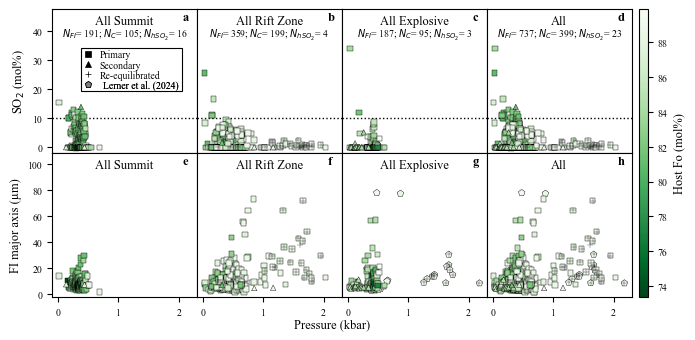

In [531]:
datasets = [all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Explosive"))],
            all_data_simplified,
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Explosive"))],
            all_data_simplified,
            ]

titles = ["All Summit",
          "All Rift Zone",
          "All Explosive",
          "All",
          "All Summit",
          "All Rift Zone",
          "All Explosive",
          "All",
          ]

# group axes that should share x (same integer = shared axis group)

######
MM_PER_INCH=25.4
REF_WIDTH_MM  = 190
ROW_HEIGHT_MM = REF_WIDTH_MM/2

FIG_WIDTH_MM  = REF_WIDTH_MM
FIG_HEIGHT_MM = ROW_HEIGHT_MM

fontsize_small=7
fontsize_large=9

s_small=15
s_large=25
s_stars=40
linewidth_markers=0.3
#####
num_axes = len(datasets)

MAX_COLS = 4
num_cols = min(MAX_COLS, num_axes)
num_rows = int(np.ceil(num_axes / num_cols))

y_vars = [ 'SO2 mol%', 'SO2 mol%', 'SO2 mol%', 'SO2 mol%', 'FI_semiaxis_a_um', 'FI_semiaxis_a_um', 'FI_semiaxis_a_um', 'FI_semiaxis_a_um', ]

y_share_groups = [ 0, 0, 0, 0, 1, 1, 1, 1, ]

y_limits = {}

for yvar in set(y_vars):
    y = all_data_simplified[yvar].dropna()
    
    ymin = y.min()
    ymax = y.max()
    yrange = ymax - ymin
    
    pad_low  = 0.05 * yrange   
    pad_high = 0.40 * yrange   
    
    y_limits[yvar] = [ymin - pad_low, ymax + pad_high]


### Color by variable
colorvar='Fo_Ol_%'
palette='Greens_r'
global_min = np.nanmin(all_data_simplified[colorvar])
global_max = np.nanmax(all_data_simplified[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

fig, axes = plt.subplots( num_rows, num_cols, figsize=( FIG_WIDTH_MM  / MM_PER_INCH, FIG_HEIGHT_MM / MM_PER_INCH ), sharey=False, sharex=True )

axes = np.atleast_1d(axes).flatten()

for i, (ax, data, title,yvar) in enumerate(zip(axes, datasets, titles,y_vars)):
    
    prims= (data['FI_type'] != 'S') # excudes S
    reeq=data['decrepit'].str.contains('y', na=False)#data['Comment'].str.contains('reeq|re=eq|re-eq|req|decrep', na=False)
    so2=~(data[ yvar] >= SO2_cutoff)
    lerner_weird = data['Fluid inclusion notes'].str.contains("Two-phase", na=False)
    lerner = data['Eruption_title'].str.contains("Keana", na=False)
    base_filters_tmp=(so2)&(prims)&~(lerner_weird)
    is_secondary = ~prims

    # mask = ~pd.isna(data['SingleCalc_P_kbar'])
    # ax.errorbar(x=data.loc[mask, 'SingleCalc_P_kbar'],y=data.loc[mask,  yvar],xerr=data.loc[mask, 'std_dev_MC_P_kbar'],
    #             mec='none', mfc='none', fmt='s', capsize=3, ecolor='k', zorder=-1, elinewidth=0.4, capthick=0.4)
    
    # ---------- PRIMARY, NOT REEQ ----------
    ax.scatter( data.loc[prims &  ~(lerner),'SingleCalc_P_kbar'], data.loc[  prims &  ~(lerner),  yvar], 
                c=data.loc[  prims &  ~(lerner), colorvar], cmap=palette, norm=norm, marker='s', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=4 )
    ax.scatter( data.loc[lerner,'SingleCalc_P_kbar'], data.loc[lerner,  yvar], 
               c=data.loc[ lerner, colorvar], marker='p', cmap=palette, norm=norm, edgecolor='k', linewidths=linewidth_markers, s=s_large, zorder=2 )
    # ---------- REEQUILIBRATED ----------
    ax.scatter( data.loc[reeq|lerner_weird,'SingleCalc_P_kbar'], data.loc[reeq|lerner_weird,  yvar], marker='+', color='k', linewidths=linewidth_markers-0.1, s=s_small, zorder=5 )
    # ---------- SECONDARY ----------
    ax.scatter( data.loc[~prims,'SingleCalc_P_kbar'], data.loc[  ~prims  ,  yvar], c=data.loc[  ~prims  , colorvar], cmap=palette, norm=norm, marker='^', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=5 )
    ylim = y_limits[yvar]
    ax.set_ylim(ylim)
    xlim=[-0.1,2.3]
    if yvar == 'SO2 mol%':
        ax.plot(xlim, [10, 10], color='k', linestyle=":", linewidth=1)

    # Set axis limits
    ax.set_ylim(ylim)  # Inverted y-axis
    ax.set_xlim(xlim)  
    #Offset x labels 
    labels = ax.get_xticklabels()
    labels = ax.get_xticklabels()
    col = i % num_cols

    # rightmost tick of a row
    if col < num_cols - 1 and labels:
        x, y = labels[-1].get_position()
        labels[-1].set_horizontalalignment('right')
        labels[-1].set_x(x - 0.04)

    # leftmost tick of a row
    if col > 0 and labels:
        x, y = labels[0].get_position()
        labels[0].set_horizontalalignment('left')
        labels[0].set_x(x + 0.04)

    if i % num_cols == 0:
        if yvar=='SO2 mol%':
            ax.set_ylabel(f'SO${{_2}}$ (mol%)', fontsize=fontsize_large)
        else:
            ax.set_ylabel("FI major axis (µm)", fontsize=fontsize_large)
    else:
        # only hide if sharing y with left neighbor
        if y_share_groups[i] == y_share_groups[i - 1]:
            ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= (num_rows - 1) * num_cols))
    
    ### Title annotations and NFI
    x1 = 0.5

    if "\n" in title:
        y1 = 0.92
        y2 = y1 - 0.135
    else:
        y1 = 0.92
        y2 = y1 - 0.1
    
    ax.annotate( title, xy=(x1, y1), xycoords="axes fraction", fontsize=fontsize_large, ha="center", va="center", color="k" )    
    if yvar == 'SO2 mol%':
        ax.annotate( f"$N_{{FI}}$= {len(data)}; $N_C$= {len(data['Sample_crystal'].unique())}; $N_{{hSO{{_2}}}}$= {len(data[data[ yvar]>=10])}", xy=(x1, y2), xycoords="axes fraction", fontsize=fontsize_small, ha="center", va="center", color="k" )
        # ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(x1+0.32, y2), xycoords='axes fraction', 
        #             fontsize=fontsize-2, ha='center', va='center', color='k')
    #####
    import string
    panel_label = string.ascii_lowercase[i]
    ax.text(0.9, 0.98, panel_label, transform=ax.transAxes, fontsize=fontsize_large, fontweight='bold', va='top', ha='left' )
    
# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ---- apply hybrid sharey ----
group_to_axes = {}

for i, ax in enumerate(axes[:len(datasets)]):
    g = y_share_groups[i]
    
    if g not in group_to_axes:
        group_to_axes[g] = ax  # reference axis
    else:
        ax.sharey(group_to_axes[g])


############## Composite legend ################
axA = axes[0]
Lx = 0.15    # left–right position (axes fraction) 0.15
Ly = 0.90    # up–down position   (axes fraction) 0.35

mew_legend=0.5 # Adjusts the edge thickness of the legend markers
msize=5
######### Primary FI#####
prim_handle = [mpl.lines.Line2D([0], [0],  marker='s', linestyle='None', markerfacecolor=plt.cm.magma(norm(0.6)),mew=mew_legend, markeredgecolor='k', markersize=msize,label='Primary')]
leg_prim = axA.legend( handles=prim_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.12), frameon=False, fontsize=fontsize_small, handletextpad=0.2, )
axA.add_artist(leg_prim)
######### Secondary FI#####
sec_handle = [mpl.lines.Line2D([0], [0], marker='^', linestyle='None', markerfacecolor=plt.cm.magma(norm(0.6)), markeredgecolor='k', markersize=msize,mew=mew_legend, label='Secondary')]
leg_sec = axA.legend( handles=sec_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.19), frameon=False, fontsize=fontsize_small, handletextpad=0.2, )
axA.add_artist(leg_sec)
######### Reeq FI#####
reeq_handle = [mpl.lines.Line2D([0], [0], marker='+', linestyle='None', color='k', markersize=msize,mew=mew_legend, label='Re-equilibrated')]
leg_reeq = axA.legend( handles=reeq_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.26), frameon=False, fontsize=fontsize_small, handletextpad=0.2, )
axA.add_artist(leg_reeq)
# ######### Lerner FI#####
lerner_handle = [ mpl.lines.Line2D([0], [0], marker='p', linestyle='None', markerfacecolor='grey', markeredgecolor='k', markersize=msize, mew=mew_legend, label='Lerner et al. (2024)') ]
leg_lerner = axA.legend( handles=lerner_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.33), frameon=False, fontsize=fontsize_small, handletextpad=0.6, )
axA.add_artist(leg_lerner)

######### Box###########

# Dimensions of the legend block (tweak once)
legend_width  = 0.7
legend_height = 0.3

legend_box = mpl.patches.Rectangle( (Lx + 0.05, Ly - legend_height- 0.17), legend_width, legend_height, 
                                   transform=axA.transAxes, facecolor='none', edgecolor='k', linewidth=0.8, zorder=10 )

axA.add_patch(legend_box)
################################################
#############COLORBAR###########################
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
bboxes = [ax.get_position() for ax in axes[:len(datasets)]]
bbox = mpl.transforms.Bbox.union(bboxes)
cax = fig.add_axes([ bbox.x1 + 0.01, bbox.y0, 0.012, bbox.height ])
cbar = fig.colorbar( sm, cax=cax, orientation="vertical" )
cbar.set_label("Host Fo (mol%)", fontsize=fontsize_large)
cbar.ax.tick_params(labelsize=fontsize_small)
################################################
# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)

# Add x-axis label only on the bottom row
fig.text(0.5, 0.03, 'Pressure (kbar)', ha='center', fontsize=fontsize_large)

# Save figure
fig.savefig(figpath + slash + 'FigS1_P_radii_SO2.pdf', format='pdf', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)
fig.savefig(figpath + slash + 'FigS1_P_radii_SO2.png', format='png', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)

plt.show()

### K. Plot Fig S2. FI size vs P all

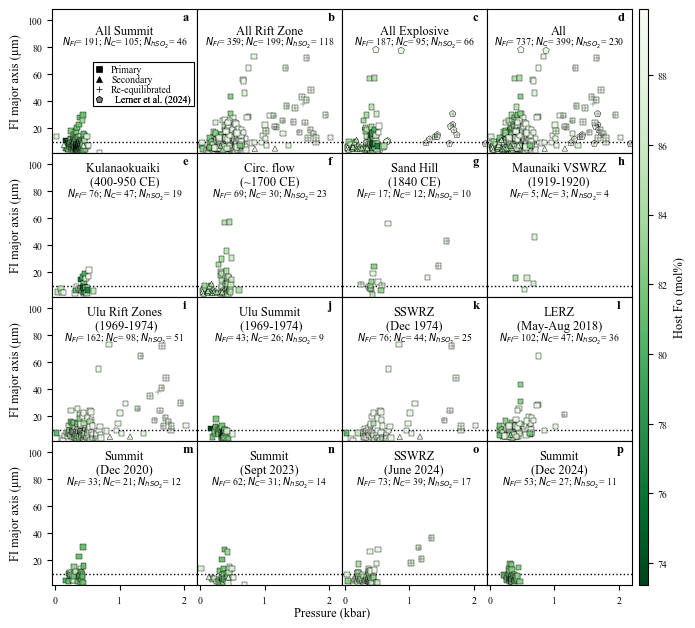

In [532]:
datasets = [all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ"))],
            all_data_simplified[(all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Explosive"))],
            all_data_simplified,
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Kulana"))],

            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Circ."))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Sand"))],
            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("Maunaiki"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains('908|909|910|931|919|920'))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains('914|916|917|924'))],

            all_data_simplified[(all_data_simplified['Sample'].str.contains('919|920'))],

            all_data_simplified[(all_data_simplified['Eruption_title'].str.contains("LERZ"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K20"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K23"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("K24"))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains("KD24"))],

            ]

titles = ["All Summit",
          "All Rift Zone",
          "All Explosive",
          "All",
          "Kulanaokuaiki \n(400-950 CE)", 

          "Circ. flow\n(~1700 CE)",
          "Sand Hill\n(1840 CE)", 
          "Maunaiki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",

          "SSWRZ\n(Dec 1974)",

          "LERZ\n(May-Aug 2018)", 
          "Summit\n(Dec 2020)", 
          "Summit\n(Sept 2023)", 
          "SSWRZ\n(June 2024)", 
          "Summit\n(Dec 2024)",

          ]
######
REF_WIDTH_MM  = 190
ROW_HEIGHT_MM = REF_WIDTH_MM

FIG_WIDTH_MM  = REF_WIDTH_MM
FIG_HEIGHT_MM = ROW_HEIGHT_MM

fontsize_small=7
fontsize_large=9

s_small=15
s_large=25
s_stars=40
linewidth_markers=0.3
#####
num_axes = len(datasets)

MAX_COLS = 4
num_cols = min(MAX_COLS, num_axes)
num_rows = int(np.ceil(num_axes / num_cols))

plot_var= 'FI_semiaxis_a_um'
# Generate colors using a seaborn color palette

### Color by variable
colorvar='Fo_Ol_%'
palette='Greens_r'
global_min = np.nanmin(all_data_simplified[colorvar])
global_max = np.nanmax(all_data_simplified[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)
y_max=np.nanmax(all_data_simplified[ plot_var])
y_min=np.nanmin(all_data_simplified[ plot_var])

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

fig, axes = plt.subplots( num_rows, num_cols, figsize=( FIG_WIDTH_MM  / MM_PER_INCH, FIG_HEIGHT_MM / MM_PER_INCH ), sharey=True, sharex=True )

axes = np.atleast_1d(axes).flatten()

# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    prims= (data['FI_type'] != 'S') # excudes S
    reeq=data['decrepit'].str.contains('y', na=False)#data['Comment'].str.contains('reeq|re=eq|re-eq|req|decrep', na=False)
    so2=~(data[ plot_var] >= SO2_cutoff)
    lerner_weird = data['Fluid inclusion notes'].str.contains("Two-phase", na=False)
    lerner = data['Eruption_title'].str.contains("Keana", na=False)
    base_filters_tmp=(so2)&(prims)&~(lerner_weird)
    is_secondary = ~prims

    # mask = ~pd.isna(data['SingleCalc_P_kbar'])
    # ax.errorbar(x=data.loc[mask, 'SingleCalc_P_kbar'],y=data.loc[mask,  plot_var],xerr=data.loc[mask, 'std_dev_MC_P_kbar'],
    #             mec='none', mfc='none', fmt='s', capsize=3, ecolor='k', zorder=-1, elinewidth=0.4, capthick=0.4)
    
    # ---------- PRIMARY, NOT REEQ ----------
    ax.scatter( data.loc[prims &  ~(lerner),'SingleCalc_P_kbar'], data.loc[  prims &  ~(lerner),  plot_var], 
                c=data.loc[  prims &  ~(lerner), colorvar], cmap=palette, norm=norm, marker='s', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=4 )
    ax.scatter( data.loc[lerner,'SingleCalc_P_kbar'], data.loc[lerner,  plot_var], 
               c=data.loc[ lerner, colorvar], marker='p', cmap=palette, norm=norm, edgecolor='k', linewidths=linewidth_markers, s=s_large, zorder=2 )
    # ---------- REEQUILIBRATED ----------
    ax.scatter( data.loc[reeq|lerner_weird,'SingleCalc_P_kbar'], data.loc[reeq|lerner_weird,  plot_var], marker='+', color='k', linewidths=linewidth_markers-0.1, s=s_small, zorder=5 )
    # ---------- SECONDARY ----------
    ax.scatter( data.loc[~prims,'SingleCalc_P_kbar'], data.loc[  ~prims  ,  plot_var], c=data.loc[  ~prims  , colorvar], cmap=palette, norm=norm, marker='^', edgecolors='k', linewidths=linewidth_markers, s=s_small, zorder=5 )
    ylim=[y_min-0.05,y_max+30]
    xlim=[-0.05,2.2]
    ax.plot(xlim,[10,10],color='k',linestyle=":",linewidth=1)
    # Set axis limits
    ax.set_ylim(ylim)  # Inverted y-axis
    ax.set_xlim(xlim)  
    #Offset x labels 
    labels = ax.get_xticklabels()
    labels = ax.get_xticklabels()
    col = i % num_cols

    # rightmost tick of a row
    if col < num_cols - 1 and labels:
        x, y = labels[-1].get_position()
        labels[-1].set_horizontalalignment('right')
        labels[-1].set_x(x - 0.04)

    # leftmost tick of a row
    if col > 0 and labels:
        x, y = labels[0].get_position()
        labels[0].set_horizontalalignment('left')
        labels[0].set_x(x + 0.04)

    if i % num_cols == 0:
        ax.set_ylabel("FI major axis (µm)",fontsize=fontsize_large)
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= (num_rows - 1) * num_cols))
    
    ### Title annotations and NFI
    x1 = 0.5

    if "\n" in title:
        y1 = 0.85
        y2 = y1 - 0.135
    else:
        y1 = 0.85
        y2 = y1 - 0.08

    ax.annotate( title, xy=(x1, y1), xycoords="axes fraction", fontsize=fontsize_large, ha="center", va="center", color="k" )
    ax.annotate( f"$N_{{FI}}$= {len(data)}; $N_C$= {len(data['Sample_crystal'].unique())}; $N_{{hSO{{_2}}}}$= {len(data[data[ plot_var]>=10])}", xy=(x1, y2), xycoords="axes fraction", fontsize=fontsize_small, ha="center", va="center", color="k" )
    # ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(x1+0.32, y2), xycoords='axes fraction', 
    #             fontsize=fontsize-2, ha='center', va='center', color='k')
    #####
    import string
    panel_label = string.ascii_lowercase[i]
    ax.text(0.9, 0.98, panel_label, transform=ax.transAxes, fontsize=fontsize_large, fontweight='bold', va='top', ha='left' )
    
# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])



############## Composite legend ################
axA = axes[0]
Lx = 0.23    # left–right position (axes fraction) 0.15
Ly = 0.80    # up–down position   (axes fraction) 0.35

mew_legend=0.5 # Adjusts the edge thickness of the legend markers
msize=5
######### Primary FI#####
prim_handle = [mpl.lines.Line2D([0], [0],  marker='s', linestyle='None', markerfacecolor=plt.cm.magma(norm(0.6)),mew=mew_legend, markeredgecolor='k', markersize=msize,label='Primary')]
leg_prim = axA.legend( handles=prim_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.12), frameon=False, fontsize=fontsize_small, handletextpad=0.2, )
axA.add_artist(leg_prim)
######### Secondary FI#####
sec_handle = [mpl.lines.Line2D([0], [0], marker='^', linestyle='None', markerfacecolor=plt.cm.magma(norm(0.6)), markeredgecolor='k', markersize=msize,mew=mew_legend, label='Secondary')]
leg_sec = axA.legend( handles=sec_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.19), frameon=False, fontsize=fontsize_small, handletextpad=0.2, )
axA.add_artist(leg_sec)
######### Reeq FI#####
reeq_handle = [mpl.lines.Line2D([0], [0], marker='+', linestyle='None', color='k', markersize=msize,mew=mew_legend, label='Re-equilibrated')]
leg_reeq = axA.legend( handles=reeq_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.26), frameon=False, fontsize=fontsize_small, handletextpad=0.2, )
axA.add_artist(leg_reeq)
# ######### Lerner FI#####
lerner_handle = [ mpl.lines.Line2D([0], [0], marker='p', linestyle='None', markerfacecolor='grey', markeredgecolor='k', markersize=msize, mew=mew_legend, label='Lerner et al. (2024)') ]
leg_lerner = axA.legend( handles=lerner_handle, loc='upper left', bbox_to_anchor=(Lx - 0.03, Ly - 0.33), frameon=False, fontsize=fontsize_small, handletextpad=0.6, )
axA.add_artist(leg_lerner)

######### Box###########

# Dimensions of the legend block (tweak once)
legend_width  = 0.7
legend_height = 0.3

legend_box = mpl.patches.Rectangle( (Lx + 0.05, Ly - legend_height- 0.17), legend_width, legend_height, 
                                   transform=axA.transAxes, facecolor='none', edgecolor='k', linewidth=0.8, zorder=10 )

axA.add_patch(legend_box)
################################################
#############COLORBAR###########################
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
bboxes = [ax.get_position() for ax in axes[:len(datasets)]]
bbox = mpl.transforms.Bbox.union(bboxes)
cax = fig.add_axes([ bbox.x1 + 0.01, bbox.y0, 0.012, bbox.height ])
cbar = fig.colorbar( sm, cax=cax, orientation="vertical" )
cbar.set_label("Host Fo (mol%)", fontsize=fontsize_large)
cbar.ax.tick_params(labelsize=fontsize_small)
################################################
# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)

# Add x-axis label only on the bottom row
fig.text(0.5, 0.07, 'Pressure (kbar)', ha='center', fontsize=fontsize_large)

# Save figure
fig.savefig(figpath + slash + 'Fig_S2_P_radii_all.pdf', format='pdf', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)
fig.savefig(figpath + slash + 'FigS2_P_radii_all.png', format='png', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)

plt.show()

### L. Plot Fig S3 intracrystal variability

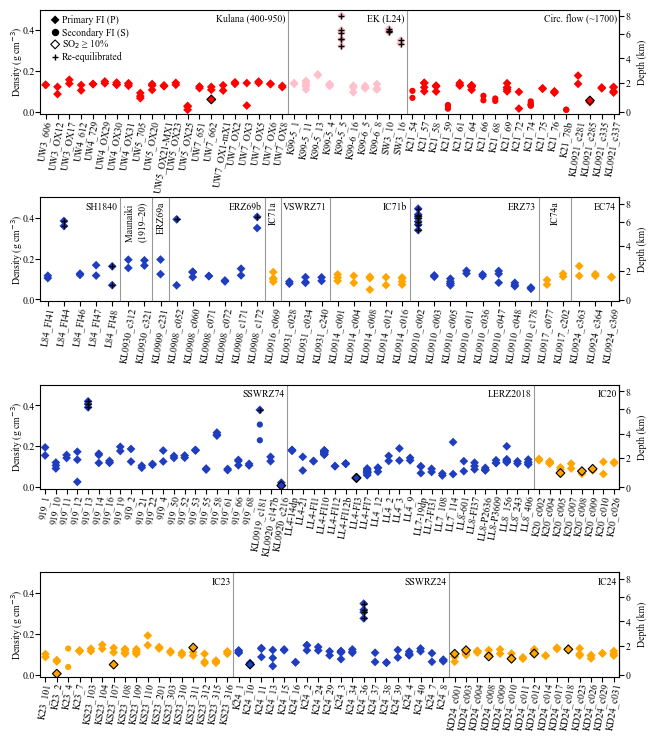

In [533]:
from scipy.interpolate import interp1d

########### SET ERUPTION CHRONOLOGY ##################

eruption_meta = {
    r"UW":   {"short": "Kulana (400-950)",   "long": "Kulanaokuaiki\n(400–950)"},
    r"K99|SW": {"short": "EK (L24)", "long": "Early Keanakākoʻi\n(1500–1650)"},
    r"K21|921": {"short": "Circ. flow (~1700)", "long": "Circ. flow\n(~1700)"},
    r"L84": {"short": "SH1840", "long": "Sand Hill\n(1840)"},
    r"930": {"short": "Maunaiki \n(1919–20)", "long": "Maunaiki VSWRZ\n(1919–1920)"},
    r"909": {"short": "ERZ69a", "long": "ERZ (May 1969)"},
    r"908": {"short": "ERZ69b", "long": "ERZ (Dec 1969)"},
    r"916": {"short": "IC71a", "long": "IC (Aug 1971)"},
    r"931": {"short": "VSWRZ71", "long": "VSWRZ\n(Sep 1971)"},
    r"914": {"short": "IC71b", "long": "IC\n(Sep 1971)"},
    r"910": {"short": "ERZ73", "long": "ERZ (Nov 1973)"},
    r"917": {"short": "IC74a", "long": "IC\n(Jul 1974)"},
    r"924": {"short": "EC74", "long": "EC\n(Jul 1974)"},
    r"919|920": {"short": "SSWRZ74", "long": "SSWRZ\n(Dec 1974)"},
    r"LL": {"short": "LERZ2018", "long": "LERZ\n(May–Aug 2018)"},
    r"K20": {"short": "IC20", "long": "IC\n(Dec 2020)"},
    r"K23": {"short": "IC23", "long": "IC\n(Sept 2023)"},
    r"K24": {"short": "SSWRZ24", "long": "SSWRZ\n(June 2024)"},
    r"KD24": {"short": "IC24", "long": "IC\n(Dec 2024)"},
}

LABEL_MODE = "short"
# options: "auto", "long", "short"

marker_size_large=20
marker_size_small=20
eruption_patterns = list(eruption_meta.keys())
eruption_labels = [meta["long"] for meta in eruption_meta.values()]

fi_counts = ( all_data_simplified .groupby("Sample_crystal")["FI_name"] .nunique() )
df = all_data_simplified.loc[ all_data_simplified["Sample_crystal"].isin(fi_counts[fi_counts > 1].index) ].copy()

df["eruption_index"] = np.nan
for i, pat in enumerate(eruption_patterns):
    mask = df["Sample"].astype(str).str.contains(pat, regex=True)
    df.loc[mask, "eruption_index"] = i

df = df.dropna(subset=["eruption_index"])
df["eruption_index"] = df["eruption_index"].astype(int)

eruption_table = []

for i in range(len(eruption_meta)):
    crystals = sorted(df[df["eruption_index"] == i]["Sample_crystal"].unique() )
    eruption_table.append({"eruption_index": i, "label": eruption_labels[i], "n_crystals": len(crystals), })

eruption_table = pd.DataFrame(eruption_table)

total = eruption_table["n_crystals"].sum()
targets = [total * k / 4 for k in (1, 2, 3)]

cumulative = eruption_table["n_crystals"].cumsum()
split_indices = [(cumulative - t).abs().idxmin() for t in targets ]

panel_bounds = [(0, split_indices[0]),
    (split_indices[0] + 1, split_indices[1]),
    (split_indices[1] + 1, split_indices[2]),
    (split_indices[2] + 1, len(eruption_table) - 1)]

panel_eruptions = [eruption_table.loc[a:b, "eruption_index"].tolist() for a, b in panel_bounds ]

######################################################
########### SET FIGURE PARAMETERS ####################
inch = 25.4
fig = plt.figure(figsize=(190 / inch, 220 / inch))
gs = mpl.gridspec.GridSpec(4, 1, height_ratios=[3, 3, 3, 3], hspace=0.8)

axes = [fig.add_subplot(gs[i, 0]) for i in range(4)]

## Density-Depth mapping for secondary axis
all_dens = df["Density g/cm3"].values
all_depth = df["SingleCalc_D_km"].values
mask = np.isfinite(all_dens) & np.isfinite(all_depth)
all_dens = all_dens[mask]
all_depth = all_depth[mask]
order = np.argsort(all_dens)
all_dens = all_dens[order]
all_depth = all_depth[order]
dens_to_depth = interp1d( all_dens, all_depth, bounds_error=False, fill_value="extrapolate" )
depth_to_dens = interp1d( all_depth, all_dens, bounds_error=False, fill_value="extrapolate" )

######################################################
########### PLOT THINGS ##############################
for ax, eruption_indices in zip(axes, panel_eruptions):

    d = df[df["eruption_index"].isin(eruption_indices)].copy()

    ordered_parts = []
    eruption_spans = []
    x_cursor = 0

    for i in eruption_indices:
        part = (d[d["eruption_index"] == i] .sort_values("Sample_crystal") )
        crystals = part["Sample_crystal"].unique()

        if len(crystals) == 0:
            continue

        ordered_parts.append(part)

        x0 = x_cursor
        x1 = x_cursor + len(crystals) - 1
        eruption_spans.append({
            "x0": x0,
            "x1": x1,
            "i": i
        })

        x_cursor += len(crystals)

    d_ordered = pd.concat(ordered_parts, ignore_index=True)

    for crystal, g in d_ordered.groupby("Sample_crystal", sort=False):

        x = np.full(len(g), crystal)
        y = g["Density g/cm3"]

        prim = g["FI_type"] != "S"
        so2  = g["SO2 mol%"] >= SO2_cutoff
        reeq = g["decrepit"].str.contains("y", na=False) | \
            g["Fluid inclusion notes"].str.contains("Two-phase", na=False)

        # Primary FIs
        ax.scatter( x[prim], y[prim], marker="D", s=marker_size_small, alpha=1, facecolor=get_violin_color(g), edgecolor="none", zorder=3)
        ax.scatter( x[prim & so2], y[prim & so2], marker="D", s=marker_size_small, facecolor='none', edgecolor="black", linewidth=0.8, zorder=4)
        # Secondary FIs
        ax.scatter( x[~prim], y[~prim], marker="o", s=marker_size_small, facecolor=get_violin_color(g), edgecolor="none", linewidth=0.6, zorder=3)
        ax.scatter( x[~prim & so2], y[~prim & so2], marker="o", s=marker_size_small, facecolor='none', edgecolor="black", linewidth=0.6, zorder=3)
        # Re-equilibrated / weird
        ax.scatter( x[reeq], y[reeq], marker="+", s=marker_size_small, color="black", linewidths=1.0, zorder=5)

    n = d_ordered["Sample_crystal"].nunique()
    ax.set_xlim(-0.5, n - 0.5)
    ax.margins(x=0)
    ax.set_ylim(-0.01, 0.5)

    secax = ax.secondary_yaxis( "right", functions=(dens_to_depth, depth_to_dens) )
    secax.set_ylabel("Depth (km)", fontsize=7)
    secax.tick_params(axis="y", labelsize=7, direction="out", pad=1)

    ax.tick_params(axis="x", rotation=80, labelsize=7, pad=0.5)
    ax.tick_params(axis="y", direction="out", labelsize=7, pad=0)
    ax.set_ylabel("Density (g cm$^{-3}$)", fontsize=7, labelpad=-2)

    for j in range(1, len(eruption_spans)):
        ax.axvline(eruption_spans[j]["x0"] - 0.5, color="0.6", lw=0.8)
    MIN_SPAN_FOR_LONG = 4   # crystals
    MIN_SPAN_FOR_HORIZ = 3 # crystals

    for span in eruption_spans:
        x0, x1 = span["x0"], span["x1"]
        i = span["i"]
        width = x1 - x0 + 1

        meta = eruption_meta[eruption_patterns[i]]

        if LABEL_MODE == "long":
            label = meta["long"]
            rotation = 0

        elif LABEL_MODE == "short":
            label = meta["short"]
            rotation = 90 if width < MIN_SPAN_FOR_HORIZ else 0

        else:
            if width >= MIN_SPAN_FOR_LONG:
                label = meta["long"]
                rotation = 0
            else:
                label = meta["short"]
                rotation = 90 if width < MIN_SPAN_FOR_HORIZ else 0

        if rotation == 90:
            x = (x0 + x1) / 2
            ha = "center"
            y = 0.48
            va = "top"

        else:
            # x = x0 - 0.15
            # ha = "left"
            x = x1 +0.3
            ha = "right"
            y = 0.48
            va = "top"

        ax.text( x, y, label, ha=ha, va=va, fontsize=7, rotation=rotation, clip_on=True )

    if ax is axes[0] and len(eruption_spans) > 0:

        span0 = eruption_spans[0]
        x0, x1 = span0["x0"], span0["x1"]
        lx = x0 + 0.8
        y1 = 0.45
        dy = 0.06
        ys = [y1, y1 - dy, y1 - 2*dy, y1 - 3*dy]

        labels = [ "Primary FI (P)", "Secondary FI (S)", r"SO$_2$ ≥ 10%", "Re-equilibrated"]

        ax.scatter(lx, ys[0], marker='D', s=marker_size_small, facecolor='k', edgecolor='none', zorder=10)
        ax.scatter(lx, ys[1], marker='o', s=marker_size_small, facecolor='k', edgecolor='black', linewidth=0.8, zorder=10)
        ax.scatter(lx, ys[2], marker='D', s=marker_size_small, facecolor='none', edgecolor='black', linewidth=0.8, zorder=10)
        ax.scatter(lx, ys[3], marker='+', s=marker_size_small, color='black', linewidths=1, zorder=10)

        for y, lab in zip(ys, labels):
            ax.text( lx + 0.55, y, lab, ha='left', va='center', fontsize=7, zorder=10 )

fig.savefig(figpath + slash + 'FigS3_intracrystalvar.pdf', format='pdf', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)
fig.savefig(figpath + slash + 'FigS3_intracrystalvar.png', format='png', dpi=300, transparent=False, bbox_inches='tight', pad_inches=0.01)

plt.show()


In [534]:
## Settling rates for average kilauea magma compositon at 0.2 wt% H2O

low_visc=10**0.83 #1315 C
high_visc=10**2.1 # 1115 C
g=9.80
r_small=500/10**6
r_large=2000/10**6
rho_crystal=3300
rho_liq=2700

r=r_small
def settle_rate(visc,g,r,rho_crystal,rho_liq):
    return (2/9)*(g*r**2*(rho_crystal-rho_liq))/visc

small_r_low_visc=settle_rate(visc=low_visc,g=g,r=r_small,rho_crystal=rho_crystal,rho_liq=rho_liq)
small_r_high_visc=settle_rate(visc=high_visc,g=g,r=r_small,rho_crystal=rho_crystal,rho_liq=rho_liq)
large_r_low_visc=settle_rate(visc=low_visc,g=g,r=r_large,rho_crystal=rho_crystal,rho_liq=rho_liq)
large_r_high_visc=settle_rate(visc=high_visc,g=g,r=r_large,rho_crystal=rho_crystal,rho_liq=rho_liq)

print(small_r_low_visc)
print(small_r_high_visc)
print(large_r_low_visc)
print(large_r_high_visc)
large_r_low_visc*60*60*24

print(((2000/small_r_high_visc)/(60*60*24*365)))
print(((2000/large_r_low_visc)/(60*60*24)))

4.831754068016145e-05
2.5948055667659856e-06
0.0007730806508825832
4.151688906825577e-05
24.440977304735647
29.942733816609167


#### Figure for Kendra - Kulana split

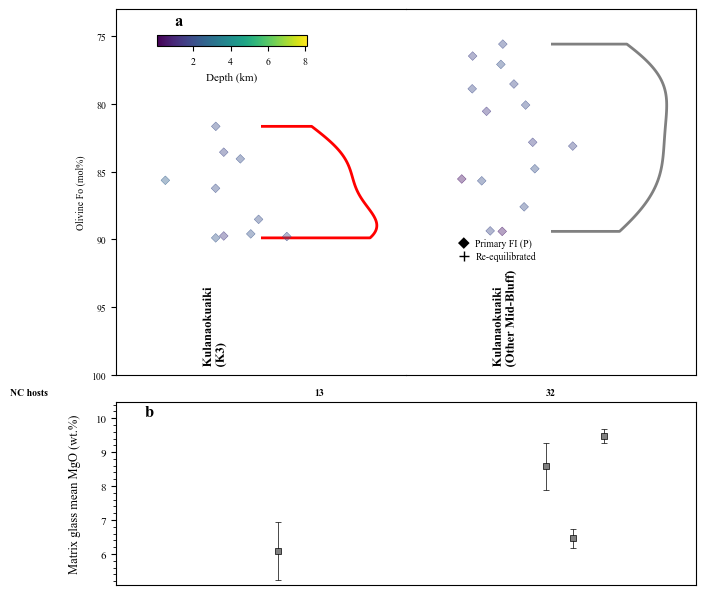

In [535]:

K3=all_data_simplified[(all_data_simplified['Sample'].str.contains('UW7'))].copy()
Kulana_not_K3=all_data_simplified[(all_data_simplified['Sample'].str.contains('UW3|UW4|UW5'))].copy()


deepest_FI_only=True ## whether all FI are plotted or only max in each crystal (avoid duplicate olivine compos)

datasets = [all_data_simplified[(all_data_simplified['Sample'].str.contains('UW7'))],
            all_data_simplified[(all_data_simplified['Sample'].str.contains('UW3|UW4|UW5'))],
            ]

titles = ["Kulanaokuaiki \n(K3)", 
          "Kulanaokuaiki\n(Other Mid-Bluff)",

          ]

num_axes = len(datasets)

ylims=(100,73)
xlims=(-0.5,0.5)

plot_var='Fo_Ol_%'
mgo_color = "grey"
#################Scatter style ################################
scatter_style = "color"   # "fixed", "color", "size"
dcol = "SingleCalc_D_km"
cmap_varcolor = "viridis"
use_local_norm = False
set_color_max='none' #'none' if you want to use the global maximum in data


if scatter_style in ("color", "size") and dcol in all_data_simplified.columns:
    global_vmin = all_data_simplified.loc[
        all_data_simplified[dcol].notna(), dcol
    ].min()
    if set_color_max!='none':
        global_vmax=set_color_max
    else:
        global_vmax = all_data_simplified.loc[
            all_data_simplified[dcol].notna(), dcol
        ].max()

###############################################################

inch=25.4

fig = plt.figure(figsize=(190/inch, 190/inch))
gs = mpl.gridspec.GridSpec(
    nrows=2,
    ncols=num_axes,
    height_ratios=[3,1.5],
    hspace=0.1,
    wspace=0
)

axes = [fig.add_subplot(gs[0, i]) for i in range(num_axes)]

# bottom row panels (b–e placeholders)
n_bottom = 1
cols_per_panel = num_axes // n_bottom
bottom_axes = []
for i in range(n_bottom):
    start = i * cols_per_panel
    end = (i + 1) * cols_per_panel
    ax = fig.add_subplot(gs[1, start:end])
    bottom_axes.append(ax)
ax_b = bottom_axes[0]

###### bottom panel

ax_b.set_xlim(-0.5, num_axes - 0.5)

ax_b.yaxis.set_label_position("left")
ax_b.yaxis.tick_left()
ax_b.tick_params(axis='y', colors="k", labelsize=8)
ax_b.minorticks_on()
ax_b.set_xticks([])

ax_b.set_ylabel(
    "Matrix glass mean MgO (wt.%)",
    fontsize=9,
    rotation=90,
    labelpad=10,
    color="k"
)

np.random.seed(42)

exclude_mgo_idxs = {num_axes - 4,num_axes - 3, num_axes - 2, num_axes - 1}

mgo_x = []
mgo_y = []
mgo_yerr = []
mgo_line_x = []
mgo_line_y = []

for i, data_all in enumerate(datasets):

    # if i in exclude_mgo_idxs:
    #     continue

    needed = {'Sample', 'MgO_Gl', 'MgO_STD_Gl'}
    if not needed.issubset(data_all.columns):
        continue

    mask = data_all['MgO_Gl'].notna() & data_all['MgO_STD_Gl'].notna()

    df_mgo = (
        data_all.loc[mask, ['Sample', 'MgO_Gl', 'MgO_STD_Gl']]
        .drop_duplicates(subset='Sample')
    )

    if df_mgo.empty:
        continue

    vals = df_mgo['MgO_Gl'].astype(float).values
    errs = df_mgo['MgO_STD_Gl'].astype(float).values

    # horizontal jitter per panel
    x_mgo = i + np.random.normal(0, 0.12, len(vals))

    mgo_x.extend(x_mgo)
    mgo_y.extend(vals)
    mgo_yerr.extend(errs)

    if i not in exclude_mgo_idxs:
        mgo_line_x.append(i)
        mgo_line_y.append(vals.mean())

mgo_x = np.asarray(mgo_x)
mgo_y = np.asarray(mgo_y)
mgo_yerr = np.asarray(mgo_yerr)
mgo_line_x = np.asarray(mgo_line_x)
mgo_line_y = np.asarray(mgo_line_y)


ax_b.set_xlim(-0.5, num_axes - 0.5)

ax_b.errorbar( mgo_x, mgo_y, yerr=mgo_yerr, fmt='s', markersize=4, markerfacecolor=mgo_color, markeredgecolor='k', markeredgewidth=0.5, ecolor='k', elinewidth=0.5, capsize=2, zorder=5 )

order = np.argsort(mgo_line_x)
ax_b.plot( mgo_line_x[order], mgo_line_y[order], color=mgo_color, linestyle="-.", lw=2.0, zorder=4 )
#######

for i, (ax, data_all_raw, title) in enumerate(zip(axes, datasets, titles)):

    # Color logic
    if i == num_axes - 1:
        violin_color = "grey"
    else:
        violin_color = get_violin_color(data_all_raw)

    if deepest_FI_only==True:
        # Collapse to one representative FI per crystal (deepest)
        if dcol in data_all_raw.columns:
            df = data_all_raw.copy()
            valid_mask = ( (df['FI_type'] != 'S') & (df['SO2 mol%'] < SO2_cutoff) )
            idx = df.groupby("Sample_crystal").apply(
                lambda g: (
                    g.loc[valid_mask.loc[g.index], dcol].idxmax()
                    if valid_mask.loc[g.index].any()
                    else g[dcol].idxmax() if g[dcol].notna().any()
                    else g.index[0]
                ),
                include_groups=False
            )
            data_all = df.loc[idx].sort_index()

    else:
        data_all = data_all_raw.copy()

    prim_tmp = data_all['FI_type'] != 'S'
    so2_tmp = ~(data_all['SO2 mol%'] >= SO2_cutoff)
    reeq_tmp = data_all['decrepit'].str.contains('y', na=False)
    lerner_weird_tmp = data_all['Fluid inclusion notes'].str.contains("Two-phase", na=False)
    base_filters_tmp=(so2_tmp)&(prim_tmp)&~(lerner_weird_tmp)

    data_plot = data_all.loc[base_filters_tmp]
    nc_total  = data_plot['Sample_crystal'].nunique()
    nc_str  = f'{nc_total}'

    half_violin( ax, data_plot[plot_var], side="right", fill=False, alpha=1, color=violin_color, linewidth=2, bw_method="silverman" )

    y = data_all[plot_var].dropna()
    idx = y.index
    x = -0.1+ np.random.normal(0, 0.12, len(y)) #-0.12

    prim = prim_tmp.loc[idx]
    so2 = so2_tmp.loc[idx]
    reeq = reeq_tmp.loc[idx]
    base = base_filters_tmp.loc[idx]
    lerner_w = lerner_weird_tmp.loc[idx]
    x_sec = x.copy()
    x_sec[~prim] -= 0.24   # shift secondaries further left
    x_so2= x.copy()
    x_so2[~so2] -= 0.24   # shift secondaries further left
    s_main = 20
    s_sec  = 10

    ######### Style scatter by color or size ############
    if scatter_style == "color" and dcol in data_all.columns:
        cvals = data_all.loc[idx, dcol]

        if use_local_norm:
            local_vmin = cvals.min()
            local_vmax = cvals.max()
            vmin_use = local_vmin
            vmax_use = local_vmax
        else:
            vmin_use = global_vmin
            vmax_use = global_vmax

        scat_kwargs_main = dict(c=cvals[prim&so2], cmap=cmap_varcolor,
                                vmin=vmin_use, vmax=vmax_use)
        scat_kwargs_sec  = dict(c=cvals[~prim], cmap=cmap_varcolor,
                                vmin=vmin_use, vmax=vmax_use)
        s_main_use = s_main
        s_sec_use  = s_sec
    

    ###########################################################
    ax.scatter( x[prim&so2], y[prim&so2], marker='D', s=s_main_use,
                alpha=0.4, linewidths=0, zorder=2,
                **scat_kwargs_main)

    if scatter_style == "color" and dcol in data_all.columns:
        norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)
        cmap = mpl.colormaps[cmap_varcolor]
        edgecols = cmap(norm(cvals[prim&so2]))
    else:
        edgecols = violin_color

    ax.scatter( x[prim&so2], y[prim&so2], marker='D', s=s_main_use,
                alpha=1, linewidths=0.25, zorder=2,edgecolors=edgecols,facecolors='none',clip_on=False)

    ax.scatter( x[reeq|lerner_w], y[reeq|lerner_w],
                marker='+', s=s_main, color='black',
                linewidths=1, zorder=4 ,clip_on=False)

    ax.xaxis.set_tick_params(bottom=False)
    if i != 0:    
        ax.yaxis.label.set_visible(False)
    if i == 0:
        ax.set_ylabel('Olivine Fo (mol%)')
        ax.spines['right'].set_visible(False)

        ax.annotate( r'NC hosts',  xy=(-0.3, -0.05),xycoords='axes fraction', fontsize=7,
                ha='center', va='center', fontweight='bold')
    elif i == num_axes - 1:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax.set_ylim(ylims)
    ax.set_xlim(xlims)
    ###put titles on plot (names of eruptions)
    ax.annotate(title, xy=(0.3, 0.02), xycoords='axes fraction',
                ha='left', va='bottom', fontsize=9,
                color='k', fontweight='bold', rotation=90, path_effects=[mpl.patheffects.Stroke(linewidth=2.5, foreground='white'),mpl.patheffects.Normal()])
    nfi_x = 0.5
    if i == num_axes - 3:
        nfi_x = 0.58
    elif i == num_axes - 2:
        nfi_x = 0.70

    ax.annotate( nc_str,  xy=(nfi_x, -0.05), xycoords='axes fraction', 
                fontsize=7, ha='center', va='center', fontweight='bold' )
    ax.set_clip_on(False)
    if i == num_axes-1:
        ax.set_ylim(ylims)
        ax.set_xlim(xlims)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.yaxis.label.set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)
        ax.spines['top'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        # ax.spines['right'].set_color(mgo_color)
        # ax.annotate(r'P(S|SO${_2}$>10%)', xy=(1.2, -0.05),xycoords='axes fraction', fontsize=7, ha='center', va='center', fontweight='bold')
    if i==num_axes-4:
        ax.spines['left'].set_visible(True)

for ax in axes:
    ax.patch.set_visible(False)


######### Colorbar###############

if scatter_style == "color" and not use_local_norm:
    cax = fig.add_axes([0.18, 0.83, 0.2, 0.015])

    cbar = mpl.colorbar.ColorbarBase(
        cax,
        cmap=cmap_varcolor,
        norm=mpl.colors.Normalize(global_vmin, global_vmax),
        orientation="horizontal"
    )

    cbar.set_label("Depth (km)", fontsize=8)


axes[0].text(0.2, 0.985, 'a', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left' )
ax_b.text(0.05, 0.985, 'b', transform=ax_b.transAxes, fontsize=12, fontweight='bold', va='top', ha='left' )

#################################

#### This is to plot the symbols for FI types
lx = 0.6
y1=1.87
y2=y1-0.07
y3=y2-0.07
y4=y3-0.07
ys = [y1, y2, y3, y4]

ax_b.scatter( [lx], [ys[0]], marker='D', s=35, facecolor='k', edgecolor='none', transform=ax_b.transAxes, clip_on=False, zorder=10 )
ax_b.scatter( [lx], [ys[1]], marker='+', s=45, color='black', linewidths=1, transform=ax_b.transAxes, clip_on=False, zorder=10 )

labels = [
    "Primary FI (P)",
    "Re-equilibrated",
]

for y, lab in zip(ys, labels):
    ax_b.text( lx + 0.02, y, lab, transform=ax_b.transAxes, ha='left', va='center', fontsize=7 )

ax_b.set_ylim(mgo_y.min() - 1,mgo_y.max() + 1)
####
plt.subplots_adjust(wspace=0)

if deepest_FI_only==True:
    string="_deepest_FI_only"
else:
    string=""
for ax in fig.axes:
    ax.set_facecolor('none')
    ax.patch.set_alpha(0)
    ax.set_clip_on(False)
fig.savefig(figpath + slash + 'Fig_olivine_Kulanasplit'+string+'.pdf', format='pdf', dpi=300, transparent=False)
fig.savefig( figpath + slash + 'Fig_olivine_Kulanasplit'+string+'.png', dpi=300, bbox_inches='tight', pad_inches=0.01)




In [96]:
mi_data=pd.read_excel(MasterFolder +slash+"Data"+slash+'Other_Key_Data'+slash+'MI_data_Lerner24.xlsx')
mi_data=mi_data.rename(columns={"Saturation depth (km) using parameterization of Denlinger and Flinders (2022) + 200 kg/m3(Depth (km) = 0.0684*(kbar)^3 - 0.5008*(kbar)^2 + 4.47*(kbar))": "Saturation depth (km)"})
mi_data = mi_data.replace('-', np.nan)
mi_data['Saturation depth (km)'] = pd.to_numeric(mi_data['Saturation depth (km)'], errors='coerce')

mi_data_lerner=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'Lerneretal25_supplement.xlsx',
                   sheet_name="1_Keanakakoi inclusion data",skiprows=[0])

mi_data_lerner=mi_data_lerner.dropna(subset="Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature)")
mi_data_lerner =mi_data_lerner.loc[:, ~mi_data_lerner.columns.str.contains('Unnamed')].copy()
mi_data_lerner['vapor bubble volume% (bubble/[glass + bubble])'] = (pd.to_numeric(mi_data_lerner['vapor bubble volume% (bubble/[glass + bubble])'], errors='coerce').astype('float64')*100)
mi_data_lerner['FI or MI (>80% VB is FI)']=np.where(mi_data_lerner['vapor bubble volume% (bubble/[glass + bubble])'].ge(80), 'FI','MI')
mi_data_lerner.columns = mi_data_lerner.columns.str.strip()
mi_data_lerner=mi_data_lerner.loc[mi_data_lerner['Inclusion type'].str.contains("melt inclusion",na=False)]
mi_data_lerner = mi_data_lerner.replace('-', np.nan)
mi_data_lerner = mi_data_lerner.dropna(subset=['Saturation depth (km)'])

mi_data_lerner['Saturation depth (km)']=mi_data_lerner['Saturation depth (km)']*0.5
mi_data['Saturation depth (km)']=mi_data['Saturation depth (km)']*0.5
mi_data_lerner.head()


/opt/anaconda3/envs/py3124/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/var/folders/r2/dcn33vbj1x1b46n5mm7vn9bc0000gn/T/ipykernel_21878/1402362849.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mi_data_lerner = mi_data_lerner.replace('-', np.nan)


,Sample Name\n(melt inclusions and fluid inclusions),Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature),Keanakākoʻi Tephra unit description,Eruption Date (CE),Sample Site: Latitude (WGS84),Sample Site: Longitude (WGS84),Inclusion type,Inclusion notes,Sulfide diameter (um)\nif present in melt inclusion,Inclusion analytical notes,...,Saturation pressures using other models →,Saturation pressure (bar)\nfrom total CO2 (FTIR + Raman) (Dixon 1997),+1σ saturation pressure (bar)\n(Dixon 1997),-1σ saturation pressure (bar)\n(Dixon 1997),Saturation depth (km) from Dixon 1997 sat. pressure,Saturation pressure (bar)\nfrom total CO2 (FTIR + Raman) (Shiskina et al 2014),+1σ saturation pressure (bar)\n(Shiskina et al 2014),-1σ saturation pressure (bar)\n(Shiskina et al 2014),Saturation depth (km) from Shishina et al 2014 sat. pressure,FI or MI (>80% VB is FI)
2,SW_7_3_1,K1,golden pumice,1790-1820,19.390349,-155.293411,melt inclusion,NaN,unknown if sulfide was present,avg of 3 EPMA analyses + FTIR,...,NaN,395.91376,37.661525,37.753475,1.695480,353.628327,30.556922,30.958821,1.521117,MI
3,SW_7_3_2,K1,golden pumice,1790-1820,19.390349,-155.293411,melt inclusion,NaN,unknown if sulfide was present,avg of 3 EPMA analyses + FTIR,...,NaN,403.373996,38.380317,38.475932,1.726086,357.057024,30.853195,31.258990,1.535312,MI
4,SW_7_4_1,K1,golden pumice,1790-1820,19.390349,-155.293411,melt inclusion,NaN,unknown if sulfide was present,avg of 3 EPMA analyses + FTIR,...,NaN,669.203306,63.584001,63.882627,2.787563,556.483549,48.085583,48.718028,2.344184,MI
14,K97_23_8_1,K1,golden pumice,1790-1820,19.405620,-155.292818,melt inclusion,NaN,unknown if sulfide was present,avg of 2 EPMA analyses + FTIR,...,NaN,33.911022,2.091878,2.092072,0.151009,27.398262,2.367476,2.398614,0.122096,MI
15,K97_23_10_1,K1,golden pumice,1790-1820,19.405620,-155.292818,melt inclusion,NaN,unknown if sulfide was present,avg of 2 EPMA analyses + FTIR,...,NaN,32.430814,2.165373,2.165595,0.144441,31.726495,2.741477,2.777534,0.141316,MI


In [67]:
all_data_simplified[['Na2O_Gl',
 'Al2O3_Gl',
 'P2O5_Gl',
 'CaO_Gl',
 'K2O_Gl',
 'TiO2_Gl',
 'SiO2_Gl',
 'MgO_Gl',
 'FeOt_Gl',
 'MnO_Gl',]].to_clipboard(excel=True)


In [118]:
100*len(mi_data_lerner[mi_data_lerner['Saturation depth (km)'].between(3,5)==True])/len(mi_data_lerner)

1.639344262295082

In [119]:
print(100*len(mi_data.loc[(mi_data['Eruption'].str.contains("LERZ",na=False))&(mi_data['Saturation depth (km)'].between(3,5)==True)])/len(mi_data.loc[mi_data['Eruption'].str.contains("LERZ",na=False)]))
print(100*len(mi_data.loc[(mi_data['Eruption'].str.contains("Kapoho",na=False))&(mi_data['Saturation depth (km)'].between(3,5)==True)])/len(mi_data.loc[mi_data['Eruption'].str.contains("Kapoho",na=False)]))
print(100*len(mi_data.loc[(mi_data['Eruption'].str.contains("Iki|Kapoho",na=False))&(mi_data['Saturation depth (km)'].between(3,5)==True)])/len(mi_data.loc[mi_data['Eruption'].str.contains("Iki|Kapoho",na=False)]))

1.0
11.224489795918368
9.03225806451613


In [33]:
100*len(all_data_simplified[~(all_data_simplified['FI_type'] != 'S')])/len(all_data_simplified[(all_data_simplified['FI_type'] != 'S')])
100*len(all_data_simplified[(all_data_simplified['SO2 mol%'] >= 10)])/((len(all_data_simplified[~(all_data_simplified['SO2 mol%'] >= 10)])-42))
100*len(all_data_simplified[(all_data_simplified['GOS'] >= 0.3)&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ")])/((len(all_data_simplified[all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ")&~(all_data_simplified['GOS'] >= 0.3)])))



24.057971014492754

In [103]:
a=len(all_data_simplified[(all_data_simplified['GOS'] < 0.3)&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit")]
)
b=len(all_data_simplified[(all_data_simplified['GOS'] >= 0.3)&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit")])
b+a


178

# Let'plot all of the EBSD regardless whether it has FI or not

In [249]:
K20_EBSD_all=pd.read_excel(MasterFolder+'/Data/Data_KS20-527/EBSD/Combined_EBSD/EBSD_combined_all.xlsx')
KD24_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_KS24-628/EBSD/Combined_EBSD/EBSD_combined_all.xlsx')
Ulu_mounts_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_Ulu_mounts/EBSD/Combined_EBSD/Ulu_EBSD_combined_all.xlsx')

SWRZ_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_SWRZ/EBSD/Combined_EBSD/EBSD_combined_all.xlsx')
K24_EBSD_all=SWRZ_EBSD_all[SWRZ_EBSD_all['EBSD_name'].str.contains('K24')]
KL0919_EBSD_all=SWRZ_EBSD_all[SWRZ_EBSD_all['EBSD_name'].str.contains('919')]
Ulu_EBSD_all=pd.concat([Ulu_mounts_EBSD_all,KL0919_EBSD_all])

EBSD_data1=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'K23_EBSDmap'+slash+'K23_wholemount_052225 (montaged map)_grain_results.xlsx')
EBSD_data2=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'K23_EBSDmap'+slash+"K23_manual_map_day"+slash+'K23_1_grain_results.xlsx')
K23_EBSD_all=pd.concat([EBSD_data1,EBSD_data2])



FileNotFoundError: [Errno 2] No such file or directory: '/Users/cljd/Desktop/Github_repo/Data/Data_KS20-527/EBSD/Combined_EBSD/EBSD_combined_all.xlsx'

In [ ]:
titles = ["Sand Hill\n(1840)", 
          "Maunaiki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", 
          "SSWRZ\n(June 2024)",
          "Kulanaokuaiki \n(400-950)", "Circ. flow\n(~1700)",
          "Ulu Summit\n (1969-1974)","Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "Summit\n(Dec 2024)" ]


In [ ]:
# Define datasets

datasets = [Ulu_EBSD_all,K20_EBSD_all,K23_EBSD_all,K24_EBSD_all,KD24_EBSD_all]
titles = ["Ulu_all","Summit\n(Dec 2020)","Summit\n(Sept 2023)","SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(8, 4), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([0,2.1])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Grain Orientation Spread (GOS)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {data[(data['GOS'].notna()) & (data['grainID'].notna())]['grainID'].nunique()}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'GOS_violin_plot_K20_allEBSD.pdf', format='pdf', dpi=300, transparent=False)


In [ ]:
K23

## Import Kendra unpubd olivines

In [ ]:
KD24_ols_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"December2024HMM_Diffusion_Master_01142025.xlsx",sheet_name="CoreRim Master")

KD24_ols_Kendra =KD24_ols_Kendra.loc[:, ~KD24_ols_Kendra.columns.str.contains('Unnamed')].drop(KD24_ols_Kendra.tail(6).index)

KD24_ols_Kendra

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define datasets
datasets = [KD24_ols_Kendra]  # Can have more datasets, but for now let's assume one
titles = ["SWRZ\n(Dec 1974)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(3, 4), sharey=True)

# If there's only one axis, make it iterable (like a list)
if num_axes == 1:
    axes = [axes]

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['Fo'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([0, 2.1])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Fo content')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    # ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
    #             ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {len(data[(data['Fo'].notna())])}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots

# Optionally set xlim
ax.set_ylim([74, 91])
fig.savefig(figpath + slash + 'Dec24_Kendra_Ol_violin_plot.pdf', format='pdf', dpi=300, transparent=False)


In [ ]:
KD24_ols_profiles_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"December2024HMM_Diffusion_Master_01142025.xlsx",sheet_name="ol33")

KD24_ols_profiles_Kendra =KD24_ols_profiles_Kendra.loc[:, ~KD24_ols_profiles_Kendra.columns.str.contains('Unnamed')].dropna(how='all')#.drop(KD24_ols_profiles_Kendra.tail(6).index)

KD24_ols_profiles_Kendra

In [ ]:
KD24_ols_profiles_Kendra.columns.to_list()

In [ ]:
# Define datasets
datasets = [KD24_ols_profiles_Kendra[KD24_ols_profiles_Kendra['  SAMPLE'].str.contains("trav1")],KD24_ols_profiles_Kendra[KD24_ols_profiles_Kendra['  SAMPLE'].str.contains("trav2")]]
titles = ["Traverse 1", 
          "Traverse 2"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("viridis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(6, 3), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    ax.scatter(x=data[' RELDIST'],y=data['Fo'],marker='o',s=100,linewidths=0.5,edgecolors='k',color=ann_color)
    # sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # # Set y-axis properties
    # ax.set_ylim([10,0])  # Inverted y-axis
  # Inverted y-axis
    if i == 0:
        ax.set_xlabel('Distance rim-to-core (um)')
        ax.set_ylabel('Fo (mol%)')
        ax.set_xlim([0,400])
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.set_xlim([400,0])

    
    # Add title and annotation
    fontsize = 9

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Ol33_Dec24_profile.pdf', format='pdf', dpi=300, transparent=False)


In [ ]:
K24_ols_profiles_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"3087-1_Lynn_2020Kilauea_DataTables_01122024.xlsx",sheet_name="Ol 2",skiprows=2)

K24_ols_profiles_Kendra =K24_ols_profiles_Kendra.loc[:, ~K24_ols_profiles_Kendra.columns.str.contains('Unnamed')].dropna(how='all')#.drop(K24_ols_profiles_Kendra.tail(6).index)

# K24_ols_profiles_Kendra=K24_ols_profiles_Kendra[K24_ols_profiles_Kendra['Valid']==1]
K24_ols_profiles_Kendra

In [ ]:
# Define datasets
datasets = [K24_ols_profiles_Kendra,K24_ols_profiles_Kendra]
titles = ["Fo", 
          "Ni, Ca"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("viridis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(6, 3), sharey=False)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    if i==0:
        ax.scatter(x=data['Distance (μm)'],y=data['Fo'],marker='o',s=100,linewidths=0.5,edgecolors='k',color='green')
        ax.plot(data['Distance (μm)'],data['Initial'],color='k')
        ax.plot(data['Distance (μm)'],data['Model'],color='orange')
    # else:
        # ax.scatter(x=data['Distance (μm)'],y=data[' CaO WT%'],marker='s',s=100,linewidths=0.5,edgecolors='k',color='orange')
        # ax.scatter(x=data['Distance (μm)'],y=data[' NiO WT%'],marker='d',s=100,linewidths=0.5,edgecolors='k',color='midnightblue')
    # sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # # Set y-axis properties
    # ax.set_ylim([10,0])  # Inverted y-axis
  # Inverted y-axis
    if i == 0:
        ax.set_xlabel('Distance rim-to-core (um)')
        ax.set_ylabel('Fo (mol%)')
        ax.set_xlim([0,300])
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.set_xlim([0,300])

    
    # Add title and annotation
    fontsize = 9

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Ol2_Dec20_profile.pdf', format='pdf', dpi=300, transparent=False)


In [ ]:
K24_ols_profiles_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"3087-1_Lynn_2020Kilauea_DataTables_01122024.xlsx",sheet_name="S1 Timescales Summary",skiprows=2)
K24_ols_profiles_Kendra =K24_ols_profiles_Kendra.loc[:, ~K24_ols_profiles_Kendra.columns.str.contains('Unnamed')].dropna(how='all')#.drop(K24_ols_profiles_Kendra.tail(6).index)

# K24_ols_profiles_Kendra=K24_ols_profiles_Kendra[K24_ols_profiles_Kendra['Valid']==1]
K24_ols_profiles_Kendra


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define datasets
datasets = [K24_ols_profiles_Kendra]  # Can have more datasets, but for now let's assume one
titles = ["SWRZ\n(Dec 1974)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(3, 4), sharey=True)

# If there's only one axis, make it iterable (like a list)
if num_axes == 1:
    axes = [axes]

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['t (days)'], color=ann_color, inner='stick', ax=ax, cut=0,)
    
    ax.set_ylim([600,0])
    if i == 0:
        ax.set_ylabel('t (days)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    # ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
    #             ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {len(data[(data['t (days)'].notna())])}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots

fig.savefig(figpath + slash + 'Dec20_Kendra_Ol_violin_plot.pdf', format='pdf', dpi=300, transparent=False)


# UP TO HERE I CLEANED UP ON JAN 30 2025

## Lets get the equilibrium Olivine Fo contents here 

In [ ]:
import Thermobar as pt

In [ ]:
Ulu_MG_input=pt.import_excel(r"C:\Users\charl\Documents\Python dev\PrePostCalderaKil_2025\Version_on_pcloud\Data\Data_SWRZ\1974_olivine_glass_data\UluData.xlsx",
                         sheet_name='Matrix Glass')
Ulu_all=Ulu_MG_input['my_input'] ## All columns
Ulu_Liqs_all=Ulu_MG_input['Liqs'] ## Just Liquid columns
Ulu_Liqs_19=Ulu_Liqs_all.loc[Ulu_all['Eruption']==919]
Ulu_Liqs_19.head()
Mean_19=np.mean(Ulu_Liqs_19)

In [ ]:
## Glasses 


K24_MG_input=pt.import_excel(r"C:\Users\charl\Documents\Python dev\PrePostCalderaKil_2025\Version_on_pcloud\Data_processing_notebooks\Data_processing_SWRZ\Notebook_Compiled_data\GlassData2024.xlsx",
                         sheet_name='Sheet1', suffix='_Liq')
K24_all=K24_MG_input['my_input'] ## All columns
K24_Liqs_all=K24_MG_input['Liqs'][3:9] ## Just Liquid columns
Liq_Mean_24=np.mean(K24_Liqs_all)

In [ ]:
Eq_Ol_19=pt.calculate_eq_ol_content(liq_comps=Ulu_Liqs_19, Kd_model="Shea2022",Fe3Fet_Liq=0.18)
Eq_Ol_24=pt.calculate_eq_ol_content(liq_comps=K24_Liqs_all, Kd_model="Shea2022",Fe3Fet_Liq=0.18)

In [ ]:
np.mean(Eq_Ol_19['Eq Fo (Shea, Kd=0.335)'])

In [ ]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[3, 0.5, 0.5], wspace=0)

ax1 = plt.subplot(gs[0])

# Calculate x coordinates and plot rectangles for Eq_Ol_19
x1 = np.mean(Eq_Ol_19['Eq Fo (Shea, Kd=0.325)'])
x2 = np.mean(Eq_Ol_19['Eq Fo (Shea, Kd=0.345)'])
ax1.fill_betweenx(y=[0, 8], x1=x1, x2=x2, color='red', alpha=0.3, label='Eq ol Shea 74')

# Calculate x coordinates and plot rectangles for Eq_Ol_24
x1 = np.mean(Eq_Ol_24['Eq Fo (Shea, Kd=0.325)'])
x2 = np.mean(Eq_Ol_24['Eq Fo (Shea, Kd=0.345)'])
ax1.fill_betweenx(y=[0, 8], x1=x1, x2=x2, color='cyan', alpha=0.3, label='Eq ol Shea 24')

# Plot error bars
ax1.errorbar(df_combo['Fo'].loc[K24], MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[K24], xerr=0, yerr=MC_Av_rho_T_df_B['std_dev_MC_D_km_from_percentile'].loc[K24],
             fmt='d', ecolor='grey', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='2024')
ax1.errorbar(df_combo['Fo'].loc[U919], MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[U919], xerr=0, yerr=MC_Av_rho_T_df_B['std_dev_MC_D_km_from_percentile'].loc[U919],
             fmt='<', ecolor='grey', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='1974')

ax1.set_xlabel('Fo')
ax1.set_ylabel('Depth (km)')
ax1.legend()

# Histogram plot
ax2 = plt.subplot(gs[1], sharey=ax1)
ax3 = plt.subplot(gs[2], sharey=ax1, sharex=ax2)
ax2.hist(MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[K24], bins=20, stacked=True, orientation='horizontal', color=['cyan'], ec='k', alpha=0.6)
ax3.hist(MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[U919], bins=25, stacked=True, orientation='horizontal', color=['red'], ec='k', alpha=0.6)

ax2.set_xlabel('Frequency')
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
plt.tight_layout()
fig.savefig('FoDepth.png', dpi=300)
plt.show()